# CAVE speaker-array validation — unified Zylia pipeline

One notebook, every condition. The **Zylia ZM-1** measures direction-of-arrival (rigid-sphere
first-order Ambisonic active intensity) for each recorded condition:

| condition | data | render | room |
|---|---|---|---|
| `gt_cave` | real speaker moved over 24 az × 3 el | physical | CAVE |
| `gt_anechoic` | real speaker, 12 az × 3 el | physical | anechoic chamber |
| `vbap` | packed sessions, 24 phantom az × 3 el | Optimized VBAP | CAVE |
| `vbap_gtmount` | same data, ground-truth mount applied | Optimized VBAP | CAVE |
| `atmos`, `ambi` | *(enable in `conditions.json` when recorded)* | Dolby Atmos / Ambisonics | CAVE |

Stimulus identity comes from the **authoritative `stimuli.json`** (Unity playlist), never from
audio inference; the mic mount is calibrated on **pink noise** only. Re-taken sessions
(`,R`-flagged) supersede their originals via the `duplicates: latest` policy. Everything is
cached — **Run All** after dropping in new data, or flip `FORCE` to recompute from the WAVs.

## 0. Setup + CONFIG

In [1]:
import sys, json
from pathlib import Path
import numpy as np, pandas as pd
from IPython.display import Image, Markdown, display

EXP_DIR = Path.cwd()                      # the zylia_analysis/ folder (where this notebook lives)
sys.path.insert(0, str(EXP_DIR))
import run_analysis as ra
import compare_conditions as cc

# ---- CONFIG: all knobs in one place ----
FORCE              = False                 # master switch: recompute everything from the WAVs
SHOW_FIGURES       = True
ONLY               = None                  # substring filter for smoke tests (e.g. "Subject_30,25")
ra.RELIABLE_SNR_DB = 6.0                   # min in-band SNR (dB) for a trial's DOA to count
ra.MAX_RELIABLE_HZ = 5000.0                # exclude tones above the array's usable band (Hz)

registry = json.loads((EXP_DIR / "conditions.json").read_text())
CONDITIONS_TO_RUN = [name for name, c in registry["conditions"].items() if c.get("enabled", True)]
print("enabled conditions :", CONDITIONS_TO_RUN)
print("comparisons        :", [c["name"] for c in registry["comparisons"]])


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/usr/local/lib/python3.11/site-packages/traitlets/config/application.py", line 1043, in launch_instance
    app.start()
  File "/usr/local/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 725, in start
    self.io_loop.start()
  File "/usr/local/lib/python3.11/site-packages/tornado

AttributeError: _ARRAY_API not found

enabled conditions : ['gt_cave', 'gt_anechoic', 'vbap', 'vbap_gtmount']
comparisons        : ['room_effect', 'vbap_vs_gt', 'vbap_gtmount_vs_gt', 'vbap_mount_sensitivity', 'atmos_vs_gt', 'renders_head_to_head']


### Stimuli (authoritative)

The block→sound map comes from the Unity `TrialDefGenerator` playlist (`stimuli.json`), not
from audio classification, so phone ringing / applause / speech keep their semantic identity in
every condition.

In [2]:
stims = json.loads((EXP_DIR / "stimuli.json").read_text())
display(pd.DataFrame([{"stim_index": int(k), "label": v["label"], "type": v["type"],
                       "dominant_hz": v["dominant_hz"]}
                      for k, v in stims.items() if k.isdigit()]).set_index("stim_index"))

,label,type,dominant_hz
stim_index,,,
0,pink noise,broadband_noise,NaN
1,250 Hz tone,tone,250.0
2,1000 Hz tone,tone,1000.0
3,6000 Hz tone,tone,6000.0
4,phone ringing,broadband_noise,NaN
5,applause,broadband_noise,NaN
6,female speech,broadband_noise,NaN
7,male speech,broadband_noise,NaN


### How a direction is computed from the Zylia recording

Every number downstream comes from one estimator (`zyldoa/doa.py`; full derivation in
`METHODS_zylia_doa.md`). Per trial:

1. **Isolate the trial** (`onsets.py`). The Unity clock and the audio clock drift, so a
   robust envelope-burst detector plus a per-block Theil–Sen clock fit places each trial's
   onset in the recording; the analysis window is 0.10–0.40 s after onset, inside the gated
   stimulus. Trials whose windows leave the recording (a take stopped early) are flagged
   `truncated` and excluded.
2. **STFT** the 19 capsule signals (2048-sample frames, 50% overlap).
3. **Encode to first-order ambisonics.** Project the 19 pressures onto real spherical
   harmonics (ACN/N3D) to get $[W, X, Y, Z](f)$ — an omni channel plus three orthogonal
   dipoles.
4. **Undo the rigid sphere.** The ZM-1 body filters each order with a frequency-dependent
   *mode strength* $b_n(kr)$ (second-kind spherical Hankel functions, $r=4.9$ cm); dividing
   it out (Tikhonov-regularized) restores the free-field relationship between $W$ and the
   dipoles. `tests/test_doa.py` verifies the whole chain recovers synthetic plane waves to
   $<1°$.
5. **Active intensity → direction.** $\mathbf{I} = \sum_f \mathrm{Re}\{W^*(f)\,[X,Y,Z](f)\}$
   over the analysis band points along net acoustic energy flow; azimuth =
   $\mathrm{atan2}(I_y, I_x)$, elevation = $\arcsin(I_z/\lVert\mathbf{I}\rVert)$.
6. **Band choice is physics, not preference.** First-order encoding is valid up to
   $kr \approx 1$ (≈1.1 kHz for this array). Broadband sounds use 400–1200 Hz; tones use
   ±1/6 octave around their frequency; the 6 kHz tone ($kr \approx 4.5$) is excluded a
   priori. Trials with in-band SNR < 6 dB are dropped (`reliable = False`).
7. **Mount calibration → miss.** The Zylia's orientation in the room is fit *per condition
   from pink-noise trials only* — either a constant azimuth offset + handedness, or a full
   rigid rotation (Procrustes), chosen automatically (`mount_model: auto`). Positions
   inconsistent with one mount are flagged outliers (`in_calibration = False`). The
   **corrected miss** is the great-circle angle between the mount-corrected DOA and the true
   direction. **Within-position precision** (median scatter of repeats about their own
   median direction) is calibration-free: sub-degree precision with a large miss means a
   *systematic, repeatable* bias — the tones' signature — not measurement noise.

### Is the DOA running on true signal? (raw-signal integrity)

Before any direction estimate, every session passes three checks the SNR gate cannot do
(`zyldoa/quality.py`): **capsule health** (per-capsule RMS and coherence against the robust
array median — a hot or dead capsule silently corrupts the SH encoding while total power
stays high), **clipping**, and **stimulus verification** (the measured average spectrum of
each stimulus group must match its authoritative label — catches wrong playback, not just
wrong bookkeeping). Capsules flagged *hot* or *dead* are **excluded from the encoding for
that session** — the remaining capsules still resolve first order — and every exclusion is
recorded in `summary.json`. This caught a real fault: capsule 16 emitted ~45 dB of garbage
through five July-9 CAVE sessions (az 0–60, el −25); excluding it recovers those cells from
~60° miss to the normal ~5°.

As an estimator-independence check, `doa.srp_doa` provides a second, independent DOA method:
an SH-domain steered-response-power scan (orders 0–3, valid to ~3.3 kHz) with optional
PHAT-style per-bin whitening — the classic SRP-PHAT reverberation trick, done in the SH
domain because the rigid sphere breaks free-field pairwise TDOAs. Section 2 cross-checks it
against the intensity estimator on sampled trials.

## 1. Run all conditions

Each condition runs through the same engine into its own `results/<name>/` + `figures/<name>/`.
Externally-calibrated conditions (e.g. `vbap_gtmount`) automatically run after their mount
source. First full pass streams ~150 GB off the share (hours); re-runs are instant.

In [3]:
def _cal_order(names):
    reg = registry["conditions"]
    return sorted(names, key=lambda n: reg[n].get("calibration", {}).get("mode") == "external")

summaries = {}
for name in _cal_order(CONDITIONS_TO_RUN):
    print("=" * 74); print("CONDITION:", name)
    kwargs = ra.load_condition(name)
    summaries[name] = ra.run(force=FORCE, figures=SHOW_FIGURES, only=ONLY, **kwargs)

frames = []
for name in summaries:
    d = pd.read_csv(ra.load_condition(name)["results_dir"] / "all_trials.csv")
    d.insert(0, "condition", name)
    frames.append(d)
trials = pd.concat(frames, ignore_index=True)
print(len(trials), "trials across", trials.condition.nunique(), "conditions")

CONDITION: gt_cave
  [duplicate] Subject_225,25,1.63_AVLoc_Data_2026__07_08__22_26_27: superseded by Subject_225,25,1.63,R_AVLoc_Data_2026__07_16__15_03_26 (duplicates=latest)
  [duplicate] Subject_240,25,1.63_AVLoc_Data_2026__07_08__22_41_09: superseded by Subject_240,25,1.63,R_AVLoc_Data_2026__07_16__14_48_03 (duplicates=latest)
  [duplicate] Subject_255,25,1.63_AVLoc_Data_2026__07_08__23_01_58: superseded by Subject_255,25,1.63,R_AVLoc_Data_2026__07_16__13_50_05 (duplicates=latest)
  [duplicate] Subject_270,25,1.63_AVLoc_Data_2026__07_08__23_20_18: superseded by Subject_270,25,1.63,R_AVLoc_Data_2026__07_16__13_35_23 (duplicates=latest)
  [duplicate] Subject_285,25,1.63_AVLoc_Data_2026__07_08__23_34_27: superseded by Subject_285,25,1.63,R_AVLoc_Data_2026__07_16__13_22_10 (duplicates=latest)
  [duplicate] Subject_300,25,1.63_AVLoc_Data_2026__07_08__23_48_10: superseded by Subject_300,25,1.63,R_AVLoc_Data_2026__07_16__13_08_25 (duplicates=latest)
  [duplicate] Subject_315,25,1.63_AVLoc

/Volumes/WallaceLab/JordanWashecheck/Audio_Localization_Jordan/zylia_analysis/zyldoa/viz.py:29: UserWarning: nperseg = 2048 is greater than input length  = 0, using nperseg = 0
  f, t, S = spectrogram(seg, fs=sr, nperseg=2048, noverlap=1536)


  [warn] figure spectrogram_montage skipped: Parameter Nx=0 is not a positive integer

ZYLIA GROUND-TRUTH LOCALIZATION - SUMMARY
Stimuli: b0=pink noise, b1=250 Hz tone, b2=1000 Hz tone, b3=6000 Hz tone, b4=phone ringing, b5=applause, b6=female speech, b7=male speech
Mounting: Zylia front (az 0) -> room az -2.1 deg; azimuth handedness flipped; elevation offset +6.9 deg
Calibration inliers: [0.0, 0.0, 105.0, 105.0, 105.0, 120.0, 120.0, 120.0, 135.0, 135.0, 135.0, 15.0, 15.0, 15.0, 150.0, 150.0, 150.0, 165.0, 165.0, 165.0, 180.0, 180.0, 180.0, 195.0, 195.0, 195.0, 210.0, 210.0, 210.0, 225.0, 225.0, 225.0, 240.0, 240.0, 240.0, 255.0, 255.0, 255.0, 270.0, 270.0, 270.0, 285.0, 285.0, 285.0, 30.0, 30.0, 30.0, 300.0, 300.0, 300.0, 315.0, 315.0, 315.0, 330.0, 330.0, 330.0, 345.0, 345.0, 345.0, 45.0, 45.0, 45.0, 60.0, 60.0, 60.0, 75.0, 75.0, 75.0, 90.0, 90.0, 90.0] | outliers: [0.0]

        position |   cal | corrected miss median deg (broadband / tones / all)
----------------------------------

## 2. Per-condition QC

Inventory, trial-separation/onset lock, stimulus spectra (grouped by true stimulus), and the
fitted mic mount — including the model chosen (constant offset vs rigid rotation) and the
per-day stability diagnostic (a large day-to-day spread suggests a remount; note that day and
elevation are confounded in the July ground-truth collection).

In [4]:
inv = (trials.groupby(["condition"])
       .agg(sessions=("folder", "nunique"), positions=("position", "nunique"),
            n_trials=("trial", "size"), n_reliable=("reliable", "sum"),
            elevations=("truth_el", lambda e: sorted(set(np.round(e).astype(int)))))
       .reset_index())
display(inv)

,condition,sessions,positions,n_trials,n_reliable,elevations
0,gt_anechoic,36,36,4464,1795,"[-25, 0, 25]"
1,gt_cave,72,72,8928,5354,"[-25, 0, 25]"
2,vbap,3,72,8928,5381,"[-25, 0, 25]"
3,vbap_gtmount,3,72,8928,5381,"[-25, 0, 25]"


In [5]:
for name, s in summaries.items():
    sel = s.get("mount_model_selection") or {}
    display(Markdown(
        f"**{name}** — {s['mounting_description']}  \n"
        f"mount model: `{sel.get('model', 'offset')}` ({sel.get('reason', '')})  \n"
        f"calibration outliers: {s['calibration_outlier_positions'] or 'none'}"))
    if s.get("mounting_by_day"):
        d = s["mounting_by_day"]
        display(pd.DataFrame(d["by_group"]).T)
        display(Markdown(f"az-offset spread {d['az_offset_spread_deg']}°, "
                         f"el-offset spread {d['el_offset_spread_deg']}° — {d['_caveat']}"))

**gt_cave** — Zylia front (az 0) -> room az -2.1 deg; azimuth handedness flipped; elevation offset +6.9 deg  
mount model: `offset` (offset model kept (rotation unconstrained or not better))  
calibration outliers: ['Subject_0,-25,1.63_AVLoc_Data_2026__07_09__00_53_46']

,n,az_sign,az_offset,el_offset,n_inliers
2026-07-07,25.0,-1.0,-1.88,9.96,25.0
2026-07-08,14.0,-1.0,-3.22,1.05,14.0
2026-07-09,21.0,-1.0,-3.95,7.75,20.0
2026-07-10,3.0,-1.0,0.12,6.14,3.0
2026-07-16,9.0,-1.0,2.37,2.19,9.0


az-offset spread 6.32°, el-offset spread 8.91° — recording day and elevation are confounded in the July ground-truth collection (one elevation per day): a day-to-day offset difference may be a true remount OR an elevation-dependent mount error the offset model cannot represent

**gt_anechoic** — Zylia front (az 0) -> room az 0.3 deg; azimuth handedness flipped; elevation offset -0.7 deg  
mount model: `offset` (offset model kept (rotation unconstrained or not better))  
calibration outliers: none

,n,az_sign,az_offset,el_offset,n_inliers
2026-07-12,6.0,-1.0,1.89,-0.06,6.0
2026-07-13,18.0,-1.0,-0.26,-1.62,18.0
2026-07-14,12.0,-1.0,0.33,-0.77,12.0


...

,n,az_sign,az_offset,el_offset,n_inliers
2026-07-14,47.0,-1.0,-3.76,-13.42,36.0
2026-07-15,24.0,-1.0,1.98,1.80,22.0


az-offset spread 5.74°, el-offset spread 15.22° — recording day and elevation are confounded in the July ground-truth collection (one elevation per day): a day-to-day offset difference may be a true remount OR an elevation-dependent mount error the offset model cannot represent

**vbap_gtmount** — Zylia front (az 0) -> room az -2.1 deg; azimuth handedness flipped; elevation offset +6.9 deg  
mount model: `offset` ()  
calibration outliers: none

,n,az_sign,az_offset,el_offset,n_inliers
2026-07-14,47.0,-1.0,-4.13,-10.89,36.0
2026-07-15,24.0,-1.0,1.15,2.93,22.0


az-offset spread 5.28°, el-offset spread 13.82° — recording day and elevation are confounded in the July ground-truth collection (one elevation per day): a day-to-day offset difference may be a true remount OR an elevation-dependent mount error the offset model cannot represent

In [6]:
# Raw-signal integrity roll-up: flagged sessions, capsule exclusions, playback verification
for name, s in summaries.items():
    q = s.get("signal_quality", {})
    display(Markdown(
        f"**{name}** — {q.get('n_flagged', '?')}/{q.get('n_sessions', '?')} sessions flagged; "
        f"persistent capsule suspects: {q.get('persistent_capsule_suspects') or 'none'}; "
        f"capsules excluded: {q.get('capsules_excluded_by_session') or 'none'}"))
    for sess, issues in list(q.get("flagged_sessions", {}).items())[:10]:
        display(Markdown(f"- `{sess}`: " + "; ".join(issues[:4])))

**gt_cave** — 13/72 sessions flagged; persistent capsule suspects: none; capsules excluded: {'Subject_0,-25,1.63_AVLoc_Data_2026__07_09__00_53_46': [16], 'Subject_15,-25,1.63_AVLoc_Data_2026__07_09__01_06_01': [16], 'Subject_30,-25,1.63_AVLoc_Data_2026__07_09__01_19_14': [16], 'Subject_45,-25,1.63_AVLoc_Data_2026__07_09__01_33_17': [16], 'Subject_60,-25,1.63_AVLoc_Data_2026__07_09__01_48_05': [16]}

- `Subject_0,-25,1.63_AVLoc_Data_2026__07_09__00_53_46`: capsule 16: hot/incoherent; stim 1 (250 Hz tone): expected 250 Hz tone, spectrum says broadband_noise None; stim 2 (1000 Hz tone): expected 1000 Hz tone, spectrum says broadband_noise None

- `Subject_120,0,1.63_AVLoc_Data_2026__07_07__18_56_38`: stim 0 (pink noise): expected pink noise, spectrum says pure tone 181.6 Hz

- `Subject_15,-25,1.63_AVLoc_Data_2026__07_09__01_06_01`: capsule 16: hot/incoherent; stim 1 (250 Hz tone): expected 250 Hz tone, spectrum says broadband_noise None; stim 2 (1000 Hz tone): expected 1000 Hz tone, spectrum says broadband_noise None

- `Subject_210,25,1.63_AVLoc_Data_2026__07_08__22_11_47`: stim 2 (1000 Hz tone): expected 1000 Hz tone, spectrum says broadband_noise None

...

- `Subject_180,25,1.63_AVLoc_Data_2026__07_13__22_00_16`: capsule 12: incoherent; capsule 13: incoherent

**vbap** — 1/3 sessions flagged; persistent capsule suspects: none; capsules excluded: none

- `Subject_0-345,-25,1.63,V_AVLoc_Data_2026__07_14__08_06_21`: stim 0 (pink noise): expected pink noise, spectrum says pure tone 252.0 Hz

**vbap_gtmount** — 1/3 sessions flagged; persistent capsule suspects: none; capsules excluded: none

- `Subject_0-345,-25,1.63,V_AVLoc_Data_2026__07_14__08_06_21`: stim 0 (pink noise): expected pink noise, spectrum says pure tone 252.0 Hz

In [7]:
# Estimator cross-check: SH-domain SRP(-PHAT) vs the production intensity estimator on a
# sample of reliable pink-noise trials per condition. Large systematic disagreement on
# healthy broadband trials would indicate an estimator artifact; agreement (within the
# grid/reverb noise of each method) means conclusions are not an artifact of one algorithm.
import numpy as np
from zyldoa import doa as _doa, pipeline as _pl, geometry as _geo
from zyldoa.wavio import open_recording as _open

N_TRIALS = 12
for name in summaries:
    kwargs = ra.load_condition(name)
    d = pd.read_csv(kwargs["results_dir"] / "all_trials.csv")
    d = d[d.reliable & d.in_calibration & (d.stim_label == "pink noise")]
    if not len(d):
        continue
    take = d.sample(min(N_TRIALS, len(d)), random_state=0)
    diffs = []
    for folder_name, grp in take.groupby("folder"):
        folder = kwargs["data_root"] / folder_name
        npz = np.load(kwargs["results_dir"] / f"{_pl.folder_tag(folder)}_align.npz")
        wav = _open(folder); sr = wav.sample_rate
        onset_of = dict(zip(npz["trial"].tolist(), npz["onset_samples"].tolist()))
        for _, row in grp.iterrows():
            seg = wav.read(int(onset_of[int(row.trial)]) + int(0.10 * sr), int(0.30 * sr))
            saz, sel = _doa.srp_doa(seg, sr, phat=True)
            a = _geo.azel_to_unit(row.doa_az, row.doa_el); b = _geo.azel_to_unit(saz, sel)
            diffs.append(float(np.degrees(np.arccos(np.clip(a @ b, -1, 1)))))
        wav.close()
    print(f"{name:>14}: median |SRP - intensity| = {np.median(diffs):5.1f} deg "
          f"(p90 {np.percentile(diffs, 90):5.1f}, n={len(diffs)})")

       gt_cave: median |SRP - intensity| =   9.3 deg (p90  13.3, n=12)
   gt_anechoic: median |SRP - intensity| =   2.7 deg (p90   5.2, n=12)
          vbap: median |SRP - intensity| =  17.4 deg (p90  28.2, n=12)
  vbap_gtmount: median |SRP - intensity| =  17.6 deg (p90  50.5, n=12)


**gt_cave** — `Subject_0_25_1_63_AVLoc_Data_2026_07_09_00_53_46` onsets

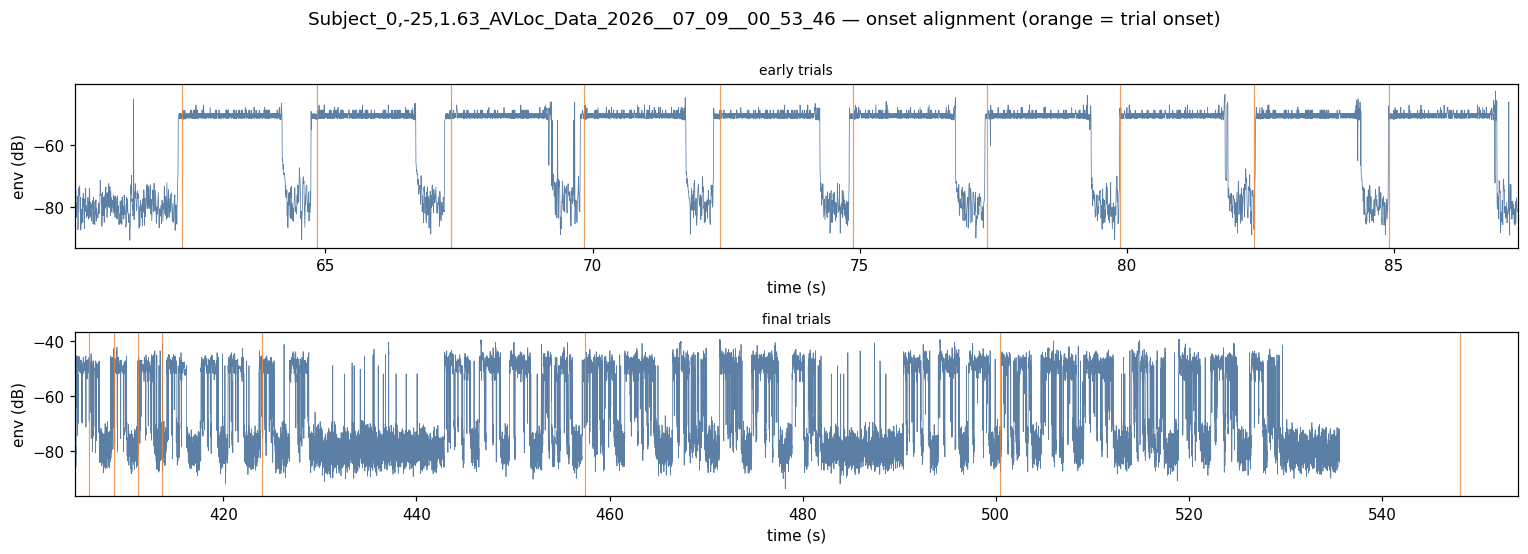

**gt_anechoic** — `Subject_0_25_1_63_A_AVLoc_Data_2026_07_14_14_52_40` onsets

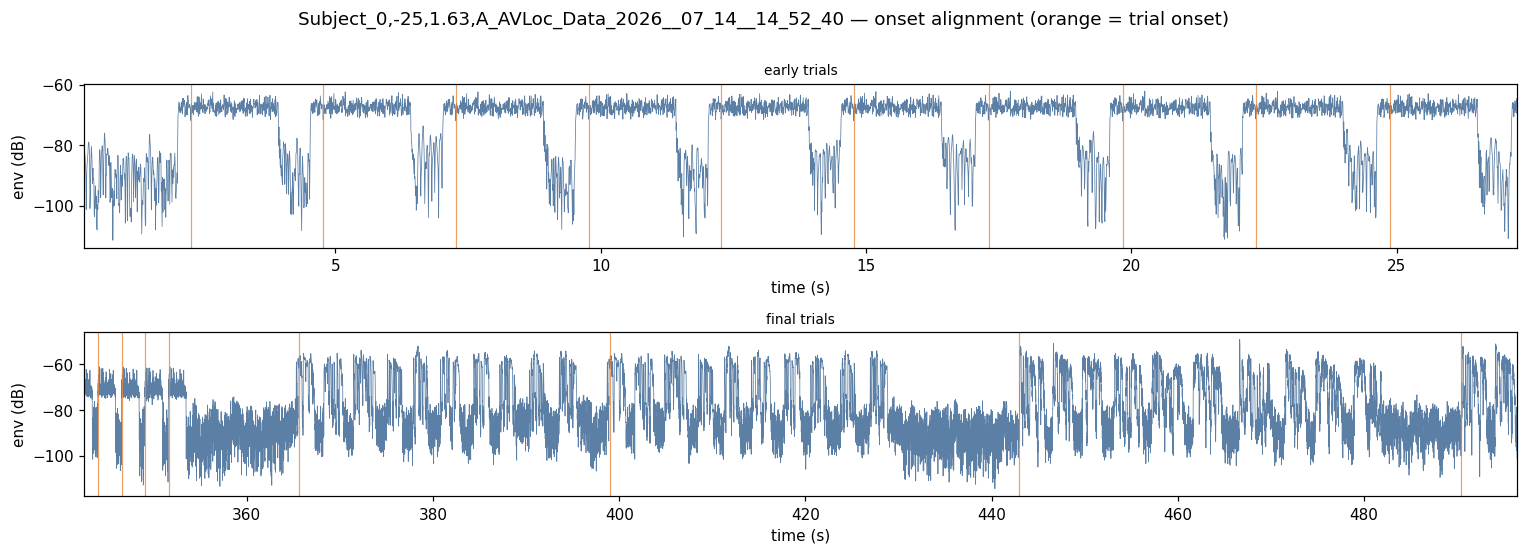

**gt_anechoic** — `Subject_0_25_1_63_A_AVLoc_Data_2026_07_14_14_52_40` spectrograms

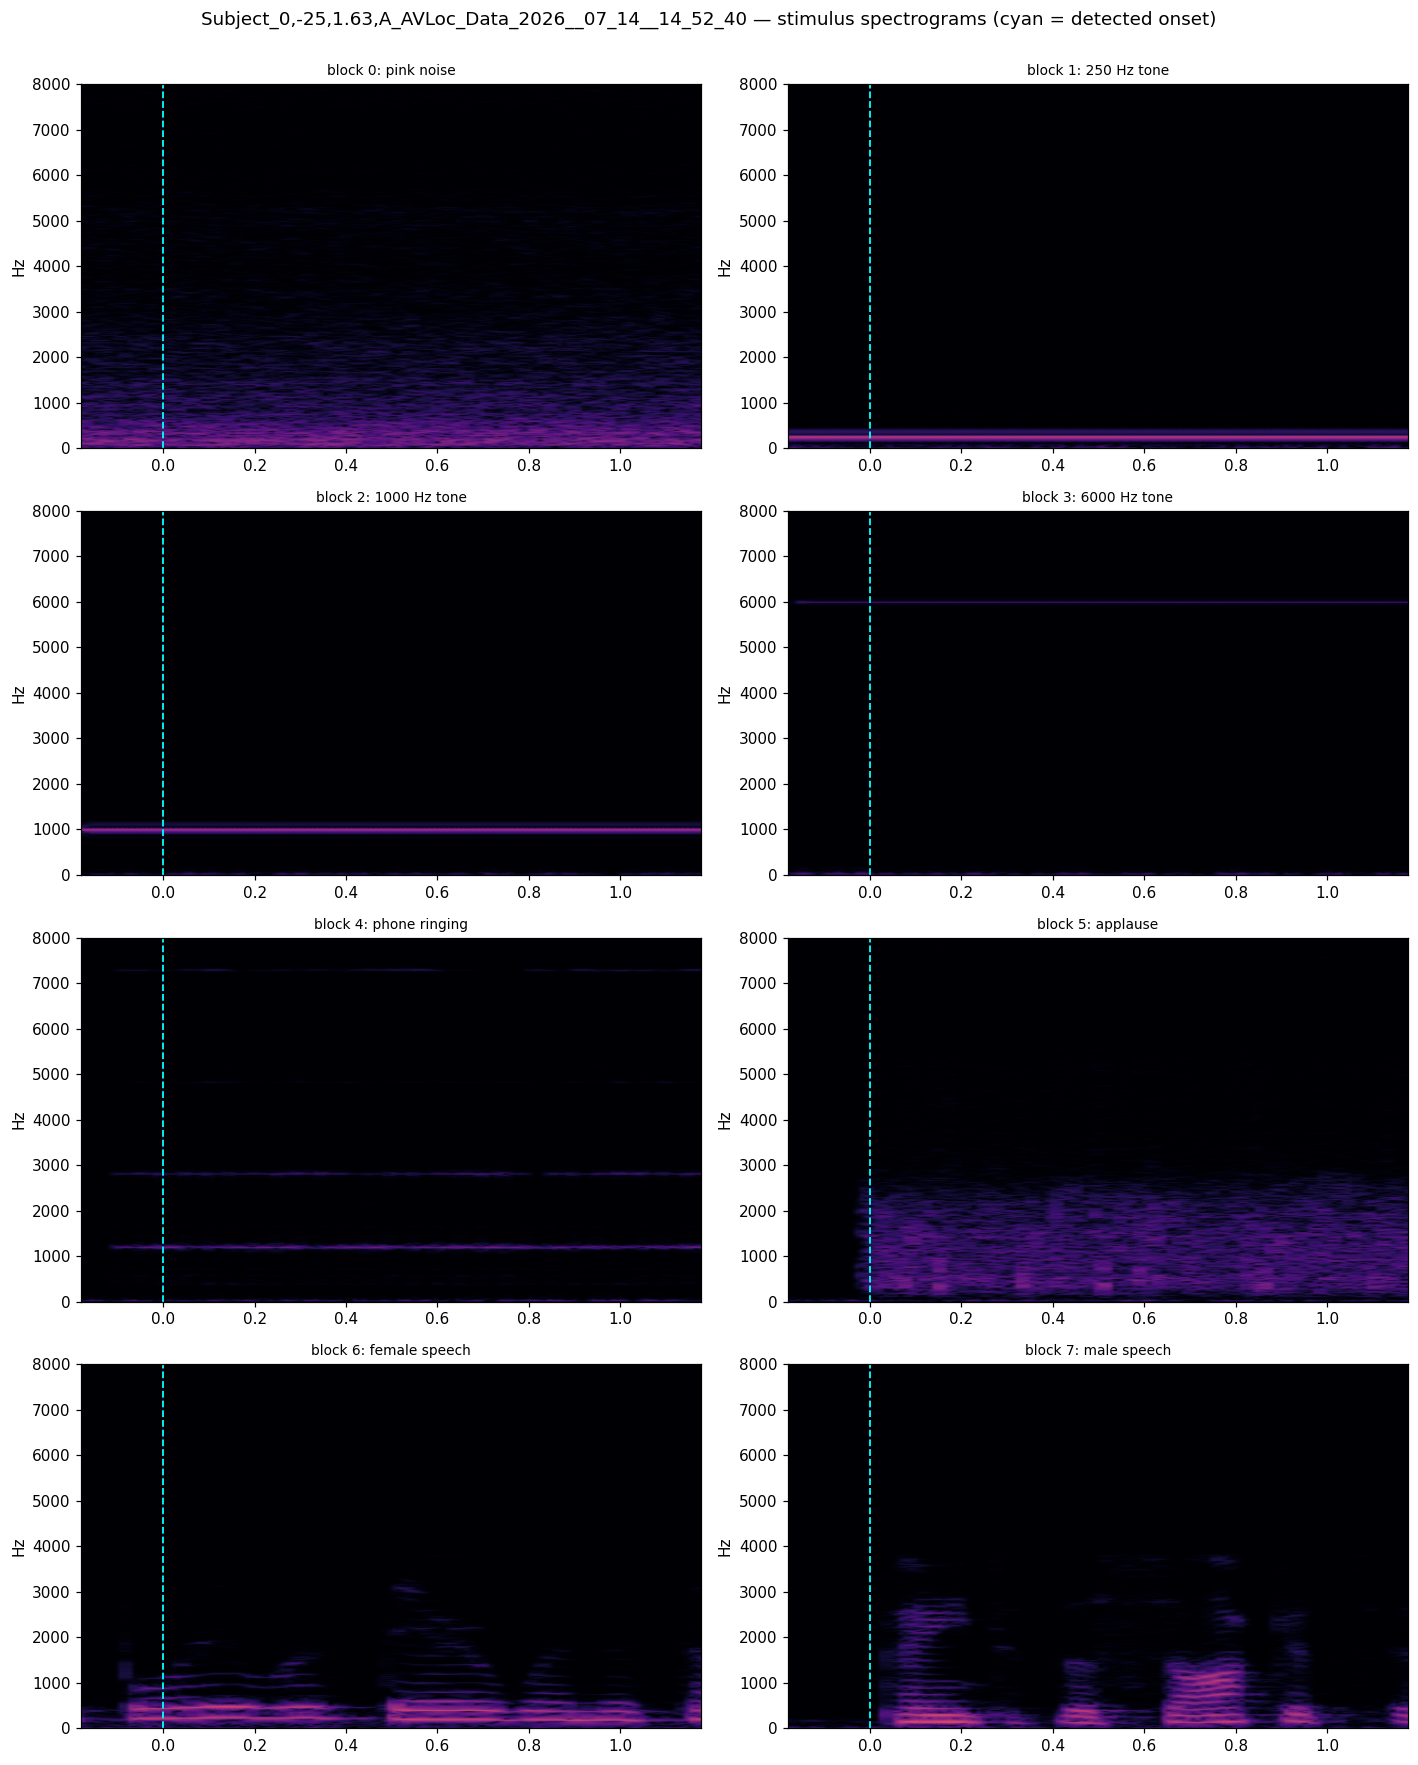

**vbap** — `Subject_0_345_25_1_63_V_AVLoc_Data_2026_07_14_08_06_21` onsets

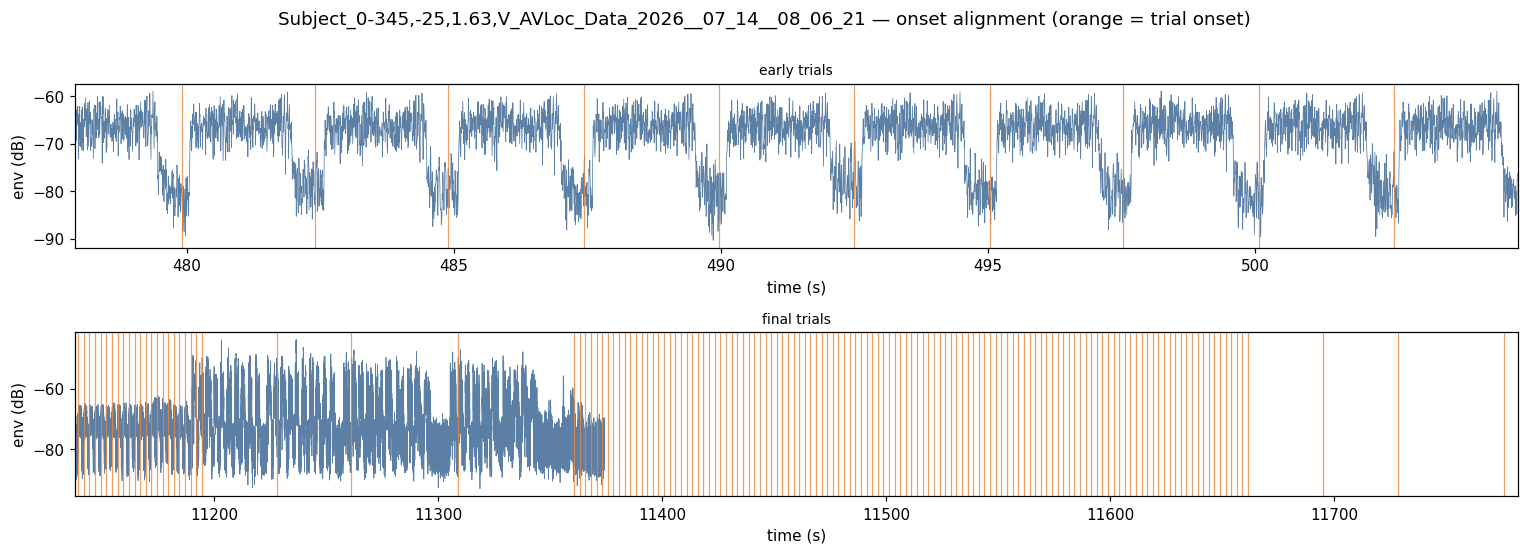

**vbap** — `Subject_0_345_25_1_63_V_AVLoc_Data_2026_07_14_08_06_21` spectrograms

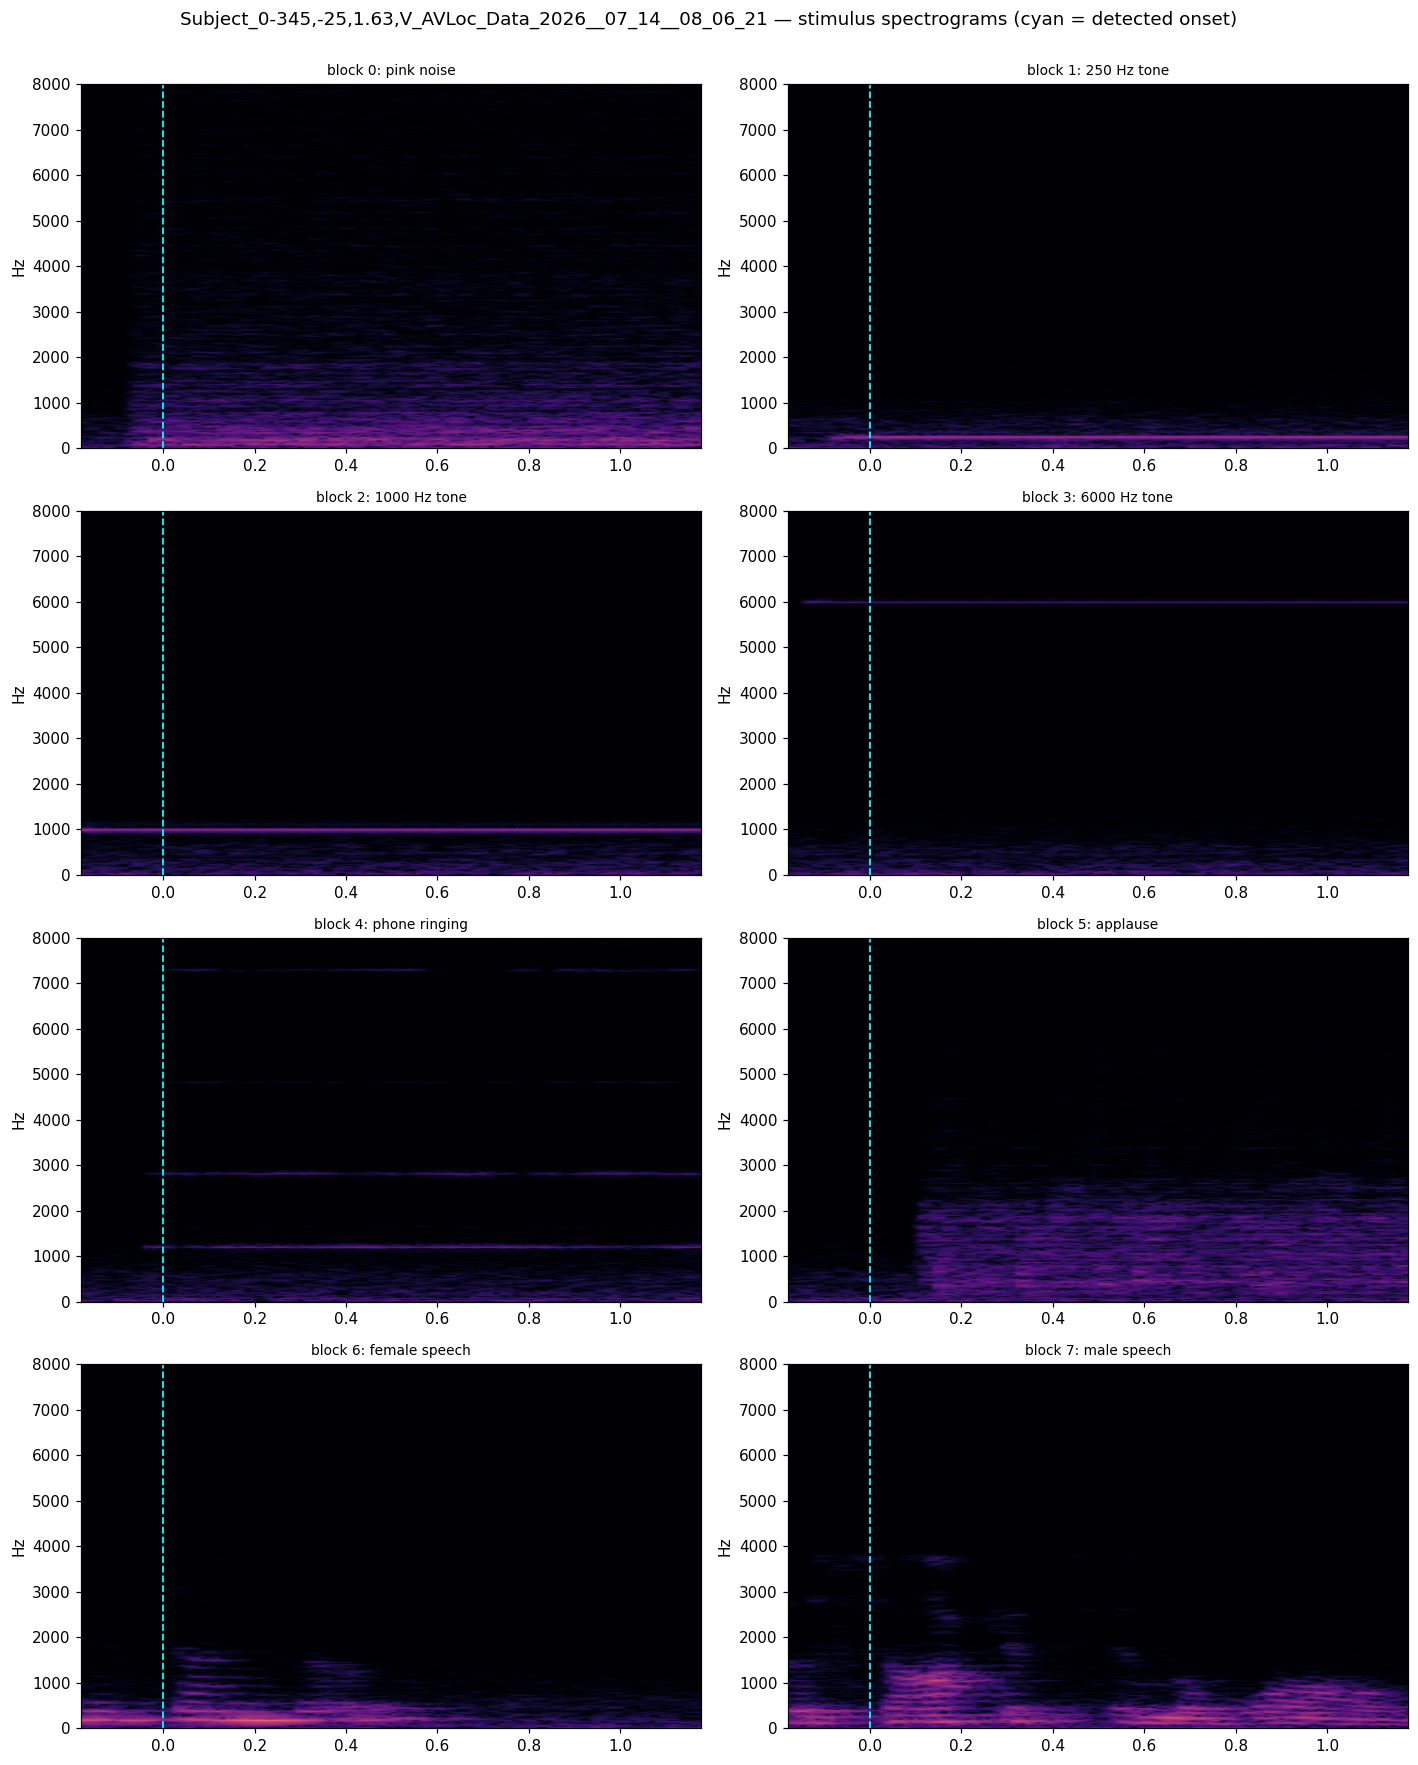

**vbap_gtmount** — `Subject_0_345_25_1_63_V_AVLoc_Data_2026_07_14_08_06_21` onsets

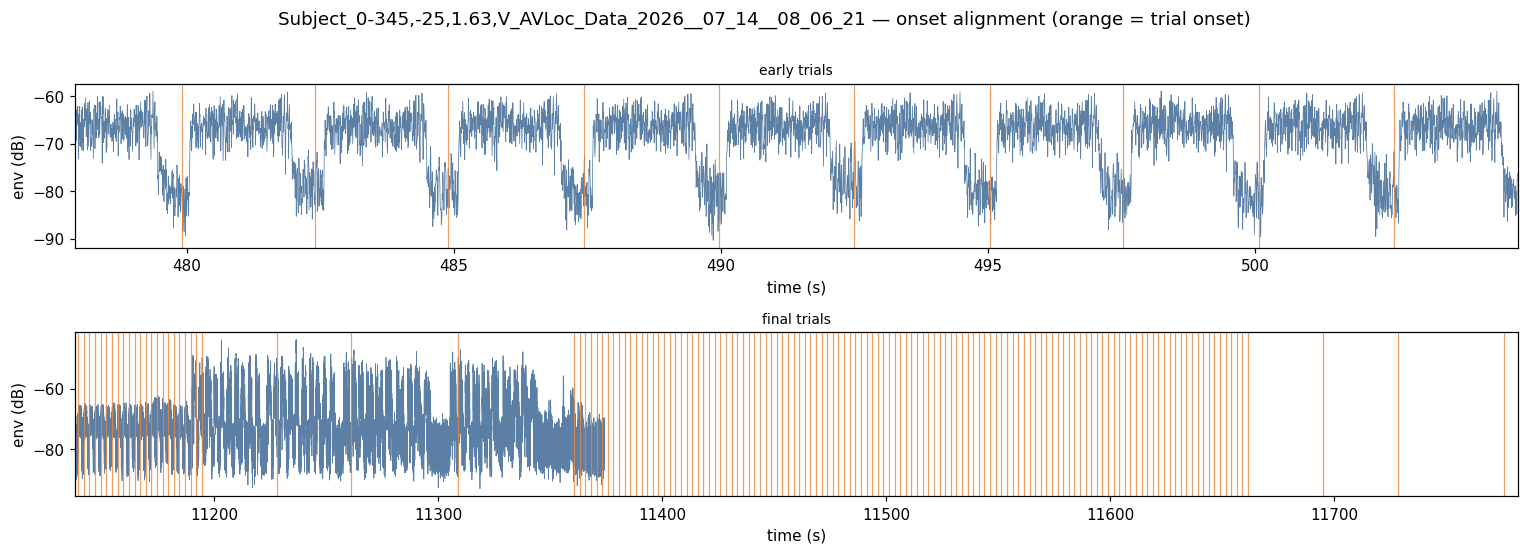

**vbap_gtmount** — `Subject_0_345_25_1_63_V_AVLoc_Data_2026_07_14_08_06_21` spectrograms

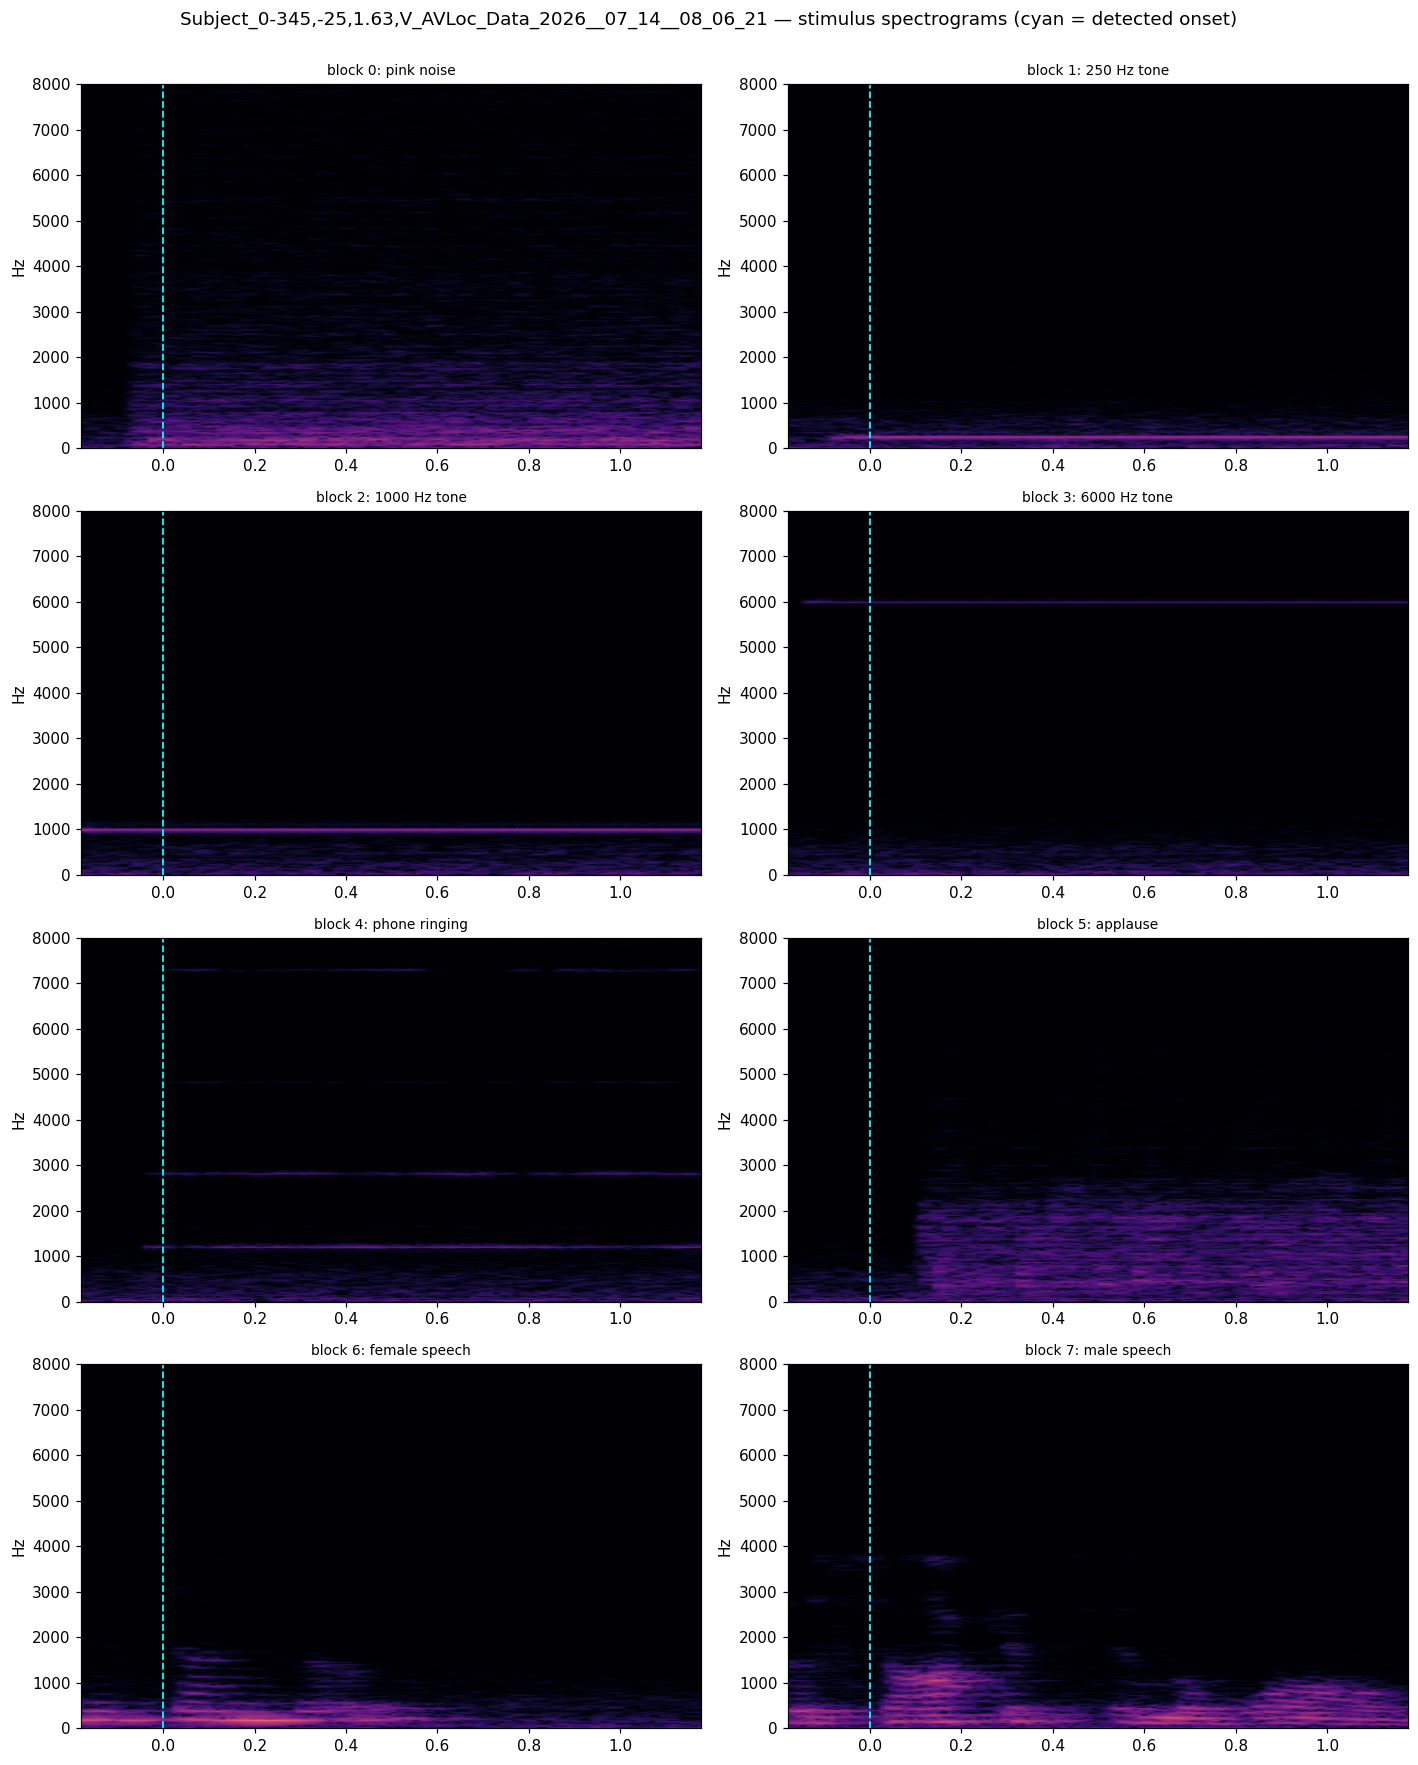

In [8]:
# One representative onset/spectrogram QC figure per condition (all sessions are in figures/<name>/)
for name, s in summaries.items():
    figdir = ra.load_condition(name)["figures_dir"]
    tag0 = s["positions"][0]["tag"]
    for suffix in ("onsets", "spectrograms"):
        p = figdir / f"{tag0}_{suffix}.png"
        if p.exists():
            display(Markdown(f"**{name}** — `{tag0}` {suffix}")); display(Image(str(p)))

## 3. Results — accuracy by stimulus and elevation

Mount-corrected angular miss (median °) over calibration-consistent trials.

**gt_cave** — noise-like (pink noise + applause)

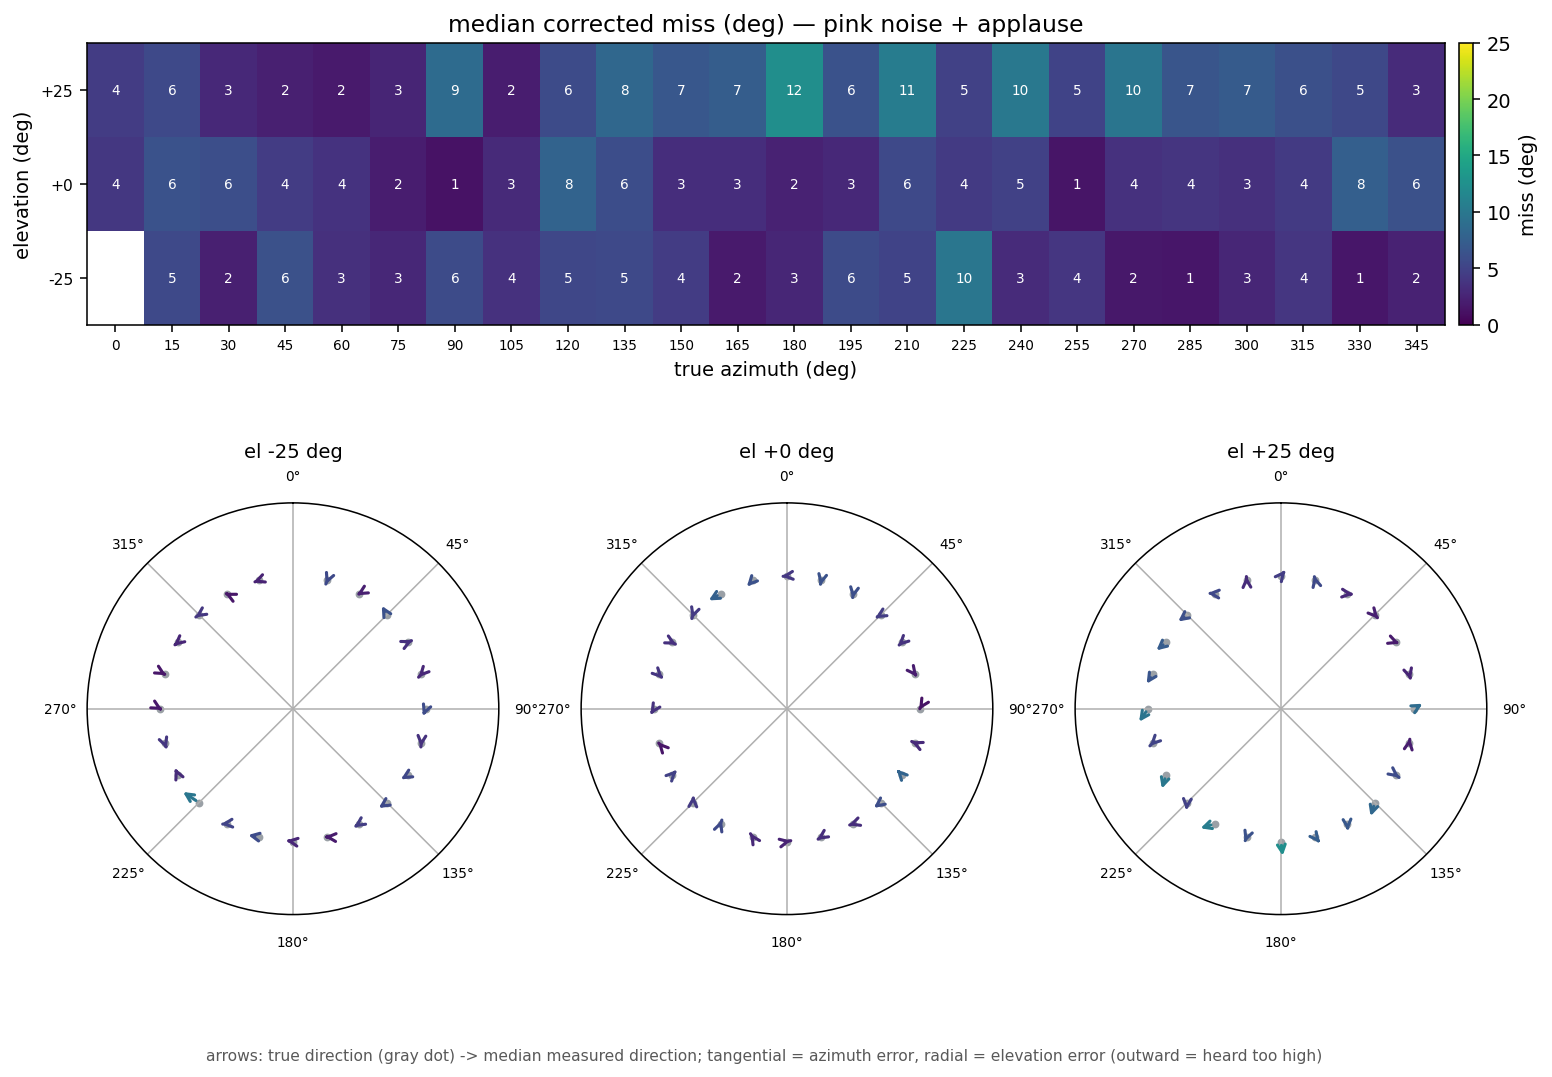

**gt_cave** — tones (250 Hz + 1000 Hz; note the wider scale)

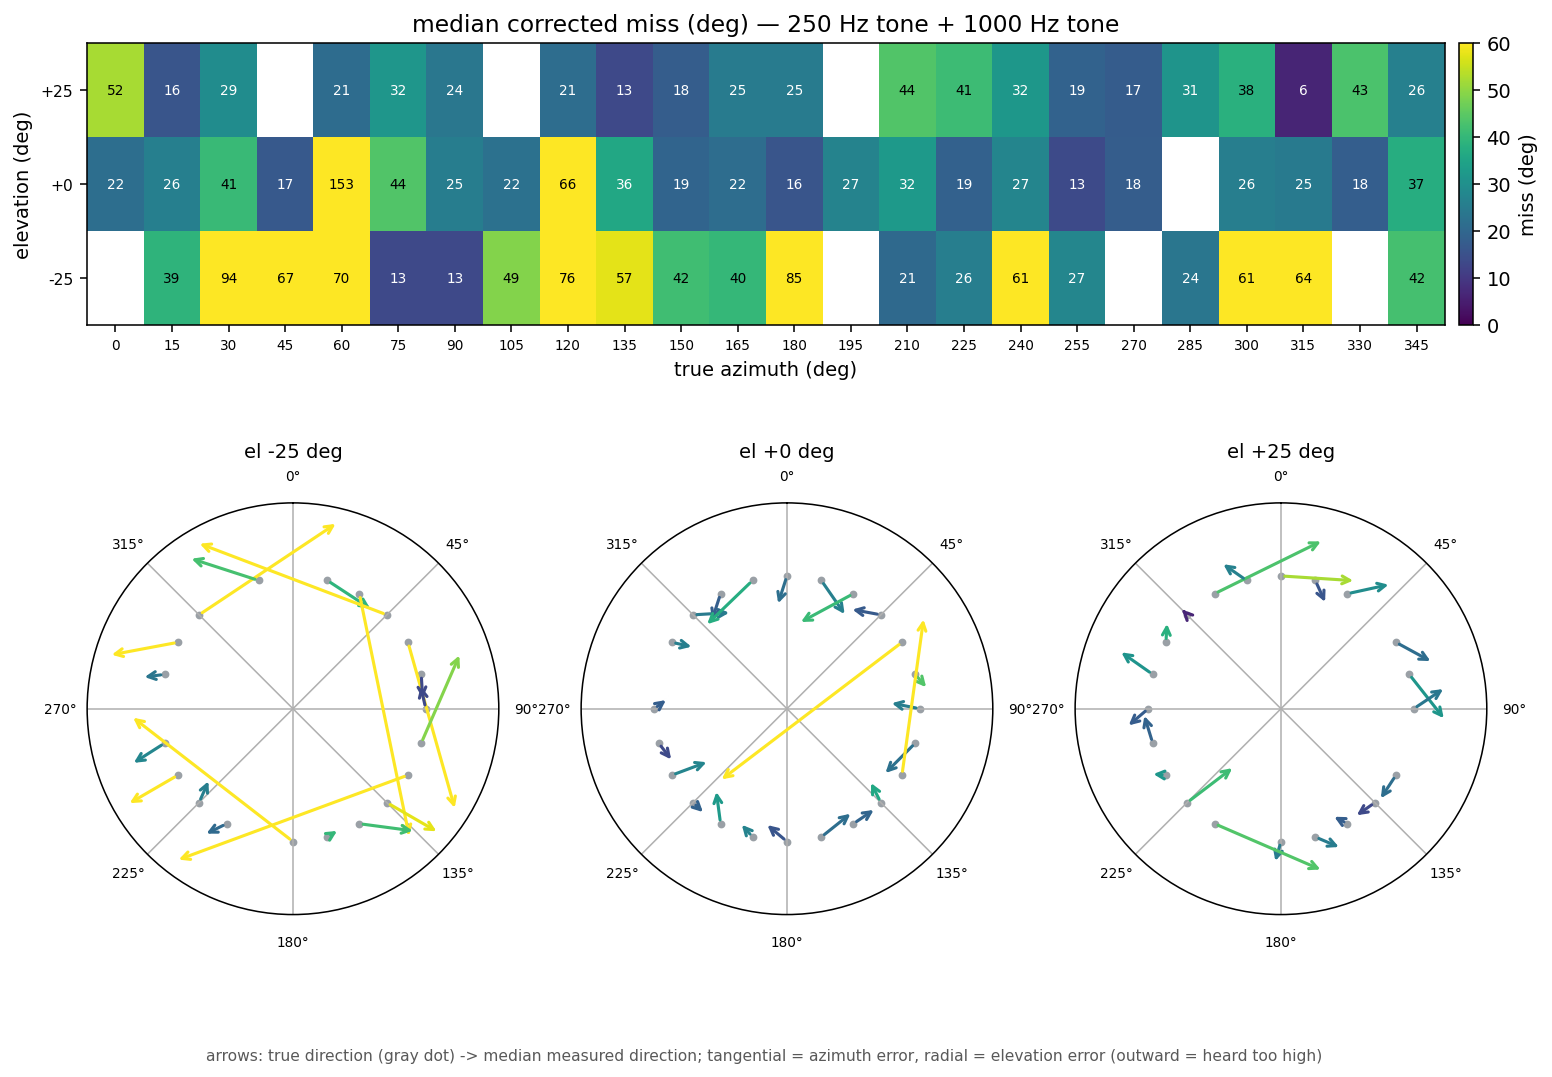

**gt_anechoic** — noise-like (pink noise + applause)

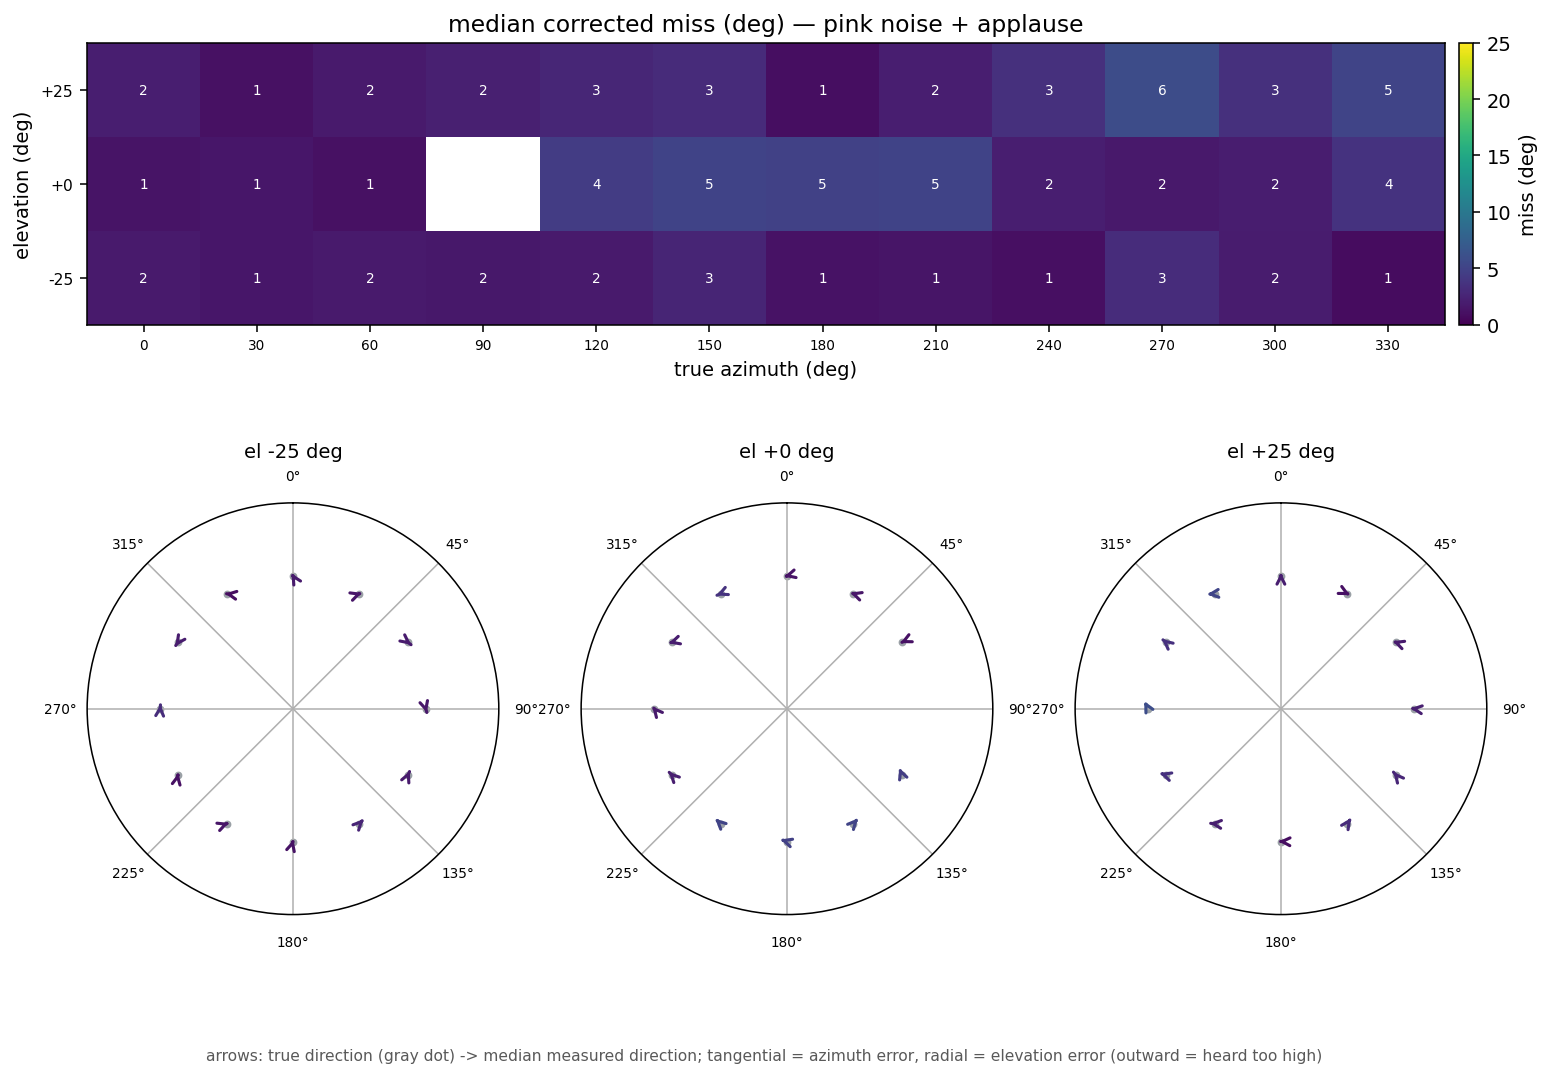

**gt_anechoic** — tones (250 Hz + 1000 Hz; note the wider scale)

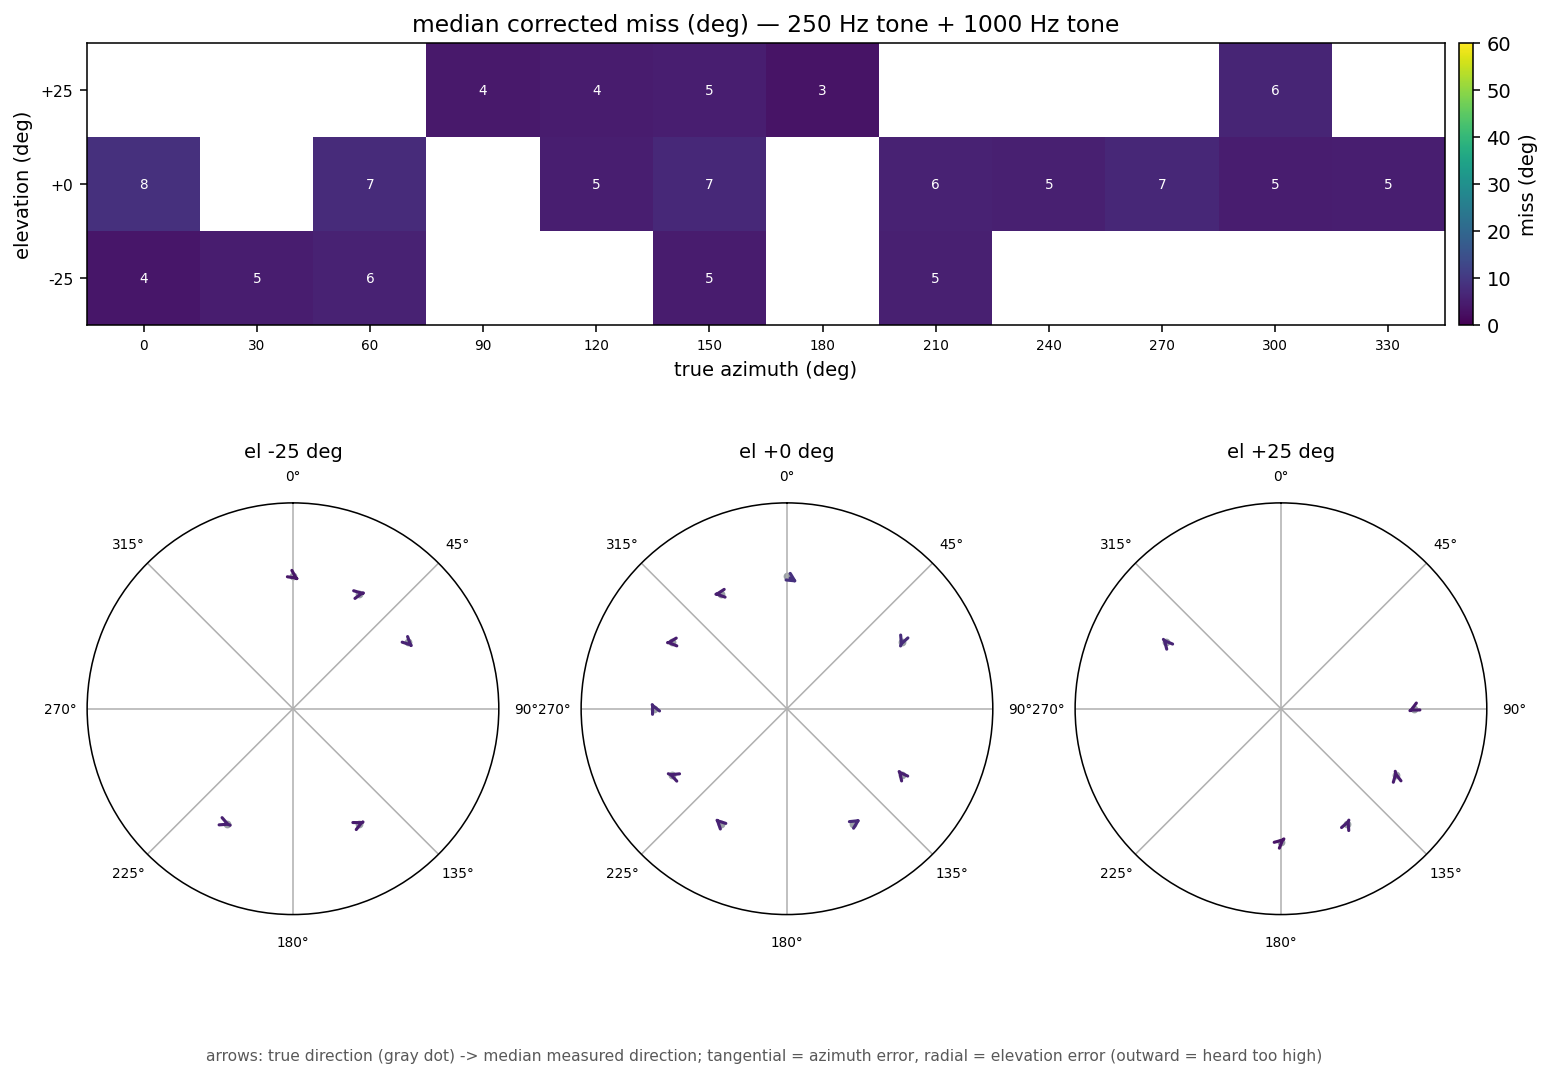

**vbap** — noise-like (pink noise + applause)

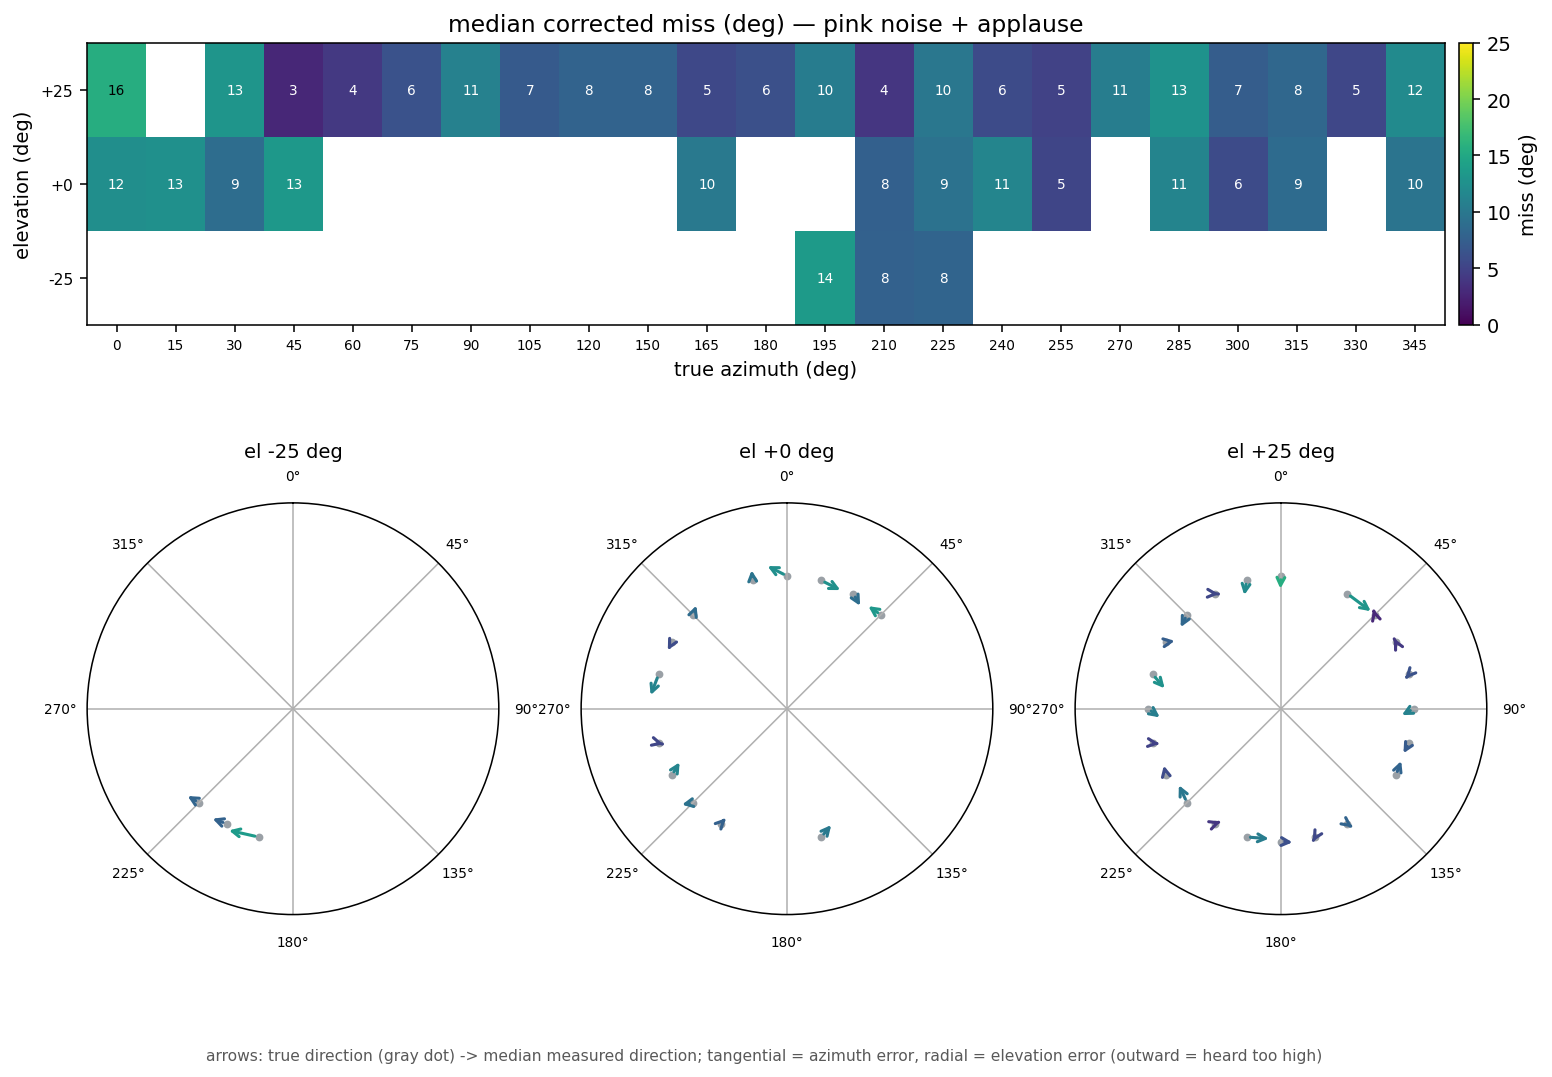

**vbap** — tones (250 Hz + 1000 Hz; note the wider scale)

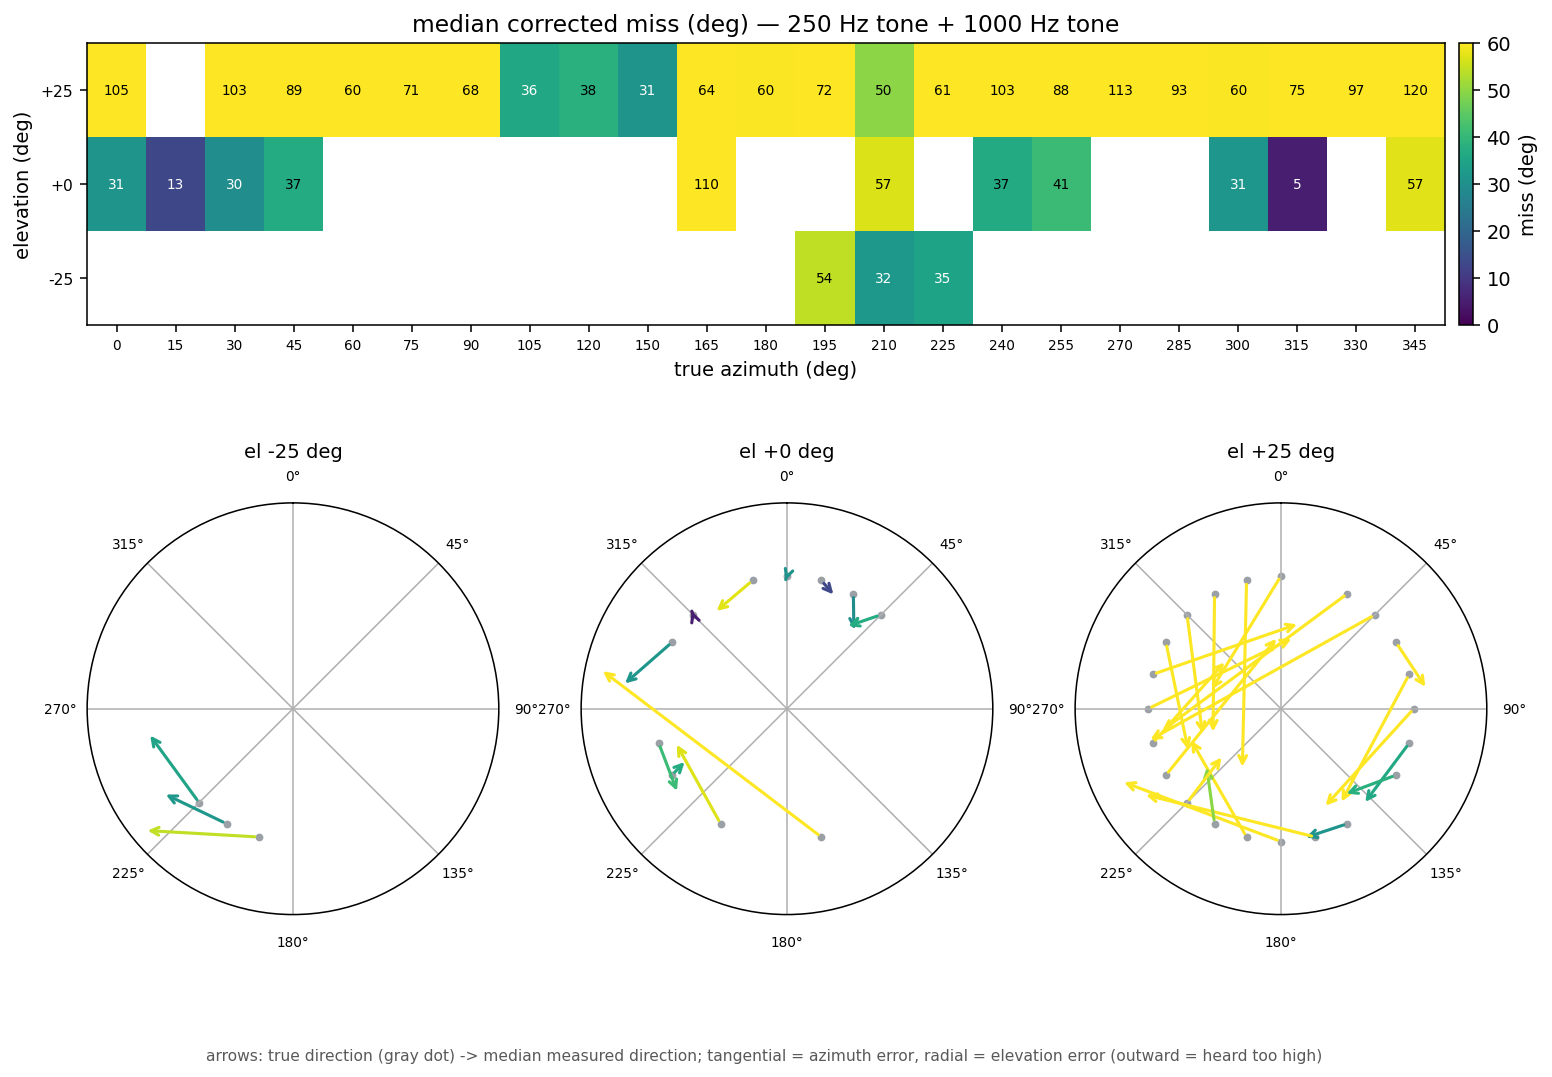

**vbap_gtmount** — noise-like (pink noise + applause)

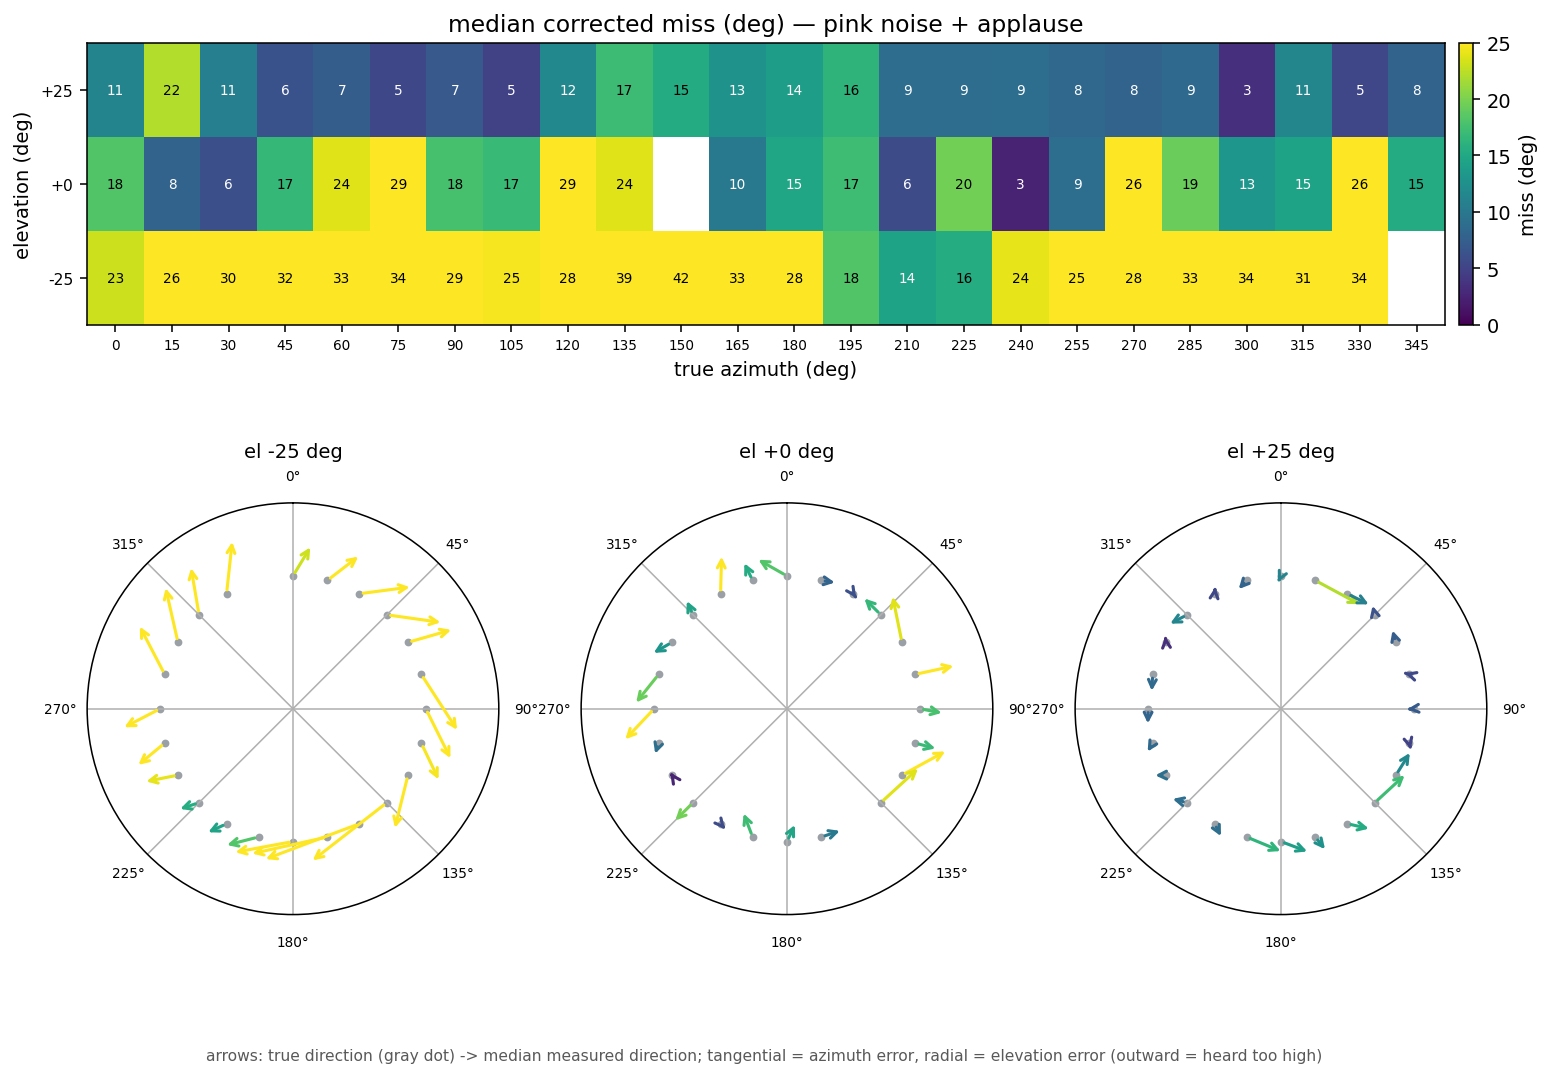

**vbap_gtmount** — tones (250 Hz + 1000 Hz; note the wider scale)

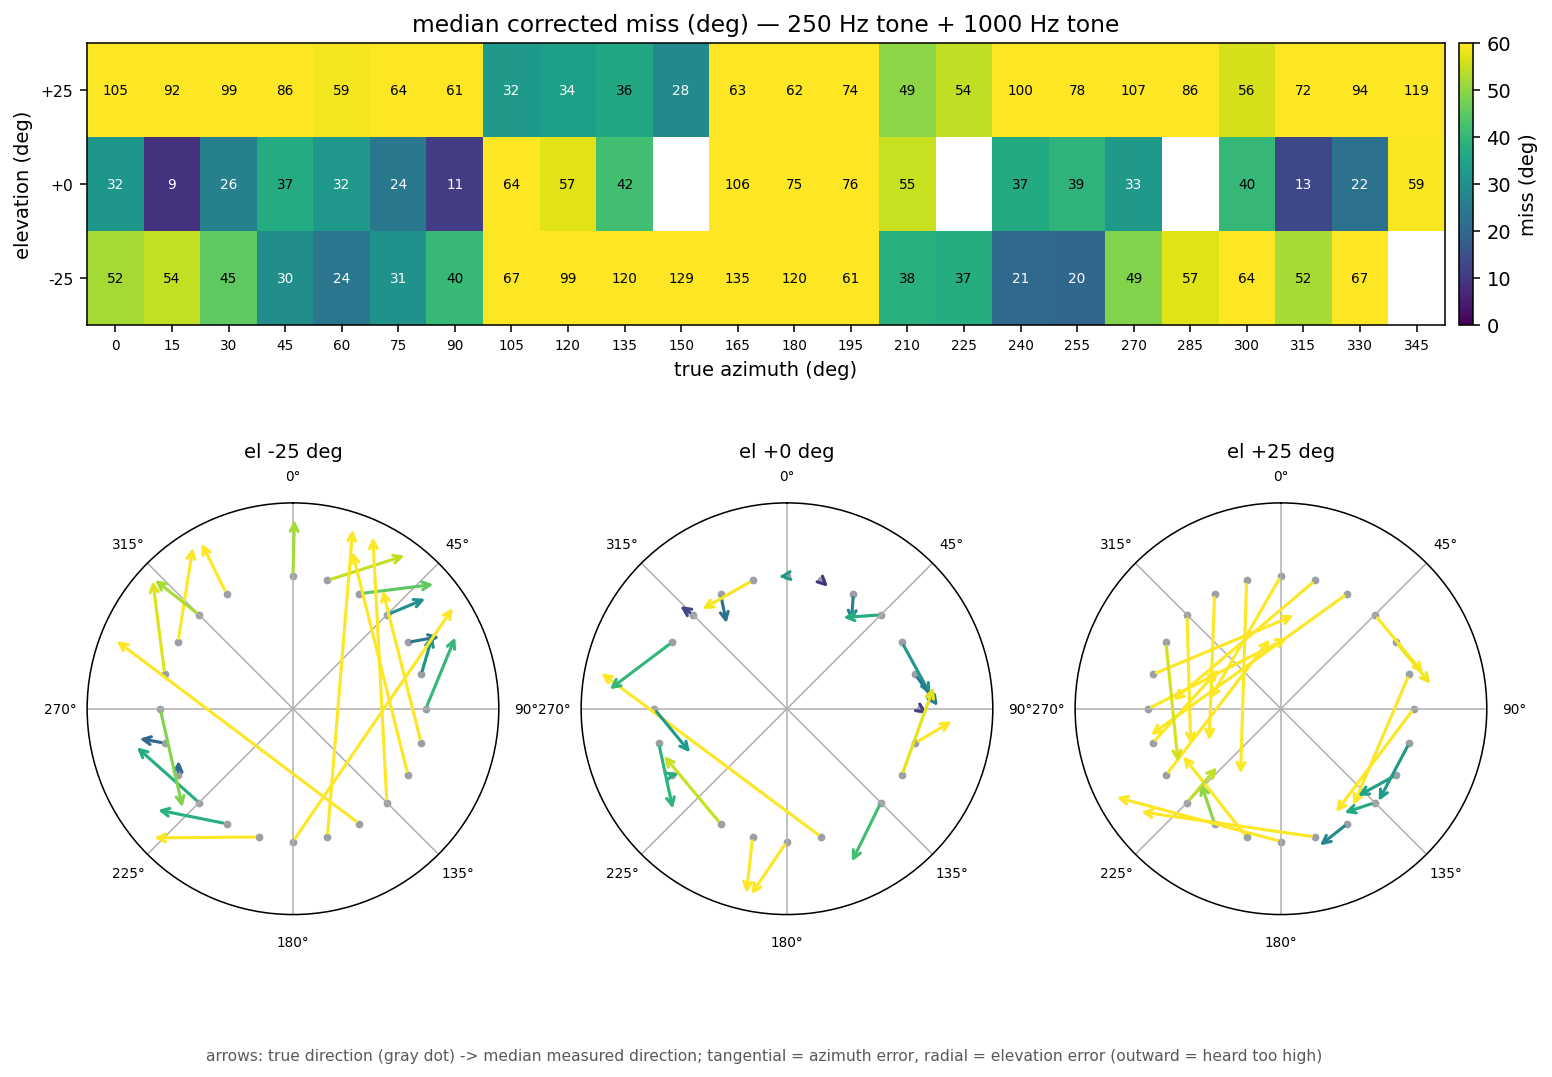

In [9]:
# Where the misses are: heatmap (az x el) + per-elevation arrow maps.
# Arrows run from each TRUE direction to the median MEASURED direction:
# tangential component = azimuth error, radial = elevation error (outward = heard too high).
# White heatmap cells = no calibration-consistent reliable trials there (outlier positions).
for name in summaries:
    for fname, sub in (("miss_map.png", "noise-like (pink noise + applause)"),
                       ("miss_map_tones.png", "tones (250 Hz + 1000 Hz; note the wider scale)")):
        p = ra.load_condition(name)["figures_dir"] / fname
        if p.exists():
            display(Markdown(f"**{name}** — {sub}")); display(Image(str(p)))

In [10]:
rows = []
for name, s in summaries.items():
    for lab, v in s["corrected_miss_by_stimulus"].items():
        rows.append(dict(condition=name, stimulus=lab, median_miss_deg=v["median"], n=v["n"]))
by_stim = pd.DataFrame(rows).pivot(index="stimulus", columns="condition", values="median_miss_deg")
display(by_stim)

rows = []
for name, s in summaries.items():
    for el, v in s.get("by_elevation", {}).items():
        rows.append(dict(condition=name, elevation_deg=float(el),
                         median_miss_deg=v["median"], n=v["n"]))
display(pd.DataFrame(rows).pivot(index="elevation_deg", columns="condition",
                                 values="median_miss_deg"))

condition,gt_anechoic,gt_cave,vbap,vbap_gtmount
stimulus,,,,
1000 Hz tone,5.36,21.88,41.02,47.05
250 Hz tone,4.39,33.01,61.12,51.80
applause,1.93,4.17,8.18,15.05
female speech,3.66,16.07,11.35,22.60
male speech,3.55,12.92,21.38,31.51
phone ringing,5.54,21.08,15.24,25.16
pink noise,2.56,5.09,8.21,17.32


condition,gt_anechoic,gt_cave,vbap,vbap_gtmount
elevation_deg,,,,
-25.13,NaN,NaN,22.90,37.31
-25.02,NaN,NaN,15.14,34.59
-25.00,2.08,7.69,29.32,32.93
0.00,4.86,7.65,13.68,21.43
25.00,3.02,10.80,20.28,21.76
25.02,NaN,NaN,14.53,19.08
25.13,NaN,NaN,14.07,23.13


In [11]:
# Precision vs accuracy: sub-degree precision with a large miss = a systematic bias, not noise.
rows = []
for name, s in summaries.items():
    prec = s["within_position_precision_by_stimulus"]
    for lab, v in s["corrected_miss_by_stimulus"].items():
        rows.append(dict(condition=name, stimulus=lab,
                         miss_deg=v["median"], precision_deg=prec.get(lab)))
display(pd.DataFrame(rows).set_index(["stimulus", "condition"]).sort_index())

miss_deg  precision_deg
stimulus      condition                            
1000 Hz tone  gt_anechoic       5.36           0.01
              gt_cave          21.88           0.27
              vbap             41.02           0.31
              vbap_gtmount     47.05           0.37
250 Hz tone   gt_anechoic       4.39           0.01
              gt_cave          33.01           0.26
              vbap             61.12           0.32
              vbap_gtmount     51.80           0.34
applause      gt_anechoic       1.93           0.04
              gt_cave           4.17           0.54
              vbap              8.18           1.25
              vbap_gtmount     15.05           1.41
female speech gt_anechoic       3.66           0.01
              gt_cave          16.07           0.15
              vbap             11.35           2.09
              vbap_gtmount     22.60           2.06
male speech   gt_anechoic       3.55           0.03
              gt_cave          12.92           0.74
              vbap             21.38           0.76
              vbap_gtmount     31.51           0.94
phone ringing gt_anechoic       5.54           0.01
              gt_cave          21.08           0.40
              vbap             15.24           0.52
              vbap_gtmount     25.16           0.45
pink noise    gt_anechoic       2.56           0.03
              gt_cave           5.09           0.73
              vbap              8.21           1.46
              vbap_gtmount     17.32           1.77

## 4. Cross-condition comparisons

Matched (azimuth, elevation) cells only; per-stimulus deltas carry bootstrap 95% CIs.
`room_effect` = anechoic vs CAVE ground truth (12 shared azimuths × 3 elevations);
`vbap_vs_gt` = rendering penalty vs the physical-speaker floor, with the optimizer's
energy-vector (r_E) prediction overlaid.

  [skip] comparison 'atmos_vs_gt': condition 'atmos' has no results yet
  [skip] comparison 'renders_head_to_head': condition 'atmos' has no results yet


### room_effect

,gt_cave,gt_anechoic,delta,per_cell_delta_median,n_matched_cells
pink noise,"{'n': 599, 'median': 5.13, 'p90': 10.05, 'ci95...","{'n': 310, 'median': 2.56, 'p90': 4.89, 'ci95'...","{'delta': 2.57, 'ci95': [2.4, 3.1], 'significa...",2.97,16
applause,"{'n': 651, 'median': 4.05, 'p90': 9.62, 'ci95'...","{'n': 623, 'median': 1.95, 'p90': 5.01, 'ci95'...","{'delta': 2.1, 'ci95': [1.9, 2.4], 'significan...",2.14,30
phone ringing,"{'n': 140, 'median': 21.06, 'p90': 46.1, 'ci95...","{'n': 27, 'median': 5.54, 'p90': 5.57, 'ci95':...","{'delta': 15.52, 'ci95': [15.2, 15.7], 'signif...",38.03,1
250 Hz tone,"{'n': 605, 'median': 29.17, 'p90': 111.85, 'ci...","{'n': 329, 'median': 4.39, 'p90': 6.91, 'ci95'...","{'delta': 24.78, 'ci95': [23.9, 27.2], 'signif...",24.73,15
1000 Hz tone,"{'n': 616, 'median': 25.77, 'p90': 62.87, 'ci9...","{'n': 360, 'median': 5.54, 'p90': 9.83, 'ci95'...","{'delta': 20.23, 'ci95': [19.2, 20.8], 'signif...",17.67,18
male speech,"{'n': 53, 'median': 13.39, 'p90': 26.95, 'ci95...","{'n': 48, 'median': 3.58, 'p90': 5.55, 'ci95':...","{'delta': 9.81, 'ci95': [6.7, 12.0], 'signific...",7.81,19
female speech,"{'n': 52, 'median': 16.99, 'p90': 32.42, 'ci95...","{'n': 54, 'median': 3.67, 'p90': 5.65, 'ci95':...","{'delta': 13.32, 'ci95': [9.1, 15.2], 'signifi...",12.49,25


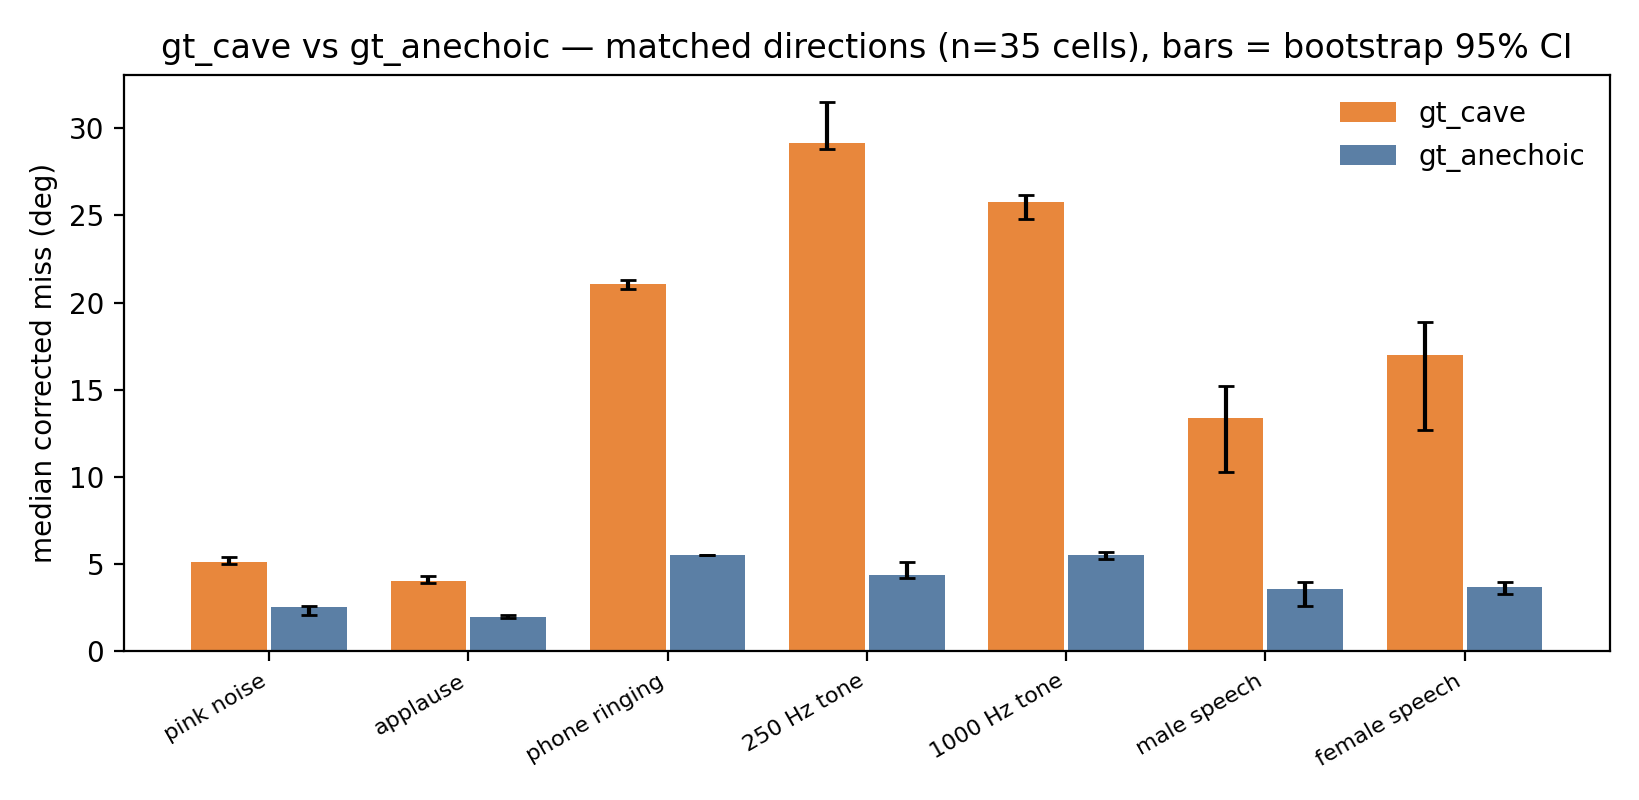

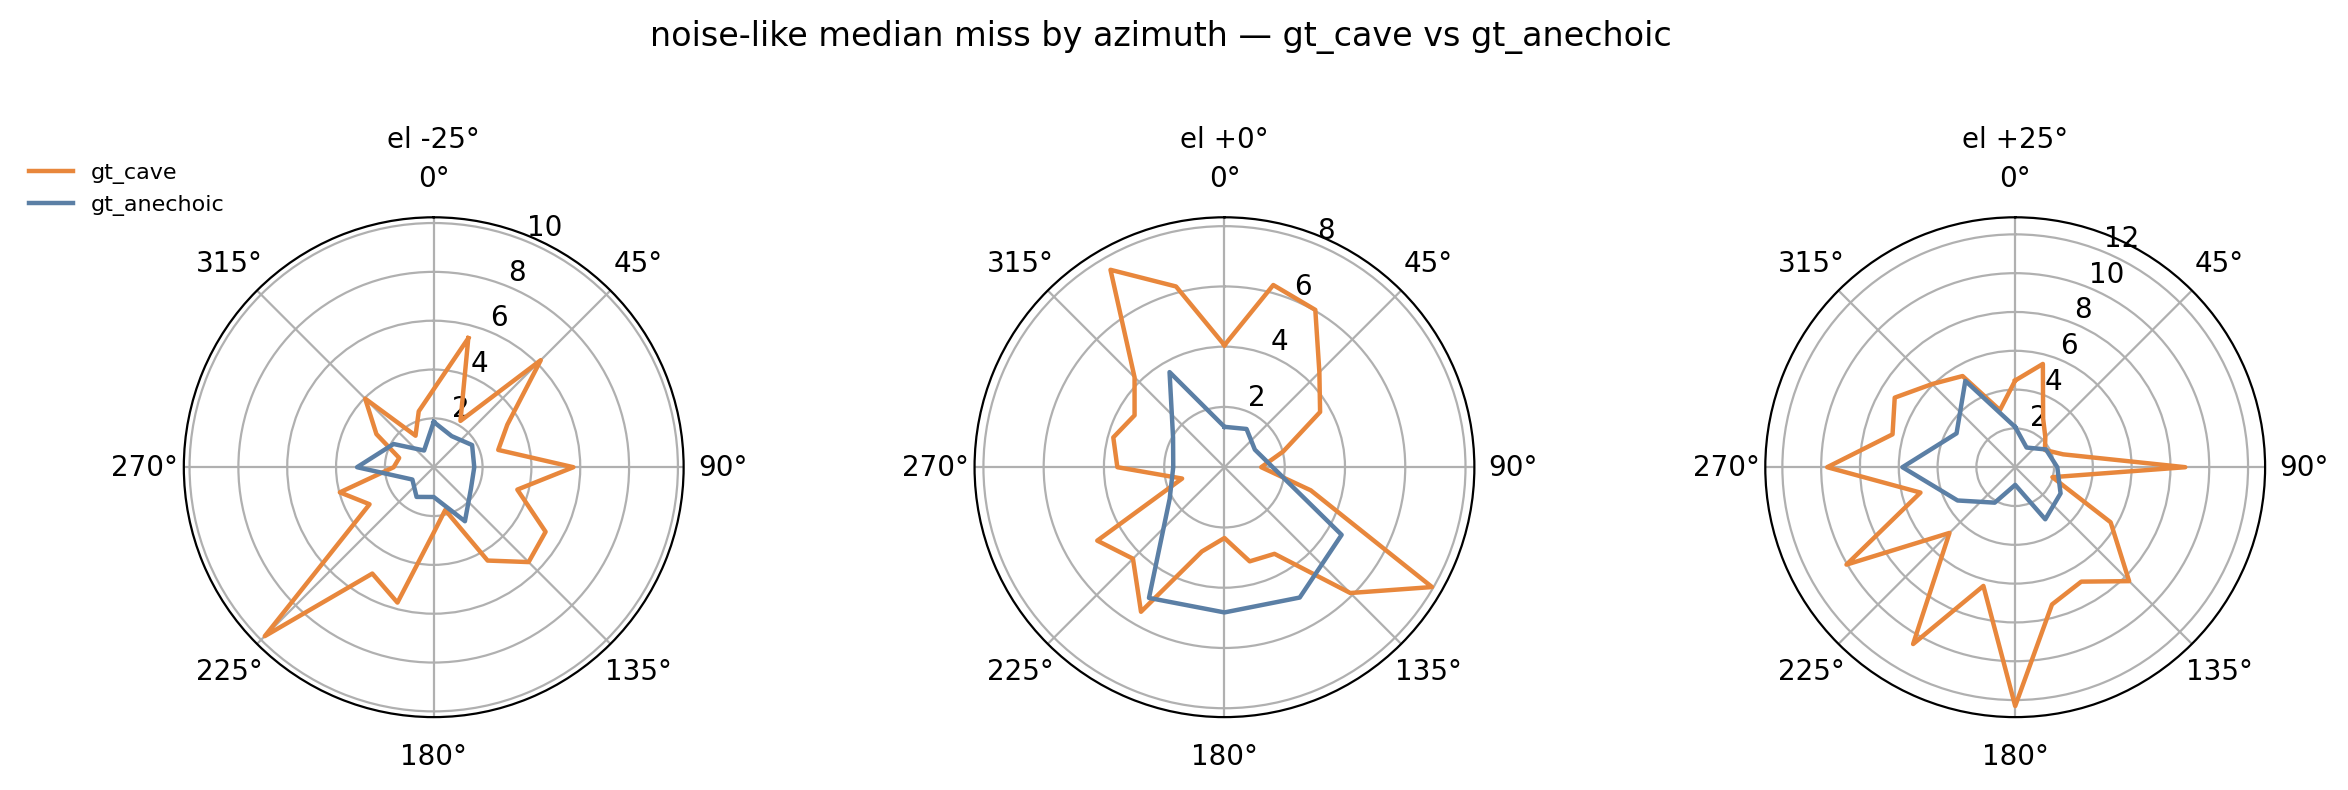

### vbap_vs_gt

,vbap,gt_cave,delta,per_cell_delta_median,n_matched_cells
pink noise,"{'n': 736, 'median': 8.21, 'p90': 13.04, 'ci95...","{'n': 642, 'median': 5.92, 'p90': 9.91, 'ci95'...","{'delta': 2.29, 'ci95': [2.0, 2.6], 'significa...",2.0,33
applause,"{'n': 644, 'median': 8.18, 'p90': 14.76, 'ci95...","{'n': 753, 'median': 4.99, 'p90': 9.86, 'ci95'...","{'delta': 3.19, 'ci95': [2.4, 3.8], 'significa...",3.38,34
phone ringing,"{'n': 87, 'median': 15.24, 'p90': 26.22, 'ci95...","{'n': 109, 'median': 20.68, 'p90': 44.91, 'ci9...","{'delta': -5.44, 'ci95': [-6.0, 3.9], 'signifi...",5.8,3
250 Hz tone,"{'n': 712, 'median': 61.12, 'p90': 123.51, 'ci...","{'n': 643, 'median': 29.24, 'p90': 45.75, 'ci9...","{'delta': 31.89, 'ci95': [25.9, 39.7], 'signif...",29.73,32
1000 Hz tone,"{'n': 664, 'median': 41.02, 'p90': 110.75, 'ci...","{'n': 596, 'median': 21.91, 'p90': 53.23, 'ci9...","{'delta': 19.11, 'ci95': [11.9, 20.4], 'signif...",11.48,29
male speech,"{'n': 66, 'median': 21.38, 'p90': 73.91, 'ci95...","{'n': 60, 'median': 13.79, 'p90': 29.76, 'ci95...","{'delta': 7.59, 'ci95': [3.4, 11.9], 'signific...",8.74,27
female speech,"{'n': 64, 'median': 11.35, 'p90': 29.03, 'ci95...","{'n': 56, 'median': 16.76, 'p90': 27.44, 'ci95...","{'delta': -5.41, 'ci95': [-8.1, -1.5], 'signif...",-10.0,25


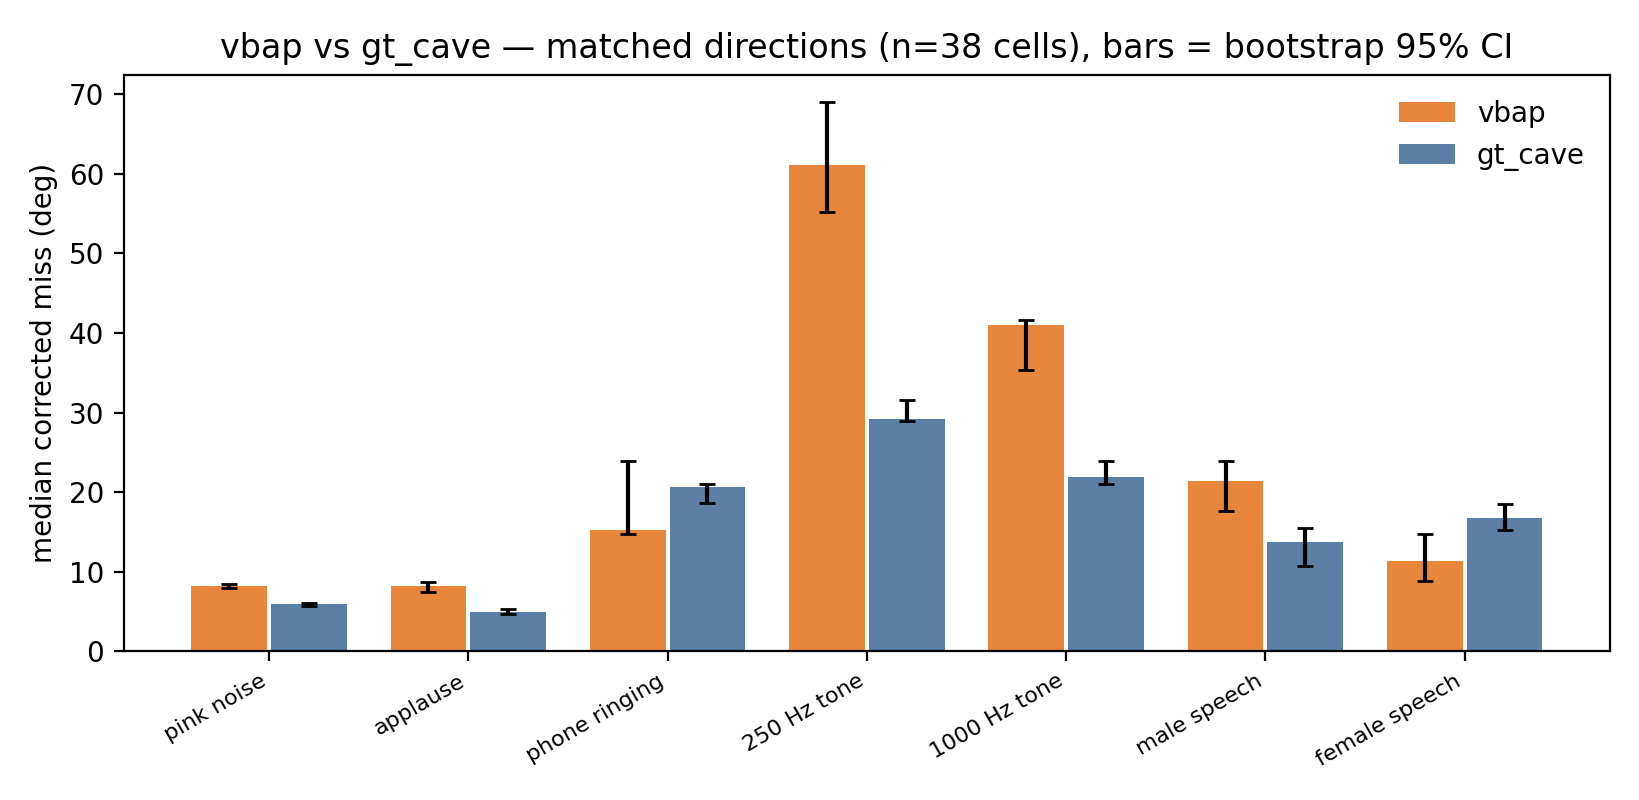

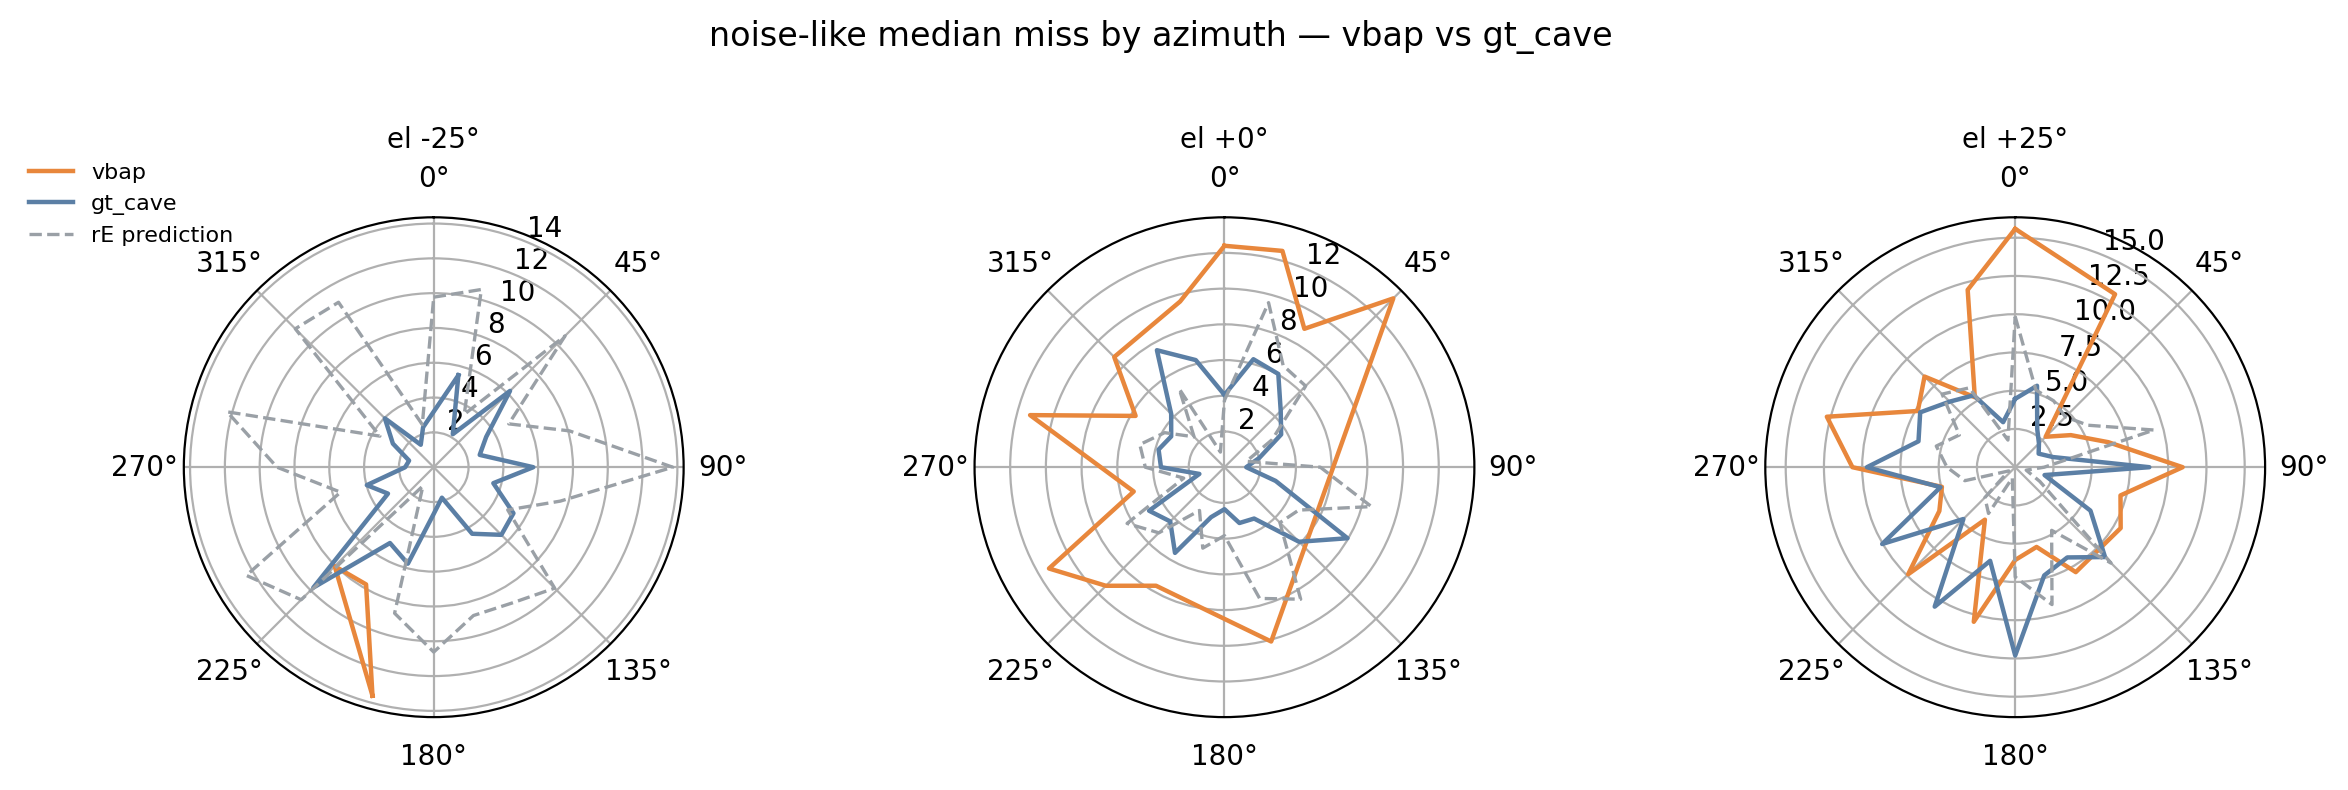

### vbap_gtmount_vs_gt

,vbap_gtmount,gt_cave,delta,per_cell_delta_median,n_matched_cells
pink noise,"{'n': 1342, 'median': 16.95, 'p90': 34.73, 'ci...","{'n': 1163, 'median': 5.13, 'p90': 8.33, 'ci95...","{'delta': 11.82, 'ci95': [11.1, 13.1], 'signif...",10.04,59
applause,"{'n': 1181, 'median': 14.88, 'p90': 31.33, 'ci...","{'n': 1309, 'median': 4.22, 'p90': 8.27, 'ci95...","{'delta': 10.66, 'ci95': [9.3, 11.5], 'signifi...",9.97,59
phone ringing,"{'n': 107, 'median': 25.36, 'p90': 34.04, 'ci9...","{'n': 181, 'median': 21.08, 'p90': 45.76, 'ci9...","{'delta': 4.28, 'ci95': [-0.1, 11.5], 'signifi...",12.19,4
250 Hz tone,"{'n': 1263, 'median': 52.07, 'p90': 117.6, 'ci...","{'n': 1183, 'median': 32.92, 'p90': 108.02, 'c...","{'delta': 19.15, 'ci95': [16.7, 20.9], 'signif...",13.85,58
1000 Hz tone,"{'n': 1197, 'median': 46.32, 'p90': 102.74, 'c...","{'n': 1175, 'median': 21.47, 'p90': 61.46, 'ci...","{'delta': 24.85, 'ci95': [21.7, 29.9], 'signif...",17.96,56
male speech,"{'n': 114, 'median': 30.29, 'p90': 76.42, 'ci9...","{'n': 107, 'median': 12.29, 'p90': 27.5, 'ci95...","{'delta': 18.0, 'ci95': [13.4, 26.7], 'signifi...",15.2,45
female speech,"{'n': 98, 'median': 22.59, 'p90': 58.02, 'ci95...","{'n': 107, 'median': 16.44, 'p90': 28.43, 'ci9...","{'delta': 6.15, 'ci95': [2.0, 10.7], 'signific...",0.13,40


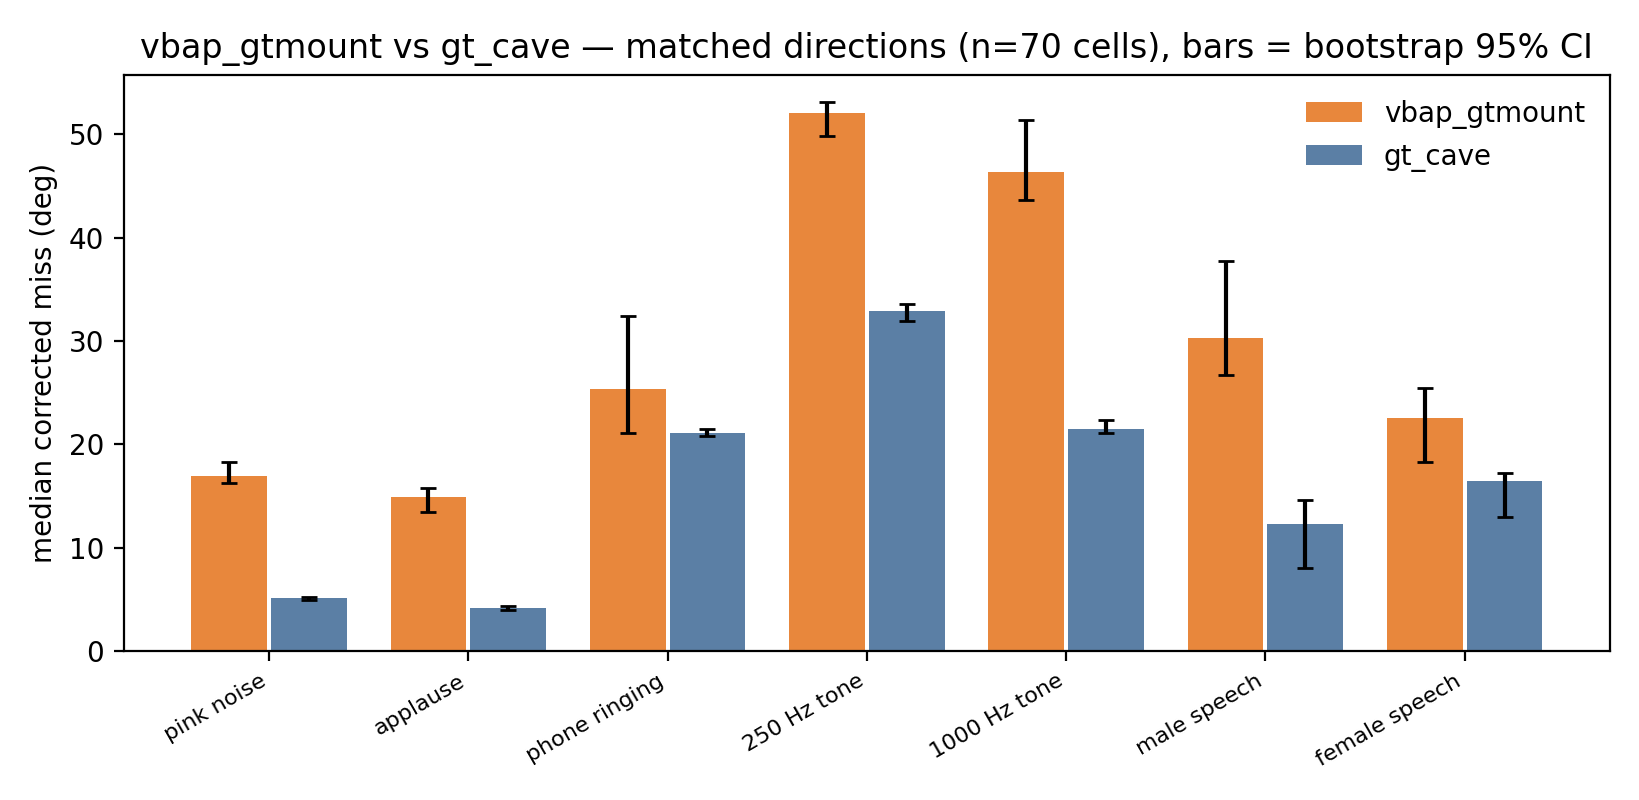

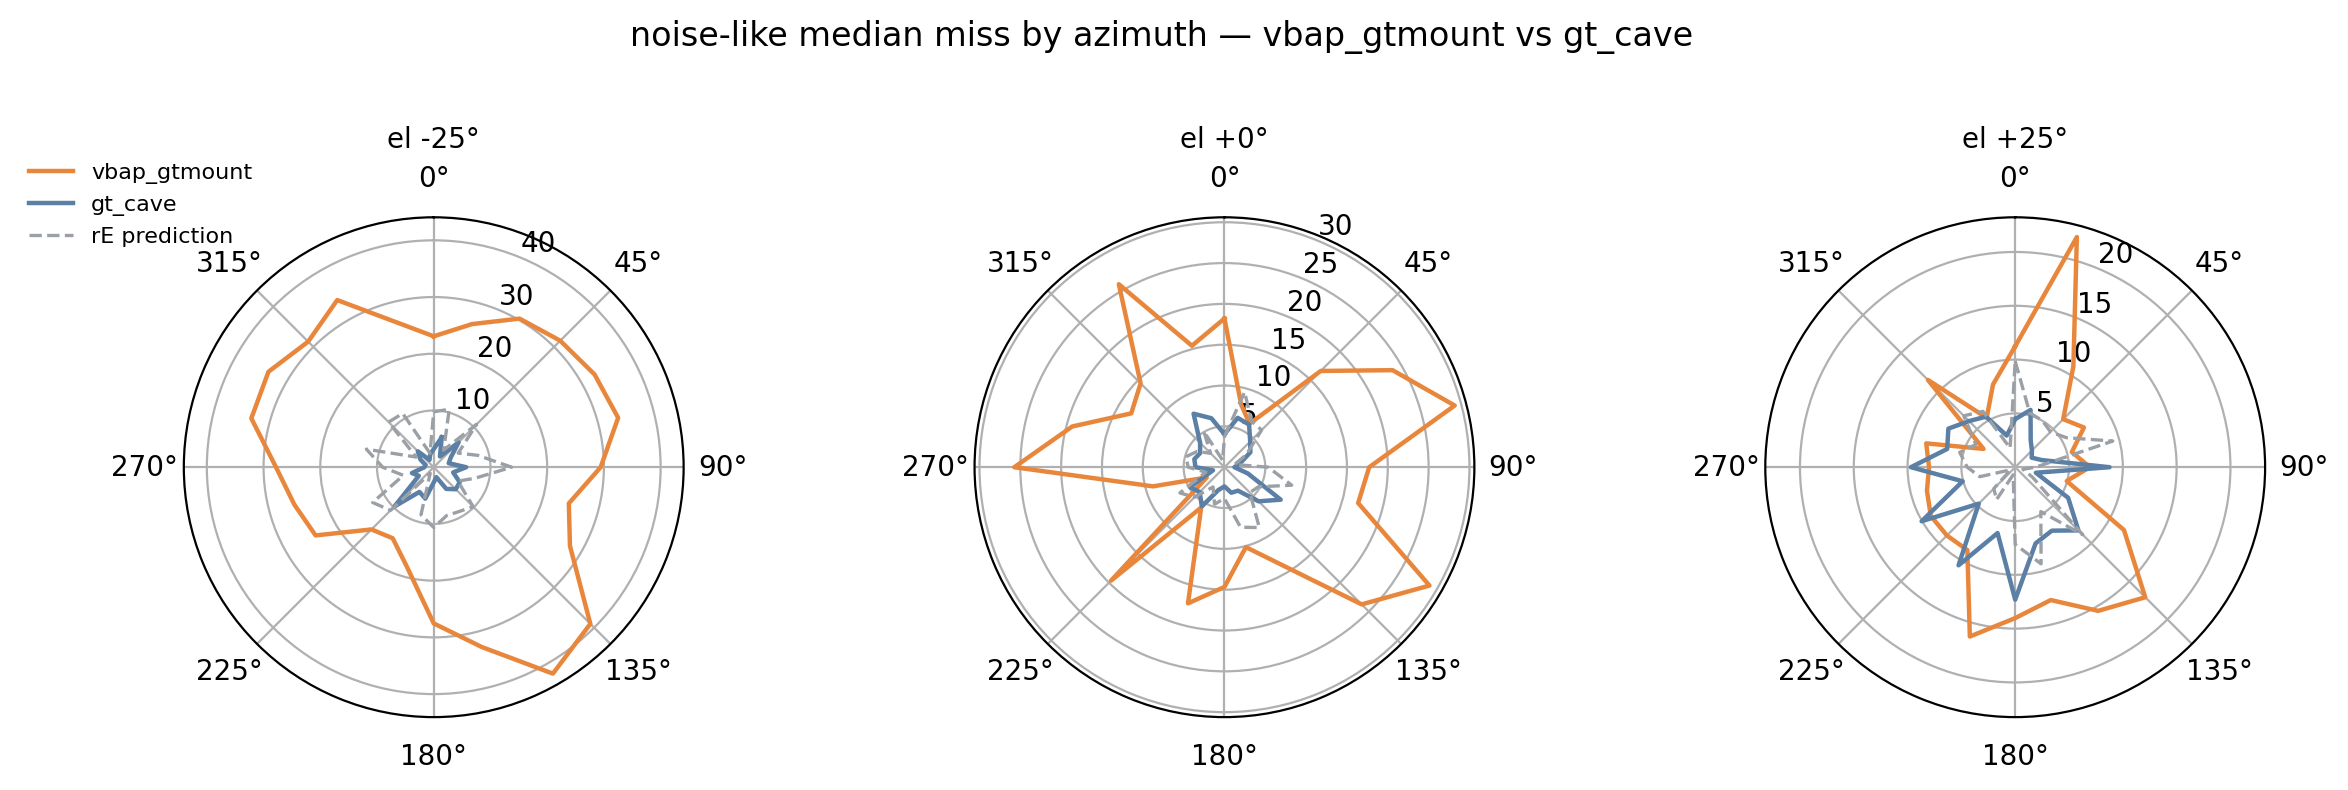

### vbap_mount_sensitivity

,vbap_gtmount,vbap,delta,per_cell_delta_median,n_matched_cells
pink noise,"{'n': 736, 'median': 9.95, 'p90': 16.87, 'ci95...","{'n': 736, 'median': 8.21, 'p90': 13.04, 'ci95...","{'delta': 1.74, 'ci95': [1.2, 2.4], 'significa...",3.7,38
applause,"{'n': 644, 'median': 9.35, 'p90': 17.54, 'ci95...","{'n': 644, 'median': 8.18, 'p90': 14.76, 'ci95...","{'delta': 1.17, 'ci95': [0.6, 2.0], 'significa...",1.79,34
phone ringing,"{'n': 87, 'median': 21.39, 'p90': 33.98, 'ci95...","{'n': 87, 'median': 15.24, 'p90': 26.22, 'ci95...","{'delta': 6.15, 'ci95': [-2.7, 17.5], 'signifi...",5.91,10
250 Hz tone,"{'n': 712, 'median': 60.87, 'p90': 117.23, 'ci...","{'n': 712, 'median': 61.12, 'p90': 123.51, 'ci...","{'delta': -0.26, 'ci95': [-13.6, 6.0], 'signif...",-4.66,36
1000 Hz tone,"{'n': 664, 'median': 37.62, 'p90': 104.67, 'ci...","{'n': 664, 'median': 41.02, 'p90': 110.75, 'ci...","{'delta': -3.41, 'ci95': [-4.4, 4.5], 'signifi...",0.3,35
male speech,"{'n': 66, 'median': 22.26, 'p90': 66.52, 'ci95...","{'n': 66, 'median': 21.38, 'p90': 73.91, 'ci95...","{'delta': 0.88, 'ci95': [-4.1, 5.5], 'signific...",1.17,34
female speech,"{'n': 64, 'median': 16.89, 'p90': 36.73, 'ci95...","{'n': 64, 'median': 11.35, 'p90': 29.03, 'ci95...","{'delta': 5.54, 'ci95': [-0.3, 9.3], 'signific...",5.91,32


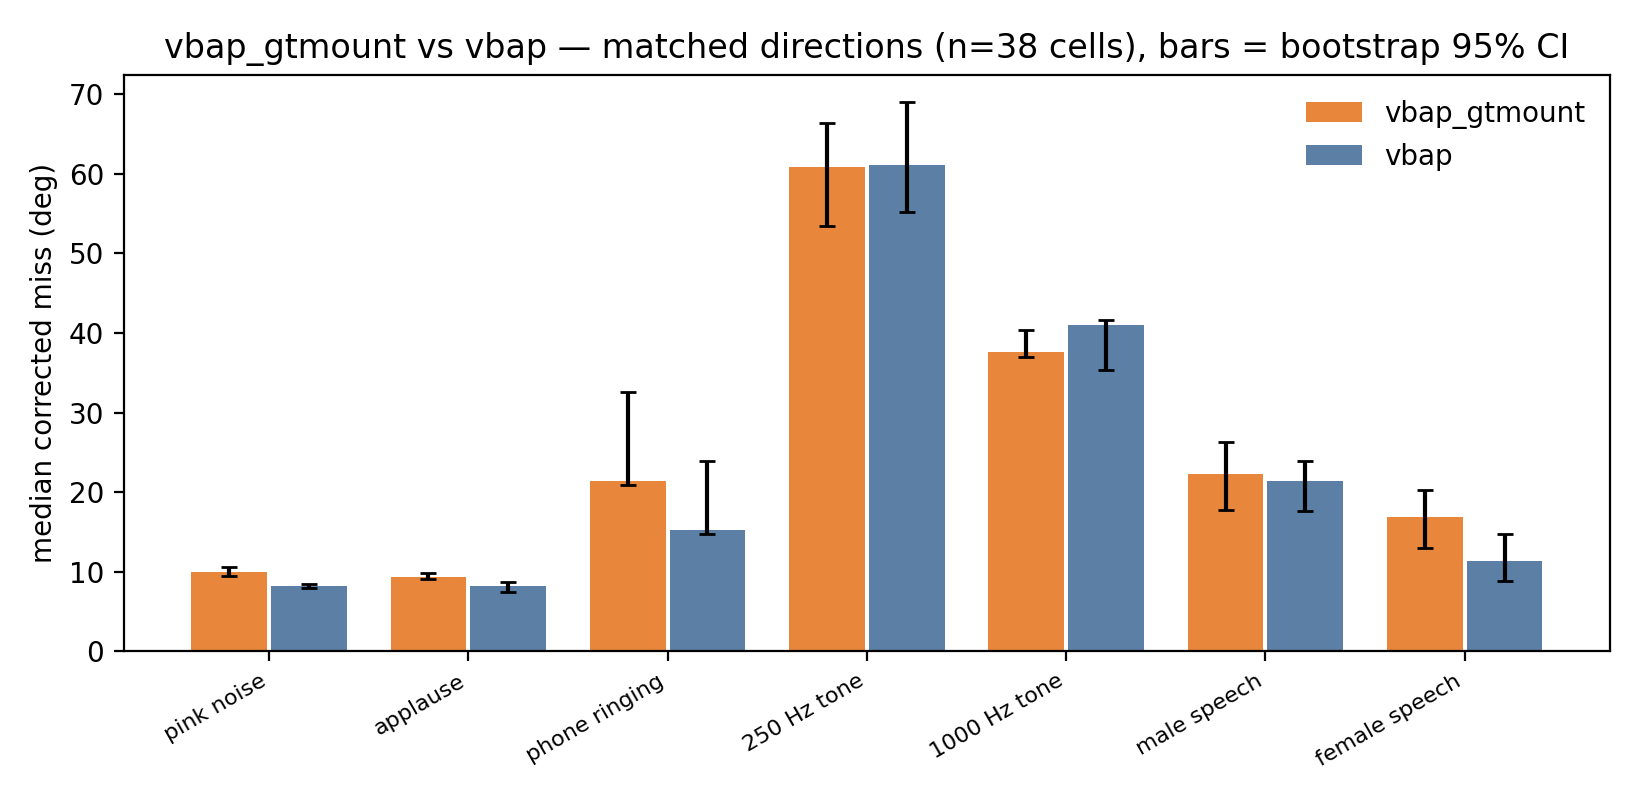

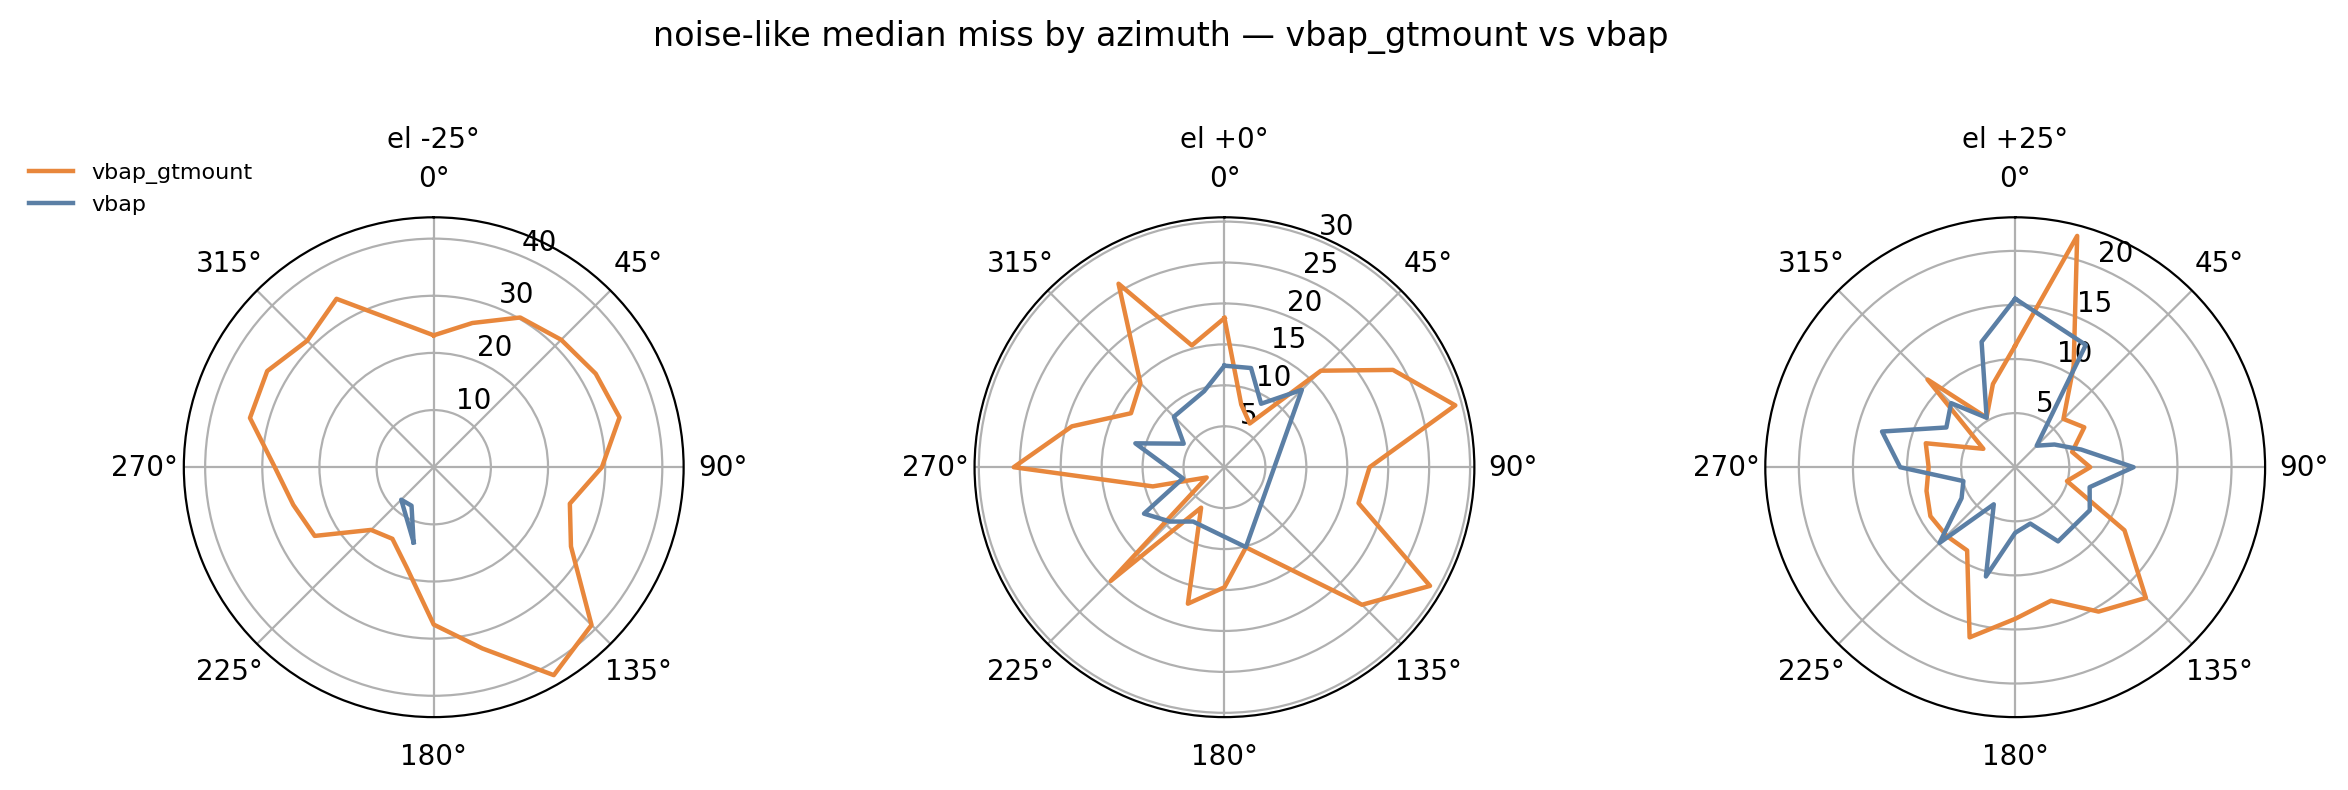

In [12]:
comparisons = cc.run_all(registry, force=FORCE)
for name, comp in comparisons.items():
    display(Markdown(f"### {name}"))
    display(pd.DataFrame(comp["per_stimulus"]).T)
    for fig in comp.get("figures", []):
        if Path(fig).exists():
            display(Image(fig))

## 5. Report

In [13]:
for name in summaries:
    p = ra.load_condition(name)["results_dir"] / "report.md"
    display(Markdown(f"--- \n# Condition: {name}"))
    display(Markdown(p.read_text(encoding="utf-8")))

--- 
# Condition: gt_cave

# Zylia ground-truth localization report

The Zylia ZM-1 is fixed; a single speaker is moved to each labelled position. For every
sound played at each location we estimate the Zylia's perceived direction and compare it
to the true speaker direction -- the **angular miss**.

## Stimuli (classified from the spectrogram)

| block | sound |
|---|---|
| 0 | pink noise |
| 1 | 250 Hz tone |
| 2 | 1000 Hz tone |
| 3 | 6000 Hz tone |
| 4 | phone ringing |
| 5 | applause |
| 6 | female speech |
| 7 | male speech |

## Zylia mounting

- Zylia front (az 0) -> room az -2.1 deg; azimuth handedness flipped; elevation offset +6.9 deg
- Calibration positions (self-consistent): [0.0, 0.0, 105.0, 105.0, 105.0, 120.0, 120.0, 120.0, 135.0, 135.0, 135.0, 15.0, 15.0, 15.0, 150.0, 150.0, 150.0, 165.0, 165.0, 165.0, 180.0, 180.0, 180.0, 195.0, 195.0, 195.0, 210.0, 210.0, 210.0, 225.0, 225.0, 225.0, 240.0, 240.0, 240.0, 255.0, 255.0, 255.0, 270.0, 270.0, 270.0, 285.0, 285.0, 285.0, 30.0, 30.0, 30.0, 300.0, 300.0, 300.0, 315.0, 315.0, 315.0, 330.0, 330.0, 330.0, 345.0, 345.0, 345.0, 45.0, 45.0, 45.0, 60.0, 60.0, 60.0, 75.0, 75.0, 75.0, 90.0, 90.0, 90.0]
- Out-of-frame / anomalous positions: [0.0]

## Localization miss (mount-corrected, median deg)

| position | broadband | tones | all | in calibration |
|---|---|---|---|---|
| az0_el-25_r1.63 | 13.28 | None | 13.28 | False |
| az0_el0_r1.63 | 4.14 | 21.61 | 12.06 | True |
| az0_el25_r1.63 | 4.55 | 52.09 | 10.54 | True |
| az105_el-25_r1.63 | 3.62 | 48.89 | 10.28 | True |
| az105_el0_r1.63 | 3.97 | 22.46 | 10.76 | True |
| az105_el25_r1.63 | 2.11 | None | 2.11 | True |
| az120_el-25_r1.63 | 6.54 | 75.57 | 9.95 | True |
| az120_el0_r1.63 | 8.2 | 66.26 | 8.57 | True |
| az120_el25_r1.63 | 5.69 | 21.39 | 9.61 | True |
| az135_el-25_r1.63 | 5.5 | 57.45 | 9.01 | True |
| az135_el0_r1.63 | 5.91 | 35.91 | 16.38 | True |
| az135_el25_r1.63 | 8.39 | 13.22 | 10.07 | True |
| az15_el-25_r1.63 | 5.58 | 39.05 | 20.49 | True |
| az15_el0_r1.63 | 6.42 | 26.0 | 9.41 | True |
| az15_el25_r1.63 | 5.65 | 15.91 | 15.1 | True |
| az150_el-25_r1.63 | 4.43 | 41.52 | 5.76 | True |
| az150_el0_r1.63 | 3.4 | 19.3 | 12.7 | True |
| az150_el25_r1.63 | 7.5 | 17.79 | 7.58 | True |
| az165_el-25_r1.63 | 2.27 | 39.87 | 32.42 | True |
| az165_el0_r1.63 | 3.98 | 21.54 | 7.12 | True |
| az165_el25_r1.63 | 7.91 | 25.06 | 13.34 | True |
| az180_el-25_r1.63 | 2.73 | 85.5 | 9.09 | True |
| az180_el0_r1.63 | 3.2 | 15.88 | 3.65 | True |
| az180_el25_r1.63 | 13.56 | 24.84 | 21.04 | True |
| az195_el-25_r1.63 | 5.83 | None | 5.83 | True |
| az195_el0_r1.63 | 3.02 | 26.72 | 6.84 | True |
| az195_el25_r1.63 | 6.34 | None | 6.34 | True |
| az210_el-25_r1.63 | 4.99 | 20.62 | 11.58 | True |
| az210_el0_r1.63 | 5.65 | 32.5 | 11.29 | True |
| az210_el25_r1.63 | 10.76 | 43.65 | 11.67 | True |
| az225_el-25_r1.63 | 9.79 | 25.7 | 12.44 | True |
| az225_el0_r1.63 | 4.34 | 18.68 | 7.66 | True |
| az225_el25_r1.63 | 4.82 | 41.04 | 5.33 | True |
| az240_el-25_r1.63 | 3.09 | 61.31 | 19.93 | True |
| az240_el0_r1.63 | 5.01 | 27.41 | 18.73 | True |
| az240_el25_r1.63 | 10.29 | 31.84 | 20.13 | True |
| az255_el-25_r1.63 | 4.17 | 27.48 | 6.32 | True |
| az255_el0_r1.63 | 1.54 | 13.43 | 1.92 | True |
| az255_el25_r1.63 | 7.16 | 18.89 | 10.76 | True |
| az270_el-25_r1.63 | 1.74 | None | 1.74 | True |
| az270_el0_r1.63 | 4.22 | 17.63 | 8.93 | True |
| az270_el25_r1.63 | 9.86 | 17.41 | 12.27 | True |
| az285_el-25_r1.63 | 1.54 | 23.56 | 3.83 | True |
| az285_el0_r1.63 | 3.87 | None | 3.87 | True |
| az285_el25_r1.63 | 6.56 | 31.13 | 11.31 | True |
| az30_el-25_r1.63 | 2.25 | 93.84 | 28.73 | True |
| az30_el0_r1.63 | 6.16 | 40.74 | 10.79 | True |
| az30_el25_r1.63 | 5.26 | 29.2 | 16.19 | True |
| az300_el-25_r1.63 | 3.1 | 61.37 | 9.99 | True |
| az300_el0_r1.63 | 3.92 | 25.68 | 7.37 | True |
| az300_el25_r1.63 | 7.64 | 38.14 | 31.52 | True |
| az315_el-25_r1.63 | 3.96 | 63.55 | 7.74 | True |
| az315_el0_r1.63 | 4.43 | 24.66 | 5.38 | True |
| az315_el25_r1.63 | 6.08 | 6.3 | 6.12 | True |
| az330_el-25_r1.63 | 1.6 | None | 1.6 | True |
| az330_el0_r1.63 | 7.61 | 18.0 | 17.02 | True |
| az330_el25_r1.63 | 5.68 | 42.97 | 15.3 | True |
| az345_el-25_r1.63 | 2.96 | 42.39 | 11.65 | True |
| az345_el0_r1.63 | 6.21 | 37.37 | 9.2 | True |
| az345_el25_r1.63 | 3.9 | 26.05 | 11.88 | True |
| az45_el-25_r1.63 | 6.19 | 67.41 | 6.19 | True |
| az45_el0_r1.63 | 4.5 | 16.86 | 5.34 | True |
| az45_el25_r1.63 | 2.2 | None | 2.2 | True |
| az60_el-25_r1.63 | 3.63 | 70.48 | 22.44 | True |
| az60_el0_r1.63 | 3.97 | 152.53 | 18.16 | True |
| az60_el25_r1.63 | 3.25 | 21.19 | 5.18 | True |
| az75_el-25_r1.63 | 4.17 | 13.18 | 4.17 | True |
| az75_el0_r1.63 | 2.15 | 43.75 | 22.72 | True |
| az75_el25_r1.63 | 2.75 | 31.6 | 17.61 | True |
| az90_el-25_r1.63 | 5.72 | 13.16 | 5.88 | True |
| az90_el0_r1.63 | 1.93 | 25.48 | 12.66 | True |
| az90_el25_r1.63 | 8.77 | 23.77 | 12.77 | True |

## Per sound, at the calibration positions (median deg)

| sound | corrected miss | within-position precision | n |
|---|---|---|---|
| pink noise | 5.09 | 0.73 | 1183 |
| 250 Hz tone | 33.01 | 0.26 | 1203 |
| 1000 Hz tone | 21.88 | 0.27 | 1195 |
| applause | 4.17 | 0.54 | 1329 |
| female speech | 16.07 | 0.15 | 109 |
| male speech | 12.92 | 0.74 | 109 |
| phone ringing | 21.08 | 0.4 | 181 |

## How to read these numbers

- **Within-position precision** = how tightly the Zylia points at one fixed source across repeats. It measures **repeatability only and says nothing about correctness** -- a tone can be 0.1 deg precise yet 15 deg wrong (consistently pointing the wrong way).
- **Mount-corrected miss** = absolute error after removing one fitted Zylia orientation. With only 71 self-consistent position(s) at one elevation, this is an **in-sample, azimuth-only** fit: a lower bound on accuracy (it omits held-out positions), not the same quantity as precision.
- `tests/test_doa.py` confirms the first-order encoding + intensity inversion is self-consistent and correctly co-phased (synthetic plane wave recovered to <1 deg). This validates the *signal-processing*, not real-room performance, which the data above measures.
- **Broadband sounds localize far better than pure tones.** Candidate causes for the tone degradation (not disentangled here): room standing-waves at a single mic point, first-order mode-strength conditioning, and spatial aliasing -- order-1 validity ends near kr=1 (~1.1 kHz for this array). Tones above ~5 kHz (e.g. the 6 kHz block) are excluded entirely as past the array's usable band.
- Out-of-frame positions ([0.0]) are inconsistent with the others under a single fixed mounting and should be checked against lab notes.


--- 
# Condition: gt_anechoic

# Zylia ground-truth localization report

The Zylia ZM-1 is fixed; a single speaker is moved to each labelled position. For every
sound played at each location we estimate the Zylia's perceived direction and compare it
to the true speaker direction -- the **angular miss**.

## Stimuli (classified from the spectrogram)

| block | sound |
|---|---|
| 0 | pink noise |
| 1 | 250 Hz tone |
| 2 | 1000 Hz tone |
| 3 | 6000 Hz tone |
| 4 | phone ringing |
| 5 | applause |
| 6 | female speech |
| 7 | male speech |

## Zylia mounting

- Zylia front (az 0) -> room az 0.3 deg; azimuth handedness flipped; elevation offset -0.7 deg
- Calibration positions (self-consistent): [0.0, 0.0, 0.0, 120.0, 120.0, 120.0, 150.0, 150.0, 150.0, 180.0, 180.0, 180.0, 210.0, 210.0, 210.0, 240.0, 240.0, 240.0, 270.0, 270.0, 270.0, 30.0, 30.0, 30.0, 300.0, 300.0, 300.0, 330.0, 330.0, 330.0, 60.0, 60.0, 60.0, 90.0, 90.0, 90.0]
- Out-of-frame / anomalous positions: none

## Localization miss (mount-corrected, median deg)

| position | broadband | tones | all | in calibration |
|---|---|---|---|---|
| az0_el-25_r1.63 | 1.85 | 3.58 | 2.06 | True |
| az0_el0_r1.63 | 1.37 | 8.43 | 1.43 | True |
| az0_el25_r1.63 | 2.07 | None | 2.07 | True |
| az120_el-25_r1.63 | 1.76 | None | 1.76 | True |
| az120_el0_r1.63 | 4.55 | 5.03 | 4.55 | True |
| az120_el25_r1.63 | 2.62 | 4.5 | 2.85 | True |
| az150_el-25_r1.63 | 2.6 | 4.59 | 3.79 | True |
| az150_el0_r1.63 | 5.0 | 6.98 | 5.42 | True |
| az150_el25_r1.63 | 3.23 | 5.0 | 3.54 | True |
| az180_el-25_r1.63 | 1.22 | None | 1.22 | True |
| az180_el0_r1.63 | 4.83 | None | 4.83 | True |
| az180_el25_r1.63 | 1.08 | 3.05 | 2.14 | True |
| az210_el-25_r1.63 | 1.41 | 5.37 | 3.3 | True |
| az210_el0_r1.63 | 5.0 | 5.71 | 5.08 | True |
| az210_el25_r1.63 | 2.11 | None | 2.11 | True |
| az240_el-25_r1.63 | 1.01 | None | 1.01 | True |
| az240_el0_r1.63 | 3.27 | 5.29 | 3.73 | True |
| az240_el25_r1.63 | 3.45 | None | 3.45 | True |
| az270_el-25_r1.63 | 3.18 | None | 3.18 | True |
| az270_el0_r1.63 | 2.11 | 6.7 | 3.54 | True |
| az270_el25_r1.63 | 5.81 | None | 5.81 | True |
| az30_el-25_r1.63 | 1.46 | 4.92 | 2.45 | True |
| az30_el0_r1.63 | 1.48 | None | 1.48 | True |
| az30_el25_r1.63 | 1.17 | None | 1.17 | True |
| az300_el-25_r1.63 | 1.9 | None | 1.9 | True |
| az300_el0_r1.63 | 1.99 | 4.91 | 1.99 | True |
| az300_el25_r1.63 | 3.49 | 6.28 | 3.49 | True |
| az330_el-25_r1.63 | 0.79 | None | 0.79 | True |
| az330_el0_r1.63 | 3.69 | 5.05 | 4.37 | True |
| az330_el25_r1.63 | 5.14 | None | 5.14 | True |
| az60_el-25_r1.63 | 1.81 | 5.82 | 2.21 | True |
| az60_el0_r1.63 | 1.31 | 7.41 | 3.67 | True |
| az60_el25_r1.63 | 1.83 | None | 1.83 | True |
| az90_el-25_r1.63 | 1.66 | None | 1.66 | True |
| az90_el0_r1.63 | 2.76 | None | 2.76 | True |
| az90_el25_r1.63 | 2.17 | 3.99 | 3.09 | True |

## Per sound, at the calibration positions (median deg)

| sound | corrected miss | within-position precision | n |
|---|---|---|---|
| 1000 Hz tone | 5.36 | 0.01 | 380 |
| applause | 1.93 | 0.04 | 643 |
| female speech | 3.66 | 0.01 | 56 |
| male speech | 3.55 | 0.03 | 50 |
| 250 Hz tone | 4.39 | 0.01 | 329 |
| pink noise | 2.56 | 0.03 | 310 |
| phone ringing | 5.54 | 0.01 | 27 |

## How to read these numbers

- **Within-position precision** = how tightly the Zylia points at one fixed source across repeats. It measures **repeatability only and says nothing about correctness** -- a tone can be 0.1 deg precise yet 15 deg wrong (consistently pointing the wrong way).
- **Mount-corrected miss** = absolute error after removing one fitted Zylia orientation. With only 36 self-consistent position(s) at one elevation, this is an **in-sample, azimuth-only** fit: a lower bound on accuracy (it omits held-out positions), not the same quantity as precision.
- `tests/test_doa.py` confirms the first-order encoding + intensity inversion is self-consistent and correctly co-phased (synthetic plane wave recovered to <1 deg). This validates the *signal-processing*, not real-room performance, which the data above measures.
- **Broadband sounds localize far better than pure tones.** Candidate causes for the tone degradation (not disentangled here): room standing-waves at a single mic point, first-order mode-strength conditioning, and spatial aliasing -- order-1 validity ends near kr=1 (~1.1 kHz for this array). Tones above ~5 kHz (e.g. the 6 kHz block) are excluded entirely as past the array's usable band.
- Out-of-frame positions (none) are inconsistent with the others under a single fixed mounting and should be checked against lab notes.


--- 
# Condition: vbap

# Zylia ground-truth localization report

The Zylia ZM-1 is fixed; a single speaker is moved to each labelled position. For every
sound played at each location we estimate the Zylia's perceived direction and compare it
to the true speaker direction -- the **angular miss**.

## Stimuli (classified from the spectrogram)

| block | sound |
|---|---|
| 0 | pink noise |
| 1 | 250 Hz tone |
| 2 | 1000 Hz tone |
| 3 | 6000 Hz tone |
| 4 | phone ringing |
| 5 | applause |
| 6 | female speech |
| 7 | male speech |

## Zylia mounting

- rigid-rotation mount: Zylia front (az 0) -> room az 1.0 deg, el +2.1 deg; handedness flipped (reflection)
- Calibration positions (self-consistent): [194.88, 210.03, 225.0, 0.0, 14.98, 165.02, 209.88, 225.0, 240.12, 255.02, 284.98, 299.88, 30.18, 315.0, 345.02, 45.0, 0.0, 104.88, 120.03, 149.97, 165.12, 180.0, 194.88, 210.03, 225.0, 239.97, 255.12, 270.0, 284.88, 30.03, 300.03, 315.0, 329.97, 345.12, 45.0, 59.97, 75.12, 90.0]
- Out-of-frame / anomalous positions: [0.0, 104.88, 120.03, 135.0, 14.88, 149.97, 165.12, 180.0, 239.97, 255.12, 270.0, 284.88, 30.03, 300.03, 315.0, 329.97, 45.0, 59.97, 75.12, 90.0, 104.98, 120.18, 135.0, 149.82, 180.0, 194.98, 270.0, 329.82, 60.12, 75.02, 90.0, 135.0, 14.88]

**Calibration caveats:**
- mount transform is a reflection (azimuth handedness flipped)

## Localization miss (mount-corrected, median deg)

| position | broadband | tones | all | in calibration |
|---|---|---|---|---|
| az0_el-25_r1.633 | 20.91 | 47.21 | 45.07 | False |
| az104.88_el-25_r1.633 | 22.55 | 62.12 | 54.84 | False |
| az120.03_el-25.02_r1.632 | 25.86 | 94.53 | 41.5 | False |
| az135_el-25.13_r1.625 | 38.16 | 118.03 | 39.23 | False |
| az14.88_el-25_r1.633 | 24.0 | 52.66 | 42.29 | False |
| az149.97_el-25.02_r1.632 | 40.34 | 129.47 | 52.04 | False |
| az165.12_el-25_r1.633 | 31.93 | 138.01 | 63.06 | False |
| az180_el-25_r1.633 | 24.42 | 120.39 | 25.21 | False |
| az194.88_el-25_r1.633 | 13.82 | 54.33 | 29.32 | True |
| az210.03_el-25.02_r1.632 | 7.84 | 31.98 | 15.14 | True |
| az225_el-25.13_r1.625 | 8.32 | 34.82 | 22.9 | True |
| az239.97_el-25.02_r1.632 | 15.4 | 25.61 | 16.6 | False |
| az255.12_el-25_r1.633 | 13.43 | 11.52 | 13.23 | False |
| az270_el-25_r1.633 | 16.97 | 41.88 | 16.97 | False |
| az284.88_el-25_r1.633 | 27.01 | 50.41 | 27.01 | False |
| az30.03_el-25.02_r1.632 | 29.64 | 43.95 | 36.14 | False |
| az300.03_el-25.02_r1.632 | 27.95 | 58.92 | 29.41 | False |
| az315_el-25.13_r1.625 | 26.09 | 44.04 | 29.84 | False |
| az329.97_el-25.02_r1.632 | 29.12 | 60.05 | 33.12 | False |
| az45_el-25.13_r1.625 | 31.23 | 27.82 | 30.36 | False |
| az59.97_el-25.02_r1.632 | 31.14 | 21.43 | 31.14 | False |
| az75.12_el-25_r1.633 | 33.52 | 27.75 | 33.52 | False |
| az90_el-25_r1.633 | 28.11 | 36.19 | 32.36 | False |
| az0_el0_r1.63 | 12.8 | 31.13 | 21.74 | True |
| az104.98_el0_r1.625 | 13.82 | 64.39 | 41.19 | False |
| az120.18_el0_r1.631 | 24.58 | 57.41 | 34.97 | False |
| az135_el0_r1.626 | 22.44 | 39.55 | 22.77 | False |
| az14.98_el0_r1.625 | 12.7 | 12.93 | 12.7 | True |
| az149.82_el0_r1.631 | 110.98 | None | 110.98 | False |
| az165.02_el0_r1.625 | 10.62 | 110.31 | 24.91 | True |
| az180_el0_r1.63 | 25.58 | 67.1 | 54.55 | False |
| az194.98_el0_r1.625 | 28.66 | 67.5 | 44.49 | False |
| az209.88_el0_r1.626 | 6.79 | 56.84 | 10.75 | True |
| az225_el0_r1.626 | 10.22 | None | 10.22 | True |
| az240.12_el0_r1.626 | 12.0 | 36.66 | 22.49 | True |
| az255.02_el0_r1.625 | 5.26 | 40.93 | 15.13 | True |
| az270_el0_r1.63 | 15.26 | 37.35 | 34.28 | False |
| az284.98_el0_r1.625 | 11.69 | None | 11.69 | True |
| az299.88_el0_r1.626 | 6.81 | 31.49 | 7.02 | True |
| az30.18_el0_r1.631 | 8.21 | 29.53 | 16.02 | True |
| az315_el0_r1.626 | 8.78 | 5.08 | 7.53 | True |
| az329.82_el0_r1.631 | 21.05 | 29.0 | 21.05 | False |
| az345.02_el0_r1.625 | 9.82 | 57.37 | 17.82 | True |
| az45_el0_r1.626 | 13.75 | 36.97 | 15.12 | True |
| az60.12_el0_r1.626 | 19.89 | 32.58 | 19.89 | False |
| az75.02_el0_r1.625 | 29.62 | 23.86 | 29.62 | False |
| az90_el0_r1.63 | 16.94 | 11.0 | 16.35 | False |
| az0_el25_r1.633 | 15.58 | 105.32 | 21.86 | True |
| az104.88_el25_r1.633 | 8.77 | 35.95 | 17.57 | True |
| az120.03_el25.02_r1.632 | 7.97 | 37.98 | 13.42 | True |
| az135_el25.13_r1.625 | 12.43 | 39.66 | 26.96 | False |
| az14.88_el25_r1.633 | 25.18 | 95.26 | 28.57 | False |
| az149.97_el25.02_r1.632 | 9.95 | 31.0 | 14.93 | True |
| az165.12_el25_r1.633 | 6.36 | 63.56 | 26.31 | True |
| az180_el25_r1.633 | 8.16 | 59.67 | 24.75 | True |
| az194.88_el25_r1.633 | 11.6 | 72.27 | 12.14 | True |
| az210.03_el25.02_r1.632 | 4.33 | 49.61 | 13.79 | True |
| az225_el25.13_r1.625 | 9.95 | 61.37 | 15.37 | True |
| az239.97_el25.02_r1.632 | 5.72 | 102.98 | 13.95 | True |
| az255.12_el25_r1.633 | 5.1 | 87.92 | 13.64 | True |
| az270_el25_r1.633 | 10.64 | 113.23 | 19.96 | True |
| az284.88_el25_r1.633 | 12.75 | 93.04 | 19.18 | True |
| az30.03_el25.02_r1.632 | 13.05 | 103.3 | 14.92 | True |
| az300.03_el25.02_r1.632 | 7.53 | 59.56 | 17.47 | True |
| az315_el25.13_r1.625 | 8.7 | 75.15 | 16.8 | True |
| az329.97_el25.02_r1.632 | 6.38 | 97.08 | 10.34 | True |
| az345.12_el25_r1.633 | 12.4 | 119.63 | 23.24 | True |
| az45_el25.13_r1.625 | 2.9 | 89.1 | 9.35 | True |
| az59.97_el25.02_r1.632 | 4.26 | 60.09 | 14.99 | True |
| az75.12_el25_r1.633 | 3.97 | 70.73 | 12.24 | True |
| az90_el25_r1.633 | 11.04 | 68.25 | 16.6 | True |

## Per sound, at the calibration positions (median deg)

| sound | corrected miss | within-position precision | n |
|---|---|---|---|
| pink noise | 8.21 | 1.46 | 736 |
| 250 Hz tone | 61.12 | 0.32 | 712 |
| 1000 Hz tone | 41.02 | 0.31 | 664 |
| female speech | 11.35 | 2.09 | 64 |
| male speech | 21.38 | 0.76 | 66 |
| phone ringing | 15.24 | 0.52 | 87 |
| applause | 8.18 | 1.25 | 644 |

## How to read these numbers

- **Within-position precision** = how tightly the Zylia points at one fixed source across repeats. It measures **repeatability only and says nothing about correctness** -- a tone can be 0.1 deg precise yet 15 deg wrong (consistently pointing the wrong way).
- **Mount-corrected miss** = absolute error after removing one fitted Zylia orientation. With only 38 self-consistent position(s) at one elevation, this is an **in-sample, azimuth-only** fit: a lower bound on accuracy (it omits held-out positions), not the same quantity as precision.
- `tests/test_doa.py` confirms the first-order encoding + intensity inversion is self-consistent and correctly co-phased (synthetic plane wave recovered to <1 deg). This validates the *signal-processing*, not real-room performance, which the data above measures.
- **Broadband sounds localize far better than pure tones.** Candidate causes for the tone degradation (not disentangled here): room standing-waves at a single mic point, first-order mode-strength conditioning, and spatial aliasing -- order-1 validity ends near kr=1 (~1.1 kHz for this array). Tones above ~5 kHz (e.g. the 6 kHz block) are excluded entirely as past the array's usable band.
- Out-of-frame positions ([0.0, 104.88, 120.03, 135.0, 14.88, 149.97, 165.12, 180.0, 239.97, 255.12, 270.0, 284.88, 30.03, 300.03, 315.0, 329.97, 45.0, 59.97, 75.12, 90.0, 104.98, 120.18, 135.0, 149.82, 180.0, 194.98, 270.0, 329.82, 60.12, 75.02, 90.0, 135.0, 14.88]) are inconsistent with the others under a single fixed mounting and should be checked against lab notes.


--- 
# Condition: vbap_gtmount

# Zylia ground-truth localization report

The Zylia ZM-1 is fixed; a single speaker is moved to each labelled position. For every
sound played at each location we estimate the Zylia's perceived direction and compare it
to the true speaker direction -- the **angular miss**.

## Stimuli (classified from the spectrogram)

| block | sound |
|---|---|
| 0 | pink noise |
| 1 | 250 Hz tone |
| 2 | 1000 Hz tone |
| 3 | 6000 Hz tone |
| 4 | phone ringing |
| 5 | applause |
| 6 | female speech |
| 7 | male speech |

## Zylia mounting

- Zylia front (az 0) -> room az -2.1 deg; azimuth handedness flipped; elevation offset +6.9 deg
- Calibration positions (self-consistent): [0.0, 104.88, 120.03, 135.0, 14.88, 149.97, 165.12, 180.0, 194.88, 210.03, 225.0, 239.97, 255.12, 270.0, 284.88, 30.03, 300.03, 315.0, 329.97, 45.0, 59.97, 75.12, 90.0, 0.0, 104.98, 120.18, 135.0, 14.98, 149.82, 165.02, 180.0, 194.98, 209.88, 225.0, 240.12, 255.02, 270.0, 284.98, 299.88, 30.18, 315.0, 329.82, 345.02, 45.0, 60.12, 75.02, 90.0, 0.0, 104.88, 120.03, 135.0, 14.88, 149.97, 165.12, 180.0, 194.88, 210.03, 225.0, 239.97, 255.12, 270.0, 284.88, 30.03, 300.03, 315.0, 329.97, 345.12, 45.0, 59.97, 75.12, 90.0]
- Out-of-frame / anomalous positions: none

**Calibration caveats:**
- mounting applied from an external (ground-truth) calibration, not re-fit on this condition's data

## Localization miss (mount-corrected, median deg)

| position | broadband | tones | all | in calibration |
|---|---|---|---|---|
| az0_el-25_r1.633 | 23.37 | 51.99 | 49.73 | True |
| az104.88_el-25_r1.633 | 25.0 | 66.81 | 58.97 | True |
| az120.03_el-25.02_r1.632 | 27.75 | 99.38 | 42.44 | True |
| az135_el-25.13_r1.625 | 39.28 | 120.24 | 40.33 | True |
| az14.88_el-25_r1.633 | 26.22 | 54.42 | 45.82 | True |
| az149.97_el-25.02_r1.632 | 42.2 | 129.32 | 52.95 | True |
| az165.12_el-25_r1.633 | 34.08 | 134.78 | 67.34 | True |
| az180_el-25_r1.633 | 27.56 | 119.61 | 28.23 | True |
| az194.88_el-25_r1.633 | 18.21 | 61.25 | 37.04 | True |
| az210.03_el-25.02_r1.632 | 14.17 | 38.15 | 25.07 | True |
| az225_el-25.13_r1.625 | 16.32 | 37.23 | 34.05 | True |
| az239.97_el-25.02_r1.632 | 24.17 | 20.77 | 23.86 | True |
| az255.12_el-25_r1.633 | 24.86 | 19.79 | 24.67 | True |
| az270_el-25_r1.633 | 27.95 | 48.58 | 27.95 | True |
| az284.88_el-25_r1.633 | 33.3 | 56.97 | 33.3 | True |
| az30.03_el-25.02_r1.632 | 30.39 | 45.2 | 38.63 | True |
| az300.03_el-25.02_r1.632 | 33.36 | 64.4 | 34.9 | True |
| az315_el-25.13_r1.625 | 31.33 | 52.11 | 38.55 | True |
| az329.97_el-25.02_r1.632 | 34.02 | 67.06 | 40.72 | True |
| az45_el-25.13_r1.625 | 31.96 | 29.71 | 31.01 | True |
| az59.97_el-25.02_r1.632 | 33.17 | 23.65 | 33.16 | True |
| az75.12_el-25_r1.633 | 33.69 | 30.61 | 33.69 | True |
| az90_el-25_r1.633 | 29.53 | 40.23 | 33.7 | True |
| az0_el0_r1.63 | 18.25 | 31.72 | 22.26 | True |
| az104.98_el0_r1.625 | 17.03 | 64.3 | 38.29 | True |
| az120.18_el0_r1.631 | 29.95 | 57.27 | 37.83 | True |
| az135_el0_r1.626 | 27.66 | 41.73 | 28.71 | True |
| az14.98_el0_r1.625 | 8.02 | 8.88 | 8.02 | True |
| az149.82_el0_r1.631 | 111.4 | None | 111.4 | True |
| az165.02_el0_r1.625 | 10.99 | 106.49 | 31.33 | True |
| az180_el0_r1.63 | 16.75 | 75.43 | 54.63 | True |
| az194.98_el0_r1.625 | 18.45 | 75.89 | 34.7 | True |
| az209.88_el0_r1.626 | 5.74 | 54.86 | 11.41 | True |
| az225_el0_r1.626 | 19.65 | None | 19.65 | True |
| az240.12_el0_r1.626 | 3.15 | 36.64 | 33.83 | True |
| az255.02_el0_r1.625 | 9.32 | 38.93 | 10.06 | True |
| az270_el0_r1.63 | 26.04 | 32.55 | 30.71 | True |
| az284.98_el0_r1.625 | 17.52 | None | 17.52 | True |
| az299.88_el0_r1.626 | 14.03 | 39.84 | 15.78 | True |
| az30.18_el0_r1.631 | 6.17 | 26.08 | 12.03 | True |
| az315_el0_r1.626 | 14.6 | 13.0 | 13.12 | True |
| az329.82_el0_r1.631 | 26.36 | 22.35 | 26.36 | True |
| az345.02_el0_r1.625 | 15.4 | 59.47 | 18.02 | True |
| az45_el0_r1.626 | 14.19 | 36.92 | 16.34 | True |
| az60.12_el0_r1.626 | 23.91 | 32.09 | 23.91 | True |
| az75.02_el0_r1.625 | 32.28 | 23.96 | 32.02 | True |
| az90_el0_r1.63 | 19.03 | 10.9 | 16.8 | True |
| az0_el25_r1.633 | 11.23 | 105.48 | 17.63 | True |
| az104.88_el25_r1.633 | 4.96 | 32.44 | 14.33 | True |
| az120.03_el25.02_r1.632 | 11.69 | 33.76 | 18.32 | True |
| az135_el25.13_r1.625 | 17.44 | 36.08 | 29.26 | True |
| az14.88_el25_r1.633 | 22.21 | 92.14 | 25.51 | True |
| az149.97_el25.02_r1.632 | 17.69 | 28.18 | 19.09 | True |
| az165.12_el25_r1.633 | 14.36 | 63.14 | 33.66 | True |
| az180_el25_r1.633 | 16.02 | 61.51 | 33.56 | True |
| az194.88_el25_r1.633 | 16.55 | 74.05 | 20.71 | True |
| az210.03_el25.02_r1.632 | 8.96 | 49.48 | 23.77 | True |
| az225_el25.13_r1.625 | 9.16 | 54.33 | 23.77 | True |
| az239.97_el25.02_r1.632 | 9.18 | 99.69 | 18.04 | True |
| az255.12_el25_r1.633 | 8.67 | 78.34 | 17.71 | True |
| az270_el25_r1.633 | 8.17 | 106.56 | 13.09 | True |
| az284.88_el25_r1.633 | 8.57 | 86.19 | 12.04 | True |
| az30.03_el25.02_r1.632 | 10.79 | 98.56 | 12.68 | True |
| az300.03_el25.02_r1.632 | 3.66 | 56.18 | 20.91 | True |
| az315_el25.13_r1.625 | 11.64 | 71.64 | 23.64 | True |
| az329.97_el25.02_r1.632 | 5.86 | 93.81 | 12.78 | True |
| az345.12_el25_r1.633 | 8.25 | 118.66 | 18.23 | True |
| az45_el25.13_r1.625 | 6.44 | 85.86 | 12.3 | True |
| az59.97_el25.02_r1.632 | 7.37 | 58.91 | 18.25 | True |
| az75.12_el25_r1.633 | 5.66 | 63.93 | 8.68 | True |
| az90_el25_r1.633 | 7.0 | 61.48 | 12.58 | True |

## Per sound, at the calibration positions (median deg)

| sound | corrected miss | within-position precision | n |
|---|---|---|---|
| pink noise | 17.32 | 1.77 | 1362 |
| 250 Hz tone | 51.8 | 0.34 | 1282 |
| 1000 Hz tone | 47.05 | 0.37 | 1215 |
| phone ringing | 25.16 | 0.45 | 108 |
| applause | 15.05 | 1.41 | 1200 |
| male speech | 31.51 | 0.94 | 116 |
| female speech | 22.6 | 2.06 | 98 |

## How to read these numbers

- **Within-position precision** = how tightly the Zylia points at one fixed source across repeats. It measures **repeatability only and says nothing about correctness** -- a tone can be 0.1 deg precise yet 15 deg wrong (consistently pointing the wrong way).
- **Mount-corrected miss** = absolute error after removing one fitted Zylia orientation. With only 71 self-consistent position(s) at one elevation, this is an **in-sample, azimuth-only** fit: a lower bound on accuracy (it omits held-out positions), not the same quantity as precision.
- `tests/test_doa.py` confirms the first-order encoding + intensity inversion is self-consistent and correctly co-phased (synthetic plane wave recovered to <1 deg). This validates the *signal-processing*, not real-room performance, which the data above measures.
- **Broadband sounds localize far better than pure tones.** Candidate causes for the tone degradation (not disentangled here): room standing-waves at a single mic point, first-order mode-strength conditioning, and spatial aliasing -- order-1 validity ends near kr=1 (~1.1 kHz for this array). Tones above ~5 kHz (e.g. the 6 kHz block) are excluded entirely as past the array's usable band.
- Out-of-frame positions (none) are inconsistent with the others under a single fixed mounting and should be checked against lab notes.


## 6. Paper layer — derived statistics and publication figures

Heavy lifting lives in two scripts; this section only displays their outputs.

- `paper_stats.py` recomputes **every derived number quoted in the paper** (room
  multipliers and tails, the elevation opposition, the ear-level upward pull, instrument
  spec, speaker-geometry skew, reference-layout table) into `results/paper_stats.json`.
- `make_paper_figures.py` builds the print-safe publication figures straight into
  `Paper/figures/` (grayscale-survivable encodings: hatching, markers, line styles,
  monotonic colormaps).

Rerun both after any comparison rerun; then rebuild the paper.

In [14]:
import paper_stats
paper_stats.main()
ps = json.loads((EXP_DIR / "results" / "paper_stats.json").read_text())

display(Markdown("### Room effect per stimulus (medians, multiplier, tails)"))
display(pd.DataFrame(ps["room_effect"]["per_stimulus"]).T[
    ["anechoic_median", "cave_median", "room_multiplier", "cave_p90", "delta_median"]])

display(Markdown("### The elevation opposition (noise-like deltas, deg)"))
opp = pd.DataFrame({
    "room penalty (CAVE - anechoic)":
        {el: v["delta_median"] for el, v in ps["room_effect"]["noise_like_by_elevation"].items()},
    "rendering penalty (phantom - physical)":
        {el: v["delta_median"] for el, v in ps["vbap_structure"]["penalty_by_elevation"].items()},
})
opp.index.name = "elevation (deg)"
display(opp)

display(Markdown("### Ear-level phantom structure (the upward pull)"))
display(pd.Series(ps["vbap_structure"]["ear_level"]))
display(Markdown(
    f"Speaker budget: **{ps['speaker_geometry']['n_above_20deg']} of "
    f"{ps['speaker_geometry']['n_speakers']}** speakers above +20°, only "
    f"**{ps['speaker_geometry']['n_within_6deg_ear_level']}** within 6° of ear level "
    f"(mean {ps['speaker_geometry']['mean_elevation']}°)."))

display(Markdown("### Instrument spec (anechoic chamber)"))
display(pd.Series(ps["instrument"]["anechoic_precision_by_stimulus"], name="precision (deg)"))
display(Markdown(
    f"Day-to-day azimuth-offset spread {ps['instrument']['anechoic_day_az_offset_spread']}°; "
    f"mount elevation offset {ps['instrument']['mount_elevation_offset']['cave']}° in the CAVE vs "
    f"{ps['instrument']['mount_elevation_offset']['anechoic']}° in the chamber; "
    f"{ps['instrument']['trials']['total']:,} trials total."))

display(Markdown("### Reference-layout comparison (optimizer objective, same room)"))
display(pd.DataFrame(ps["layout_comparison"]).T)

wrote /Volumes/WallaceLab/JordanWashecheck/Audio_Localization_Jordan/zylia_analysis/results/paper_stats.json
{"_provenance": "Derived statistics quoted in the AES paper; regenerate with python3 paper_stats.py. Sources: results/<cond>/, results/comparisons/<name>/, CaveSpeakerPositions.csv, speaker_optimization_viz.ipynb.", "room_effect": "...", "vbap_structure": "...", "instrument": "...", "speaker_geometry": "...", "layout_comparison": "..."}


### Room effect per stimulus (medians, multiplier, tails)

,anechoic_median,cave_median,room_multiplier,cave_p90,delta_median
pink noise,2.56,5.13,2.0,10.05,2.57
applause,1.95,4.05,2.08,9.62,2.1
phone ringing,5.54,21.06,3.8,46.1,15.52
250 Hz tone,4.39,29.17,6.64,111.85,24.78
1000 Hz tone,5.54,25.77,4.65,62.87,20.23
male speech,3.58,13.39,3.74,26.95,9.81
female speech,3.67,16.99,4.63,32.42,13.32


### The elevation opposition (noise-like deltas, deg)

,room penalty (CAVE - anechoic),rendering penalty (phantom - physical)
elevation (deg),,
-25,1.78,26.19
0,0.37,12.45
25,4.36,2.82


...

### Instrument spec (anechoic chamber)

1000 Hz tone     0.01
applause         0.04
female speech    0.01
male speech      0.03
250 Hz tone      0.01
pink noise       0.03
phone ringing    0.01
Name: precision (deg), dtype: float64

Day-to-day azimuth-offset spread 2.15°; mount elevation offset 6.9° in the CAVE vs -0.7° in the chamber; 22,320 trials total.

### Reference-layout comparison (optimizer objective, same room)

,coverage_pct,energy_err,up_max_gap_rad,cost
ITU 7.1.4 (11 spk),74.61,0.2794,0.9854,12.1029
Atmos 9.1.6 (24 spk),74.61,0.2688,0.9854,12.2816
Equidistant (24 spk),100.00,0.0376,0.5295,0.1355
Optimized (24 spk),100.00,0.0333,0.5102,0.1054
Random Init (24 spk),100.00,0.0498,0.6257,0.2267


wrote /Volumes/WallaceLab/JordanWashecheck/Audio_Localization_Jordan/Paper/figures/content-ladder.png
wrote /Volumes/WallaceLab/JordanWashecheck/Audio_Localization_Jordan/Paper/figures/miss-maps-physical-vs-phantom.png
wrote /Volumes/WallaceLab/JordanWashecheck/Audio_Localization_Jordan/Paper/figures/elevation-opposition.png


**content-ladder.png**

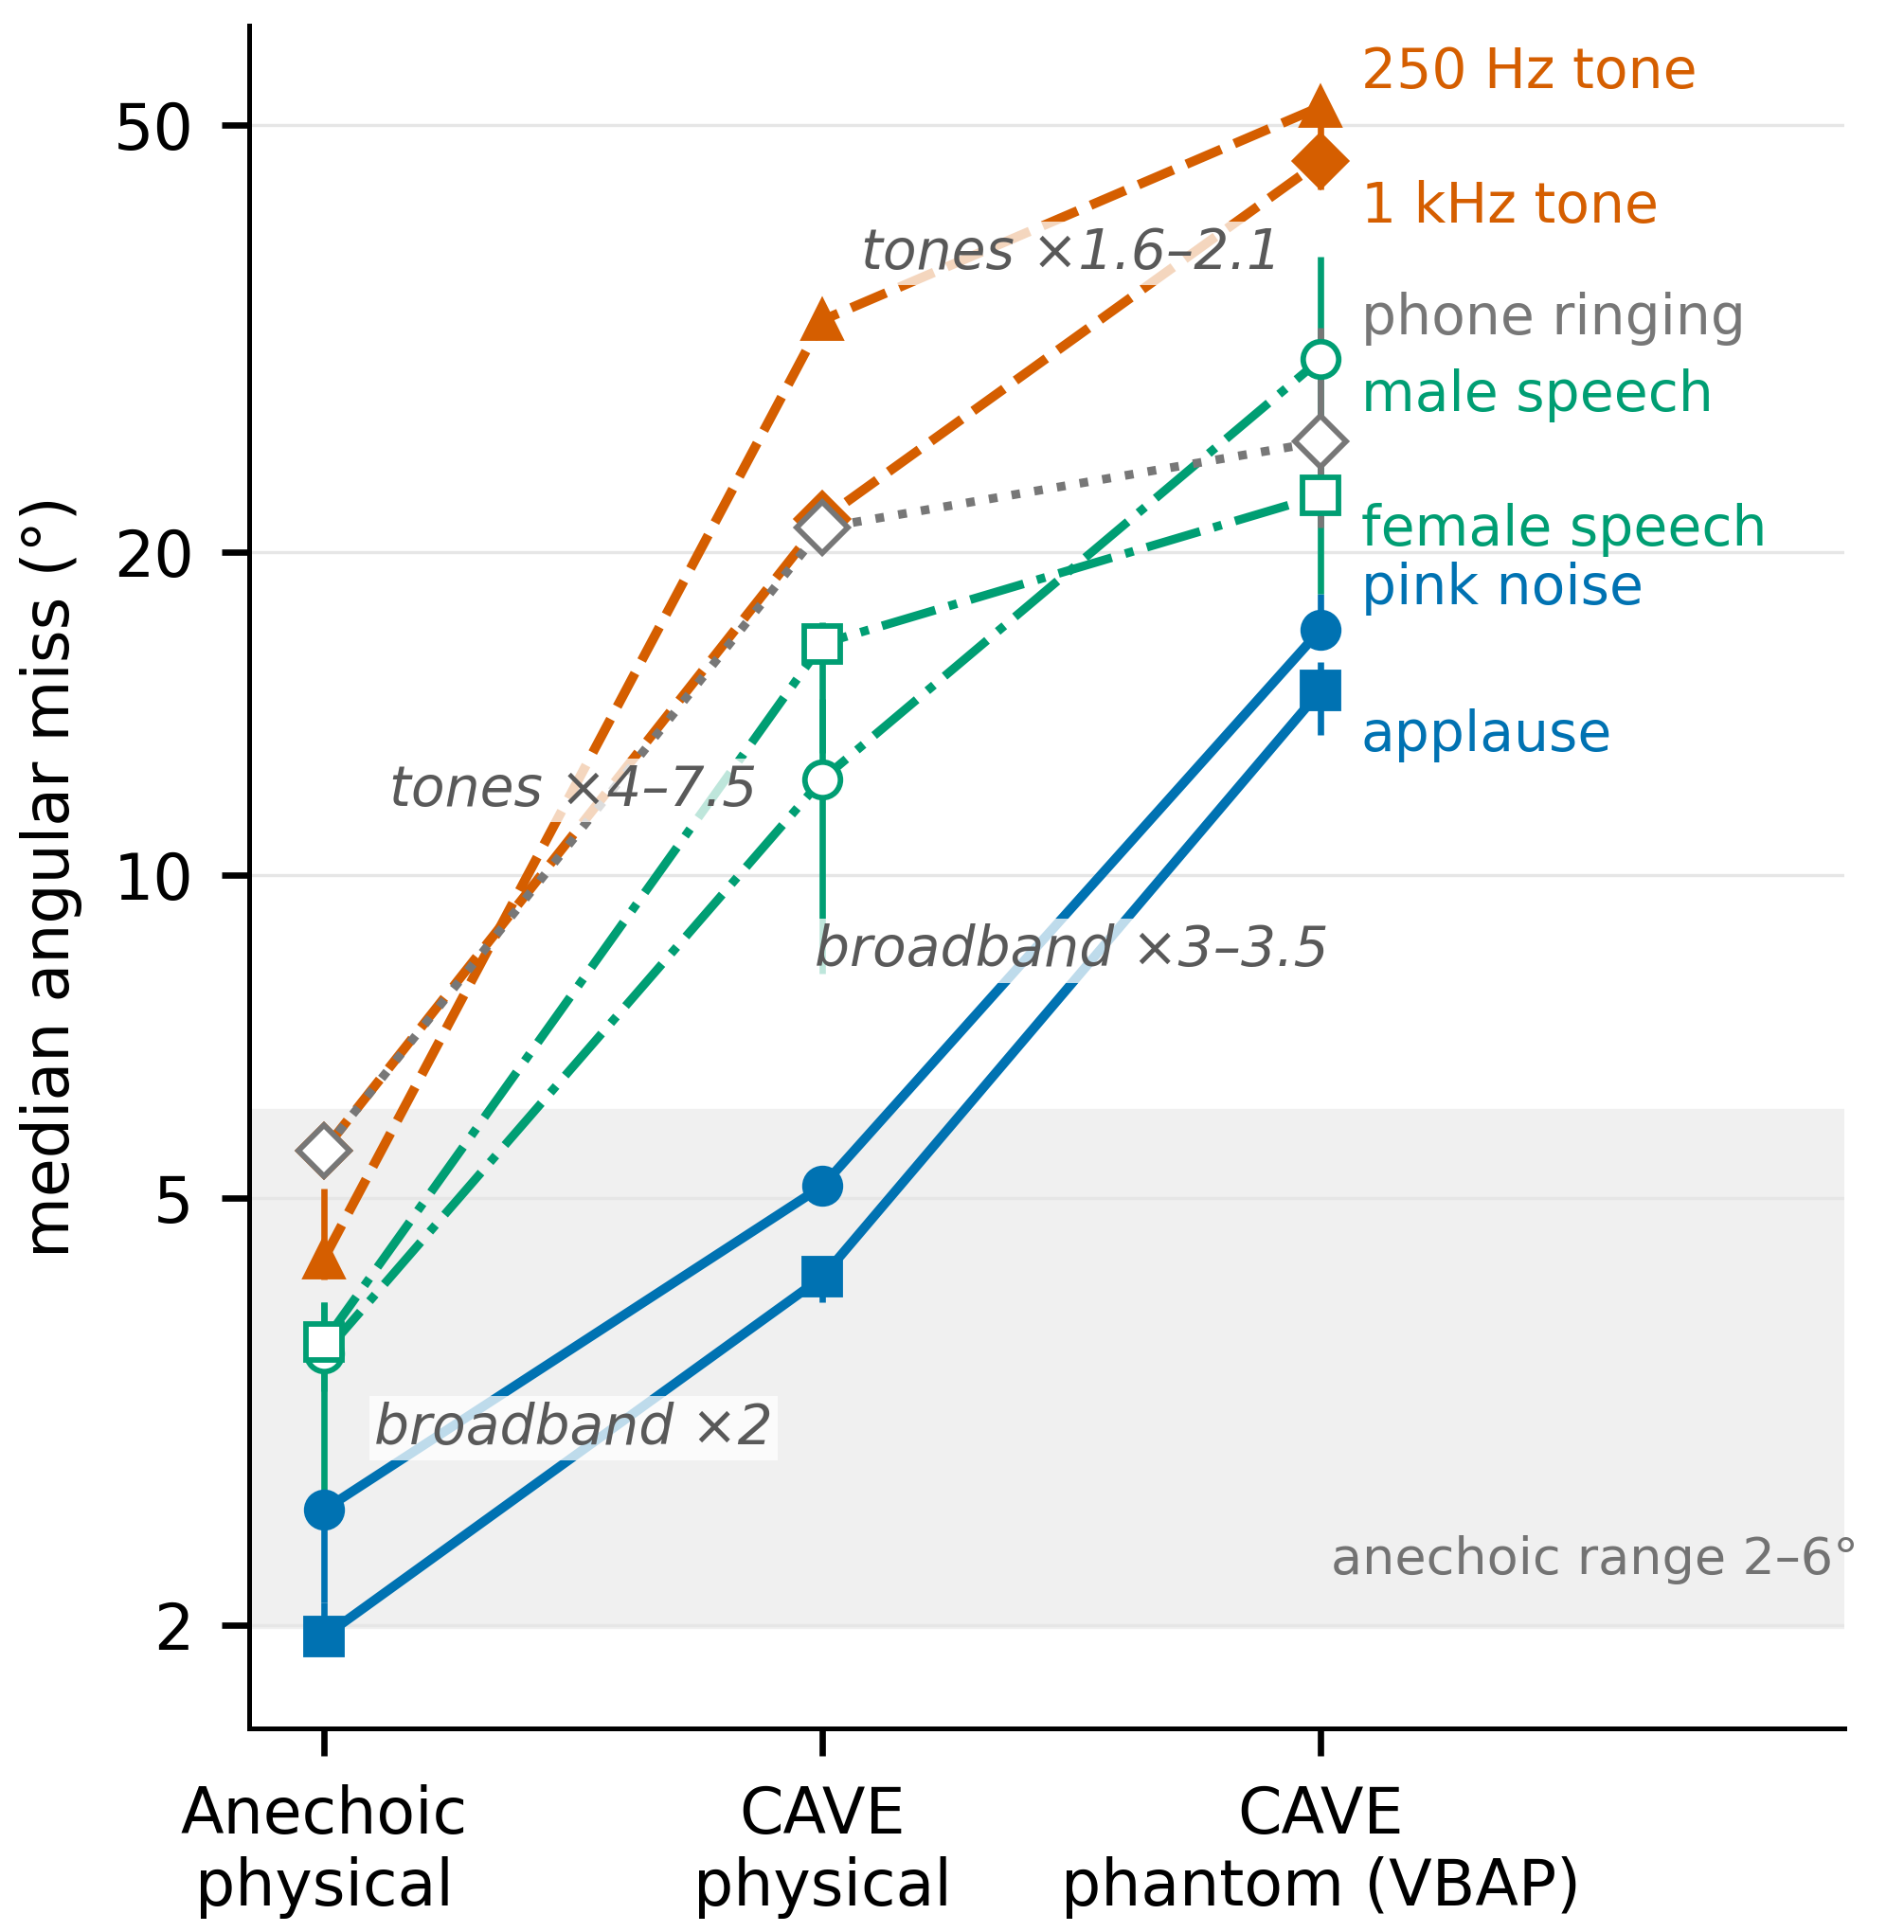

**miss-maps-physical-vs-phantom.png**

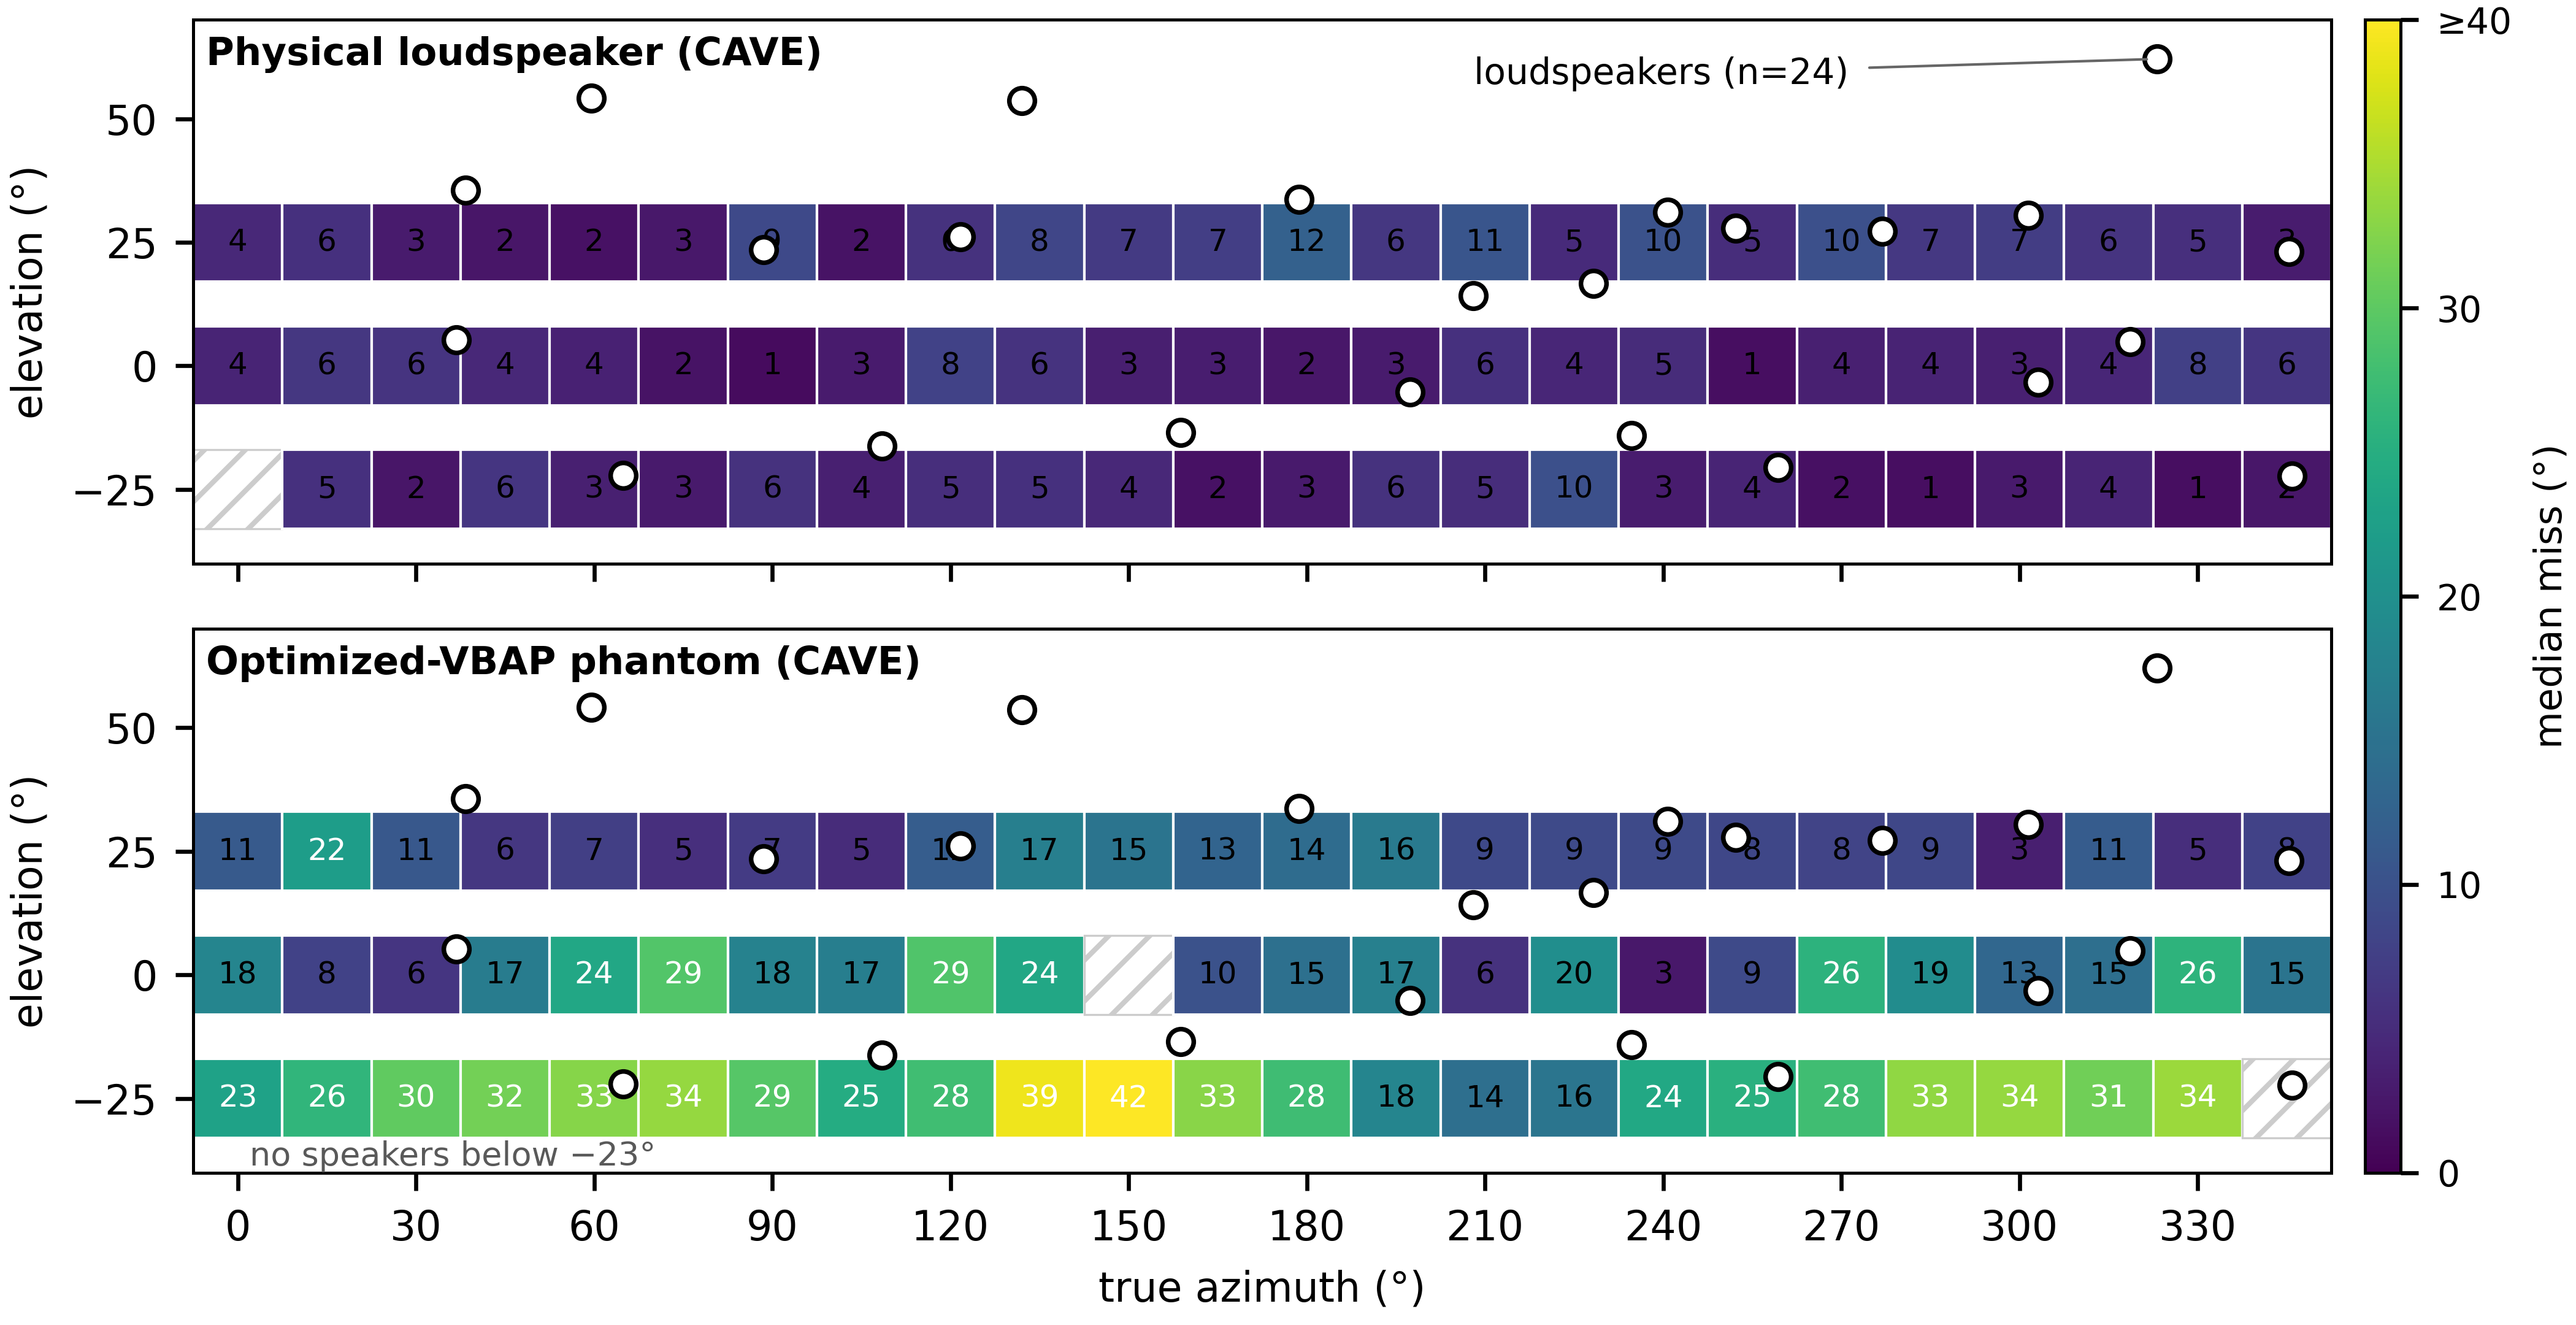

**elevation-opposition.png**

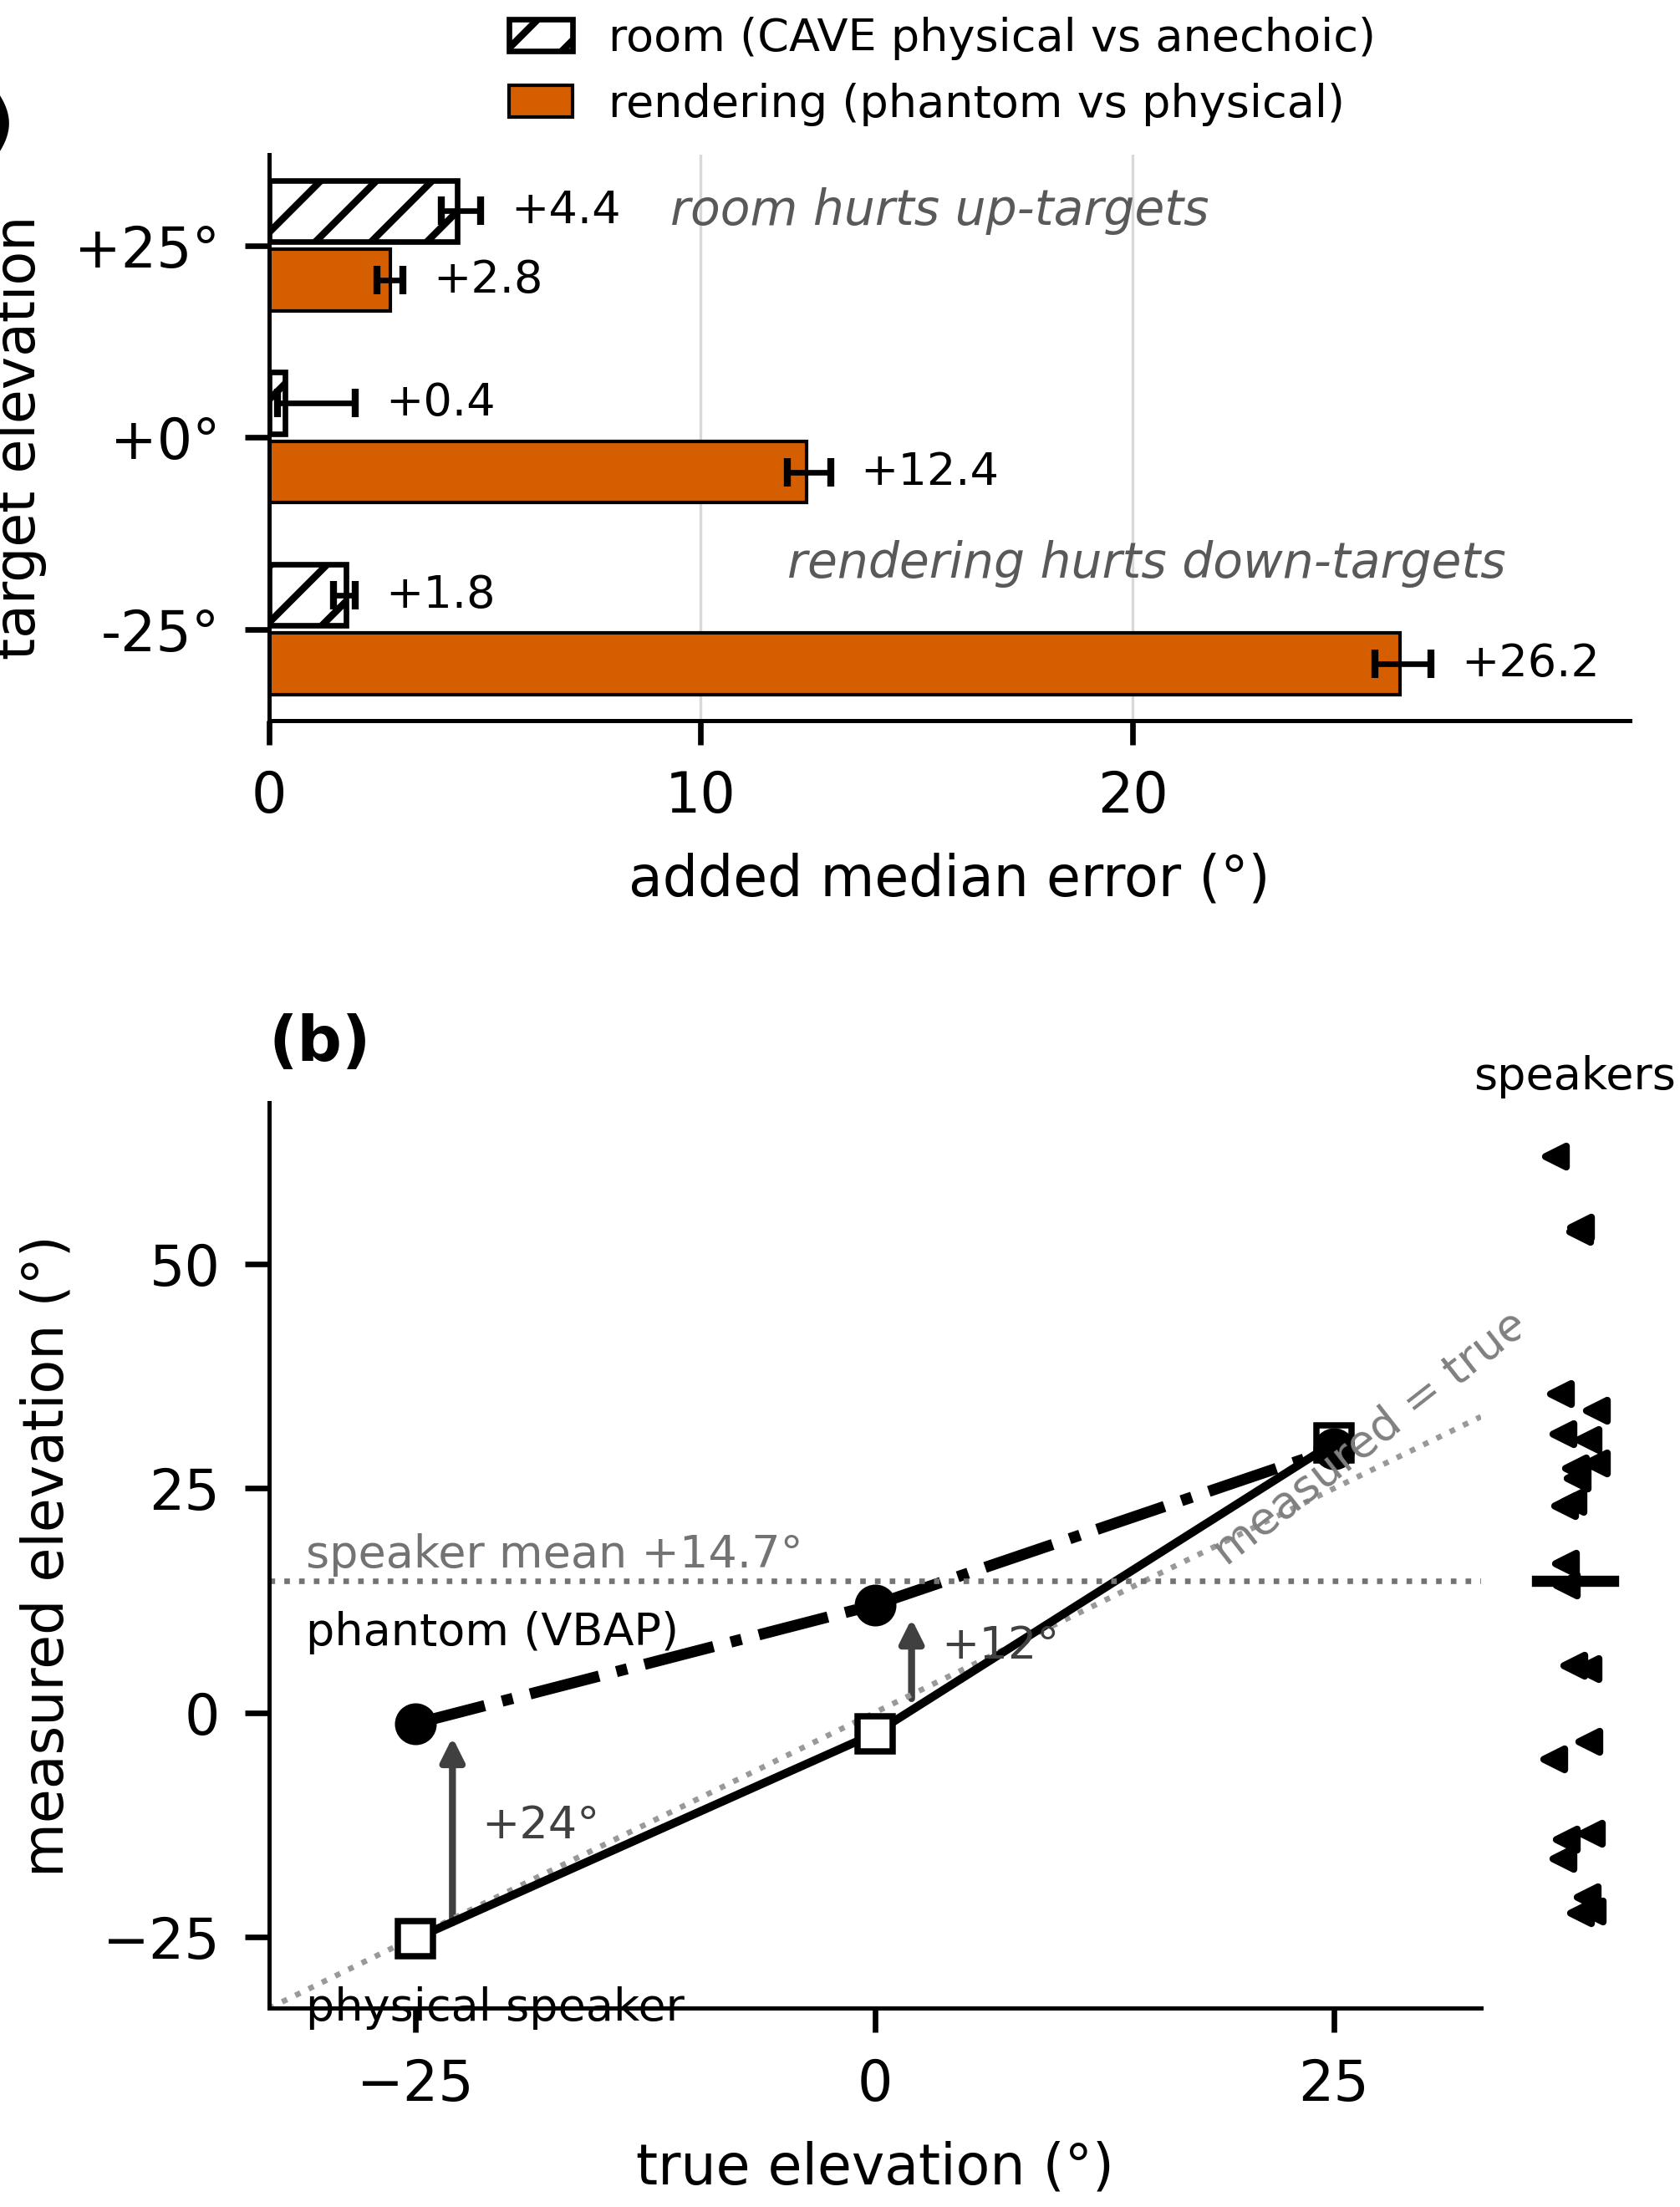

In [15]:
import make_paper_figures as mpf
for p in mpf.build_all():
    display(Markdown(f"**{Path(p).name}**")); display(Image(str(p)))